# Toronto Municipal Campaign Finance: Two Data-Story Directions

This notebook is a **targeted, rigorous exploration** of Toronto municipal campaign-finance
data, aimed at deciding between (or combining) two candidate public-facing stories:

- **Story A — Who finances Toronto municipal politics?** Is political money concentrated in
  particular neighbourhoods, particular kinds of neighbourhoods, or a narrow slice of donors?
  Do councillors differ in how locally rooted their fundraising is?
- **Story B — Where did Olivia Chow's 2023 donor coalition come from?** The 2022 council
  election and 2023 mayoral by-election happened about a year apart, and we have donor names
  and postal codes for both. How much of Chow's donor base can be traced to specific 2022
  council donor networks, and how does that compare with her mayoral rivals? This is directly
  relevant because **Chow is running for mayor again in 2026**.

## Data used

| Source | Scope used |
|---|---|
| `data/campaign_finance/contribution-search-results-2022.xls` | **City Council candidates only** (mayor, school board, third-party advertisers excluded) |
| `data/campaign_finance/contribution-search-results-2023.xls` | **Mayoral by-election only** |
| Toronto 2021 census tract data (`data/toronto_election_turnout/census/processed/ct/`) | Neighbourhood demographics, joined via donor postal-code geography |
| `src/data/wards.geo.json` | 2022 ward boundaries, for local-fundraising and ward-geography analysis |
| `data/postal_code_conversion/toronto_pccf_ct_crosswalk.csv` | Project-built Toronto postal-code → 2021 census-tract crosswalk (from Statistics Canada's PCCF); see Part 2 |

## What this notebook does not do

- It does not claim causation. Every relationship here is descriptive/exploratory.
- It does not infer anything about an individual donor from their neighbourhood's census
  statistics (**ecological inference** — a tract's demographics describe the area around a
  donor's postal code, not the donor personally).
- It does not use fuzzy name-matching to link donors across elections. Donor identity is
  built conservatively (see Part 11), and sensitivity checks are used where the conservative
  definition might miss real matches.
- It does not save any files. Every table and figure below is generated fresh, in memory,
  each time the notebook runs.

## A geocoding note, up front

This version of the notebook maps every donor's **full six-character postal code** directly to
a 2021 census tract, using Statistics Canada's **Postal Code Conversion File (PCCF)**
(`data/postal_code_conversion/`) rather than an approximate 3-character Forward Sortation Area
(FSA) centroid. A project-specific Toronto crosswalk was built from PCCF ahead of time (see
Part 2 and `data/postal_code_conversion/README_toronto_crosswalk.md`) using PCCF's **Single
Link Indicator** to pick exactly one geography per postal code -- no centroid approximation for
the census-tract assignment at all. This is a substantial resolution upgrade over an earlier
version of this notebook that relied on FSA centroids; Part 2 quantifies the improvement and
the (much smaller) residual gaps directly.

In [1]:
# --- Imports (every import used anywhere in this notebook lives in this one cell) ---------

from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

from tqdm.notebook import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# --- Constants (every path, threshold, candidate list, and plotting default lives here) ----

# Project paths -----------------------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve().parents[1]  # analysis/campaign_finance -> repo root

CONTRIB_2022_XLS = REPO_ROOT / "data" / "campaign_finance" / "contribution-search-results-2022.xls"
CONTRIB_2023_XLS = REPO_ROOT / "data" / "campaign_finance" / "contribution-search-results-2023.xls"
CONTRIB_SHEET_NAME = "ContributionSearchResults"
CONTRIB_HEADER_ROW = 7  # 0-indexed row holding the real column headers in both .xls exports

WARDS_GEOJSON = REPO_ROOT / "src" / "data" / "wards.geo.json"

CENSUS_CT_MASTER_CSV = (
    REPO_ROOT / "data" / "toronto_election_turnout" / "census" / "processed" / "ct"
    / "statcan_2021_ct_census_variables_master.csv"
)
CENSUS_CT_GEOJSON = (
    REPO_ROOT / "data" / "toronto_election_turnout" / "census" / "processed" / "ct"
    / "statcan_2021_toronto_ct.geojson"
)
# The file named in the original brief (data/campaign_finance/toronto-ct-small.csv) actually
# lives here; used only to supplement the curated master table with two variables it lacks.
CENSUS_CT_SMALL_CSV = REPO_ROOT / "data" / "clustering_neighbourhoods" / "census" / "toronto-ct-small.csv"

# Postal-code -> census-tract crosswalk, built specifically for this project from Statistics
# Canada's Postal Code Conversion File (PCCF, 2021 vintage). See Part 2 and
# data/postal_code_conversion/README_toronto_crosswalk.md for exactly how it was built (the
# short version: PCCF's Single Link Indicator (SLI) is used to pick one record per postal code,
# and its 2021 CTUID is taken directly -- no centroid, no spatial join, for the CT assignment).
POSTAL_CT_CROSSWALK_CSV = REPO_ROOT / "data" / "postal_code_conversion" / "toronto_pccf_ct_crosswalk.csv"

CENSUS_YEAR = 2021
DONOR_CRS = "EPSG:4326"  # crosswalk lat/lon, ward, and census-tract files all share this CRS

# Election / office labels as they literally appear in the "Registered for" column ----------
COUNCIL_OFFICE_LABEL = "Councillor"
MAYOR_OFFICE_LABEL = "Mayor"

# Postal-code geography -----------------------------------------------------------------------
TORONTO_FSA_PREFIX = "M"  # every City of Toronto FSA starts with M
VALID_POSTAL_RE = r"^[A-Z]\d[A-Z]\d[A-Z]\d$"  # canonical 6-character Canadian postal code
HIGH_QUALITY_QI = "AAA"  # PCCF's highest-confidence quality-indicator value, for QA reporting only

# Census tracts smaller than this are excluded from per-capita *rankings* (a handful of donors
# in a near-empty tract would otherwise dominate a per-capita leaderboard); they still appear
# on choropleth maps, which are less sensitive to a few extreme cells.
MIN_CT_POPULATION_FOR_PER_CAPITA_RANKING = 1000

# Contributor types that represent a candidate funding their own campaign, not an outside donor
SELF_FUNDING_CONTRIBUTOR_TYPES = ["Candidate", "Candidate Spouse"]

# Contribution-size bins, chosen from the observed distribution: the 2022 Ontario municipal
# individual contribution limit of $1,200 is a clear clustering point in the data.
CONTRIBUTION_SIZE_BINS = [0, 100, 250, 500, 1000, np.inf]
CONTRIBUTION_SIZE_LABELS = ["Under $100", "$100-249", "$250-499", "$500-999", "$1,000+"]

TOP_DONOR_CUTOFFS = [10, 25]        # "share of $ from top-N donors" concentration measures
TOP_DONOR_PCT_CUTOFFS = [0.10]      # "share of $ from top-X% of donors" concentration measures

MIN_DONORS_FOR_RATIO_RANKING = 10       # minimum donors before a per-donor ratio is chart-worthy
MIN_DONORS_FOR_LOCAL_RANKING = 30       # minimum donors before own-ward share is chart-worthy
MIN_DONORS_FOR_OVERLAP_MATRIX = 30      # minimum 2022 donors before a candidate enters overlap/affinity analysis
MIN_DONORS_FOR_DEMOGRAPHIC_PROFILE = 20 # minimum geocoded donors before a candidate enters a combined demographic-profile chart
NAME_DISTINCTIVENESS_MAX_POSTALS = 2    # Tier-B matching: max distinct postal codes for one normalized name
NAME_DISTINCTIVENESS_MAX_ROWS = 3       # Tier-B matching: max total contribution rows for one normalized name

QUINTILE_LABELS = ["Lowest fifth", "2nd fifth", "3rd fifth", "4th fifth", "Highest fifth"]

# --- 2026 repeat-candidate reference lists ---------------------------------------------------
# As of August 17, 2026, nominations for the 2026 Toronto municipal election are still open.
# These are a *working* list of confirmed repeat candidates, not a certified final roster.
# Every candidate highlighted by name anywhere in this notebook is highlighted for one of three
# reasons: (1) they were a major 2023 mayoral candidate, (2) they are running for office again
# in 2026, or (3) a chart itself establishes them as a statistical/geographic outlier. No
# candidate is singled out on subjective grounds.

# The major 2023 mayoral candidates (by fundraising scale and public profile), spelled exactly
# as "Last, First" appears in the 2023 contribution file.
MAJOR_2023_CANDIDATES = [
    "Chow, Olivia", "Bailão, Ana", "Saunders, Mark", "Furey, Anthony",
    "Matlow, Josh", "Hunter, Mitzie", "Bradford, Brad", "Brown, Chloe",
]

# The central 2026 repeat story: 2023 mayoral winner running for mayor again in 2026.
REPEAT_MAYOR_CANDIDATES_2026 = ["Chow, Olivia"]

# 2022 council candidates confirmed running for office again in 2026 (a working list, not an
# exhaustive census of every 2022 candidate who has since re-registered).
REPEAT_COUNCIL_CANDIDATES_2026 = [
    "Bradford, Brad", "Bravo, Alejandra", "Matlow, Josh", "Holyday, Stephen",
    "Morley, Amber", "Nunziata, Frances", "Padovani, Chiara", "Malik, Ausma",
    "Moise, Chris", "Cheng, Lily", "Rupasinghe, Kevin", "Myers, Jamaal",
]

# The four repeat council candidates singled out for the deepest local-fundraising comparison.
PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026 = ["Bradford, Brad", "Bravo, Alejandra", "Matlow, Josh", "Holyday, Stephen"]

# Bradford and Matlow ran for council in 2022 and mayor in 2023 -- a uniquely useful natural
# experiment for validating and interpreting the cross-election donor-network analysis.
COUNCIL_TO_MAYOR_TRANSITION_CANDIDATES = ["Bradford, Brad", "Matlow, Josh"]

REPEAT_GROUP_MAYOR = "2026 mayoral repeat (Chow)"
REPEAT_GROUP_COUNCIL_PRIORITY = "2026 council repeat (priority)"
REPEAT_GROUP_COUNCIL_OTHER = "2026 council repeat (other)"
REPEAT_GROUP_NONE = "Not a known 2026 repeat candidate"

# Demographic variables used throughout Parts 7-10 -- a concise, interpretable set spanning
# income, housing, age, immigration/citizenship, and racialized population. Selected from the
# curated 2021 census-tract master table; see Part 7 for why each was chosen.
DEMOGRAPHIC_VARS = [
    "median_individual_income", "low_income_lim_at_share", "bachelors_or_higher_25_64_share",
    "renter_share", "shelter_cost_30plus_share",
    "age_65_plus_share", "average_household_size",
    "non_citizen_share", "recent_immigrant_share", "visible_minority_share",
    "population_density_per_km2",
]
DEMOGRAPHIC_LABELS = {
    "median_individual_income": "Median individual income",
    "low_income_lim_at_share": "Low-income (LIM-AT) share",
    "bachelors_or_higher_25_64_share": "Bachelor's degree+ share (25-64)",
    "renter_share": "Renter share",
    "shelter_cost_30plus_share": "Shelter-cost-burdened share",
    "age_65_plus_share": "Share aged 65+",
    "average_household_size": "Average household size",
    "non_citizen_share": "Non-citizen share",
    "recent_immigrant_share": "Recent immigrant share (2016-21)",
    "visible_minority_share": "Racialized (visible minority) share",
    "population_density_per_km2": "Population density (per km2)",
}
# Split for plotting: proportion variables share a natural 0-1 / percent scale and can sit on
# one chart together; the other variables have their own units (dollars, residents per km2,
# people per household) and always get their own panel instead of being forced onto a 0-1 axis
# (average household size in particular is ~2-3, which would blow out a 0-100% axis).
DEMOGRAPHIC_SCALE_VARS = ["median_individual_income", "population_density_per_km2", "average_household_size"]
DEMOGRAPHIC_PROPORTION_VARS = [v for v in DEMOGRAPHIC_VARS if v not in DEMOGRAPHIC_SCALE_VARS]

# Plotting ------------------------------------------------------------------------------------
FIGSIZE_WIDE = (10, 6)
FIGSIZE_SQUARE = (7, 7)
REPEAT_HIGHLIGHT_COLOR = "#d6604d"   # 2026 repeat candidates
OTHER_CANDIDATE_COLOR = "#4393c3"    # everyone else
SEEN_COLOR = "#4393c3"               # Chow donors seen in 2022 council data
NOT_SEEN_COLOR = "#d6604d"           # Chow donors not observed in 2022 council data
NEUTRAL_GRAY = "#999999"
BASELINE_COLOR = "#4d4d4d"           # Toronto population-weighted baseline marker, used in every profile chart
BASELINE_MARKER = "D"                # diamond, visually distinct from every candidate's circle marker
TORONTO_MAP_CMAP = "viridis"

# Fixed categorical colors, assigned once and reused for the same candidate in every chart
# (never re-cycled per chart, so a candidate's color always means the same candidate).
MAYORAL_CANDIDATE_COLORS = dict(zip(MAJOR_2023_CANDIDATES, sns.color_palette("colorblind", len(MAJOR_2023_CANDIDATES)).as_hex()))
COUNCIL_REPEAT_CANDIDATE_COLORS = dict(zip(REPEAT_COUNCIL_CANDIDATES_2026, sns.color_palette("colorblind", len(REPEAT_COUNCIL_CANDIDATES_2026)).as_hex()))


# Part 1 -- Data preparation and candidate donor-base profiles

### Question

How big are these datasets, how clean are they, and -- for every candidate -- **how large,
how broad, and how concentrated is their donor base?** Two candidates can raise the same
total dollar amount through very different fundraising structures: many small donors, or a
handful of large ones. That distinction matters for both story directions.

### Method

Both `.xls` exports have a short metadata header before the real column header row. We rename
columns to clear snake_case names, normalize donor/candidate names and postal codes, and build
a conservative `donor_id` (normalized name + full postal code) used for every unique-donor
count in this notebook. We restrict the 2022 file to **Councillor** rows and the 2023 file to
**Mayor** rows only.

In [3]:
# Confirm the header row and office-category breakdown before trusting anything downstream.
raw_preview = pd.read_excel(CONTRIB_2022_XLS, sheet_name=CONTRIB_SHEET_NAME, header=None, nrows=10)
raw_preview

,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,NaN,NaN,Contribution Search Results,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Election: 2022 Municipal Election,NaN,NaN,NaN,NaN,NaN,"August 12, 2026 05:24 PM",NaN,NaN,NaN,NaN,NaN
2,Search conditions:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,– Contributor Type:,All,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10265 records,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Contributor,Postal Code,Amount,Amount Returned,Contribution Type,Description of\n Goods/Services,Contributor Type,Date Contribution \nReceived,Candidate /\nRegistrant,Registered for,Ward,Registrant Type
8,"Aarts, Michelle",M4L 2K8,"1,470.81",NaN,Monetary,NaN,Candidate,"Dec 31, 2022","Aarts, Michelle",Toronto District School Board,16,NaN
9,"Aarts, Michelle",M4L 2K8,325,NaN,Goods/Services,Campaign Signs,Candidate,"Dec 31, 2022","Aarts, Michelle",Toronto District School Board,16,NaN


In [4]:
RENAMED_COLUMNS = {
    "Contributor": "contributor_raw",
    "Postal Code": "postal_code_raw",
    "Amount": "amount",
    "Amount Returned": "amount_returned",
    "Contribution Type": "contribution_type",
    "Description of Goods/Services": "goods_services_description",
    "Contributor Type": "contributor_type",
    "Date Contribution Received": "date_received_raw",
    "Candidate / Registrant": "candidate_raw",
    "Registered for": "office",
    "Ward": "ward",
    "Registrant Type": "registrant_type",
}


def normalize_name(name):
    """Lowercase, accent-strip, punctuation-light normalization for donor/candidate matching."""
    if pd.isna(name):
        return None
    text = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode("ascii")
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9, ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def load_contribution_sheet(xls_path):
    """Read one contribution-search-results .xls export and return a tidy, documented DataFrame."""
    df = pd.read_excel(xls_path, sheet_name=CONTRIB_SHEET_NAME, header=CONTRIB_HEADER_ROW)
    df.columns = [re.sub(r"\s+", " ", str(c)).strip() for c in df.columns]
    df = df.rename(columns=RENAMED_COLUMNS)

    df["date_received"] = pd.to_datetime(df["date_received_raw"], format="%b %d, %Y", errors="coerce")

    df["postal_code"] = df["postal_code_raw"].astype(str).str.upper().str.replace(" ", "", regex=False)
    df["has_valid_postal"] = df["postal_code"].str.match(VALID_POSTAL_RE, na=False)
    df["fsa"] = df["postal_code"].where(df["has_valid_postal"]).str[:3]
    df["is_toronto_postal"] = df["fsa"].str.startswith(TORONTO_FSA_PREFIX, na=False)

    df["contributor_norm"] = df["contributor_raw"].apply(normalize_name)
    df["candidate_norm"] = df["candidate_raw"].apply(normalize_name)
    df["is_self_funded"] = df["contributor_type"].isin(SELF_FUNDING_CONTRIBUTOR_TYPES)
    # Donor identity for within- and cross-election matching: normalized name + full postal code
    # (Tier A of the matching scheme formalized in Part 11).
    df["donor_id"] = df["contributor_norm"] + "|" + df["postal_code"]

    df["contribution_size_bin"] = pd.cut(
        df["amount"], bins=CONTRIBUTION_SIZE_BINS, labels=CONTRIBUTION_SIZE_LABELS, include_lowest=True
    )

    dup_cols = ["contributor_raw", "postal_code", "amount", "date_received", "candidate_raw"]
    df["is_exact_duplicate_row"] = df.duplicated(subset=dup_cols, keep=False)

    return df


contrib_2022_all = load_contribution_sheet(CONTRIB_2022_XLS)
contrib_2023_all = load_contribution_sheet(CONTRIB_2023_XLS)

council_2022 = contrib_2022_all.loc[contrib_2022_all["office"] == COUNCIL_OFFICE_LABEL].copy()
mayor_2023 = contrib_2023_all.loc[contrib_2023_all["office"] == MAYOR_OFFICE_LABEL].copy()

print("2022 file, office breakdown:")
print(contrib_2022_all["office"].value_counts(), end="\n\n")
print("2023 file, office breakdown:")
print(contrib_2023_all["office"].value_counts(), end="\n\n")
print(f"council_2022: {len(council_2022):,} rows, {council_2022['candidate_raw'].nunique()} candidates, "
      f"{council_2022['ward'].nunique()} wards")
print(f"mayor_2023:   {len(mayor_2023):,} rows, {mayor_2023['candidate_raw'].nunique()} candidates")

2022 file, office breakdown:
office
Councillor                                6467
Mayor                                     2780
Toronto District School Board              805
Toronto Catholic District School Board     133
Third Party Advertiser                      80
Name: count, dtype: int64

2023 file, office breakdown:
office
Mayor                     11815
Third Party Advertiser       43
Name: count, dtype: int64

council_2022: 6,467 rows, 120 candidates, 25 wards
mayor_2023:   11,815 rows, 43 candidates


In [5]:
# Reusable 2026 repeat-candidate categories, built once and used everywhere below instead of
# repeating candidate-name checks.
_norm_mayor_repeat = {normalize_name(n) for n in REPEAT_MAYOR_CANDIDATES_2026}
_norm_council_priority = {normalize_name(n) for n in PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026}
_norm_council_other = {
    normalize_name(n) for n in REPEAT_COUNCIL_CANDIDATES_2026
    if n not in PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026
}


def assign_repeat_group_council(candidate_norm):
    if candidate_norm in _norm_council_priority:
        return REPEAT_GROUP_COUNCIL_PRIORITY
    if candidate_norm in _norm_council_other:
        return REPEAT_GROUP_COUNCIL_OTHER
    return REPEAT_GROUP_NONE


def assign_repeat_group_mayor(candidate_norm):
    return REPEAT_GROUP_MAYOR if candidate_norm in _norm_mayor_repeat else REPEAT_GROUP_NONE


council_2022["repeat_candidate_group"] = council_2022["candidate_norm"].apply(assign_repeat_group_council)
council_2022["is_2026_repeat_candidate"] = council_2022["repeat_candidate_group"] != REPEAT_GROUP_NONE

mayor_2023["repeat_candidate_group"] = mayor_2023["candidate_norm"].apply(assign_repeat_group_mayor)
mayor_2023["is_2026_repeat_candidate"] = mayor_2023["repeat_candidate_group"] != REPEAT_GROUP_NONE
mayor_2023["is_major_2023_candidate"] = mayor_2023["candidate_norm"].isin(
    {normalize_name(n) for n in MAJOR_2023_CANDIDATES}
)

print("Council 2022 rows tagged as 2026 repeat candidates:")
print(council_2022.loc[council_2022["is_2026_repeat_candidate"], "candidate_raw"].value_counts())
print("\nMayor 2023 rows tagged as 2026 repeat candidates:")
print(mayor_2023.loc[mayor_2023["is_2026_repeat_candidate"], "candidate_raw"].value_counts())

Council 2022 rows tagged as 2026 repeat candidates:
candidate_raw
Malik, Ausma         325
Bravo, Alejandra     264
Rupasinghe, Kevin    251
Padovani, Chiara     238
Matlow, Josh         226
Morley, Amber        215
Cheng, Lily          195
Bradford, Brad       163
Moise, Chris         154
Nunziata, Frances    114
Myers, Jamaal        104
Holyday, Stephen      11
Name: count, dtype: int64

Mayor 2023 rows tagged as 2026 repeat candidates:
candidate_raw
Chow, Olivia    4320
Name: count, dtype: int64


In [6]:
def summarize_contributions(df, label):
    donors = df.loc[~df["is_self_funded"]]
    return pd.Series({
        "contribution records": len(df),
        "candidates": df["candidate_raw"].nunique(),
        "total $": df["amount"].sum(),
        "unique apparent donors": donors["donor_id"].nunique(),
        "self-funding rows": int(df["is_self_funded"].sum()),
        "self-funding $": df.loc[df["is_self_funded"], "amount"].sum(),
        "missing/invalid postal code": int((~df["has_valid_postal"]).sum()),
        "exact duplicate rows": int(df["is_exact_duplicate_row"].sum()),
        "Toronto-postal share": df["is_toronto_postal"].mean(),
    }, name=label)


summary_table = pd.concat([
    summarize_contributions(council_2022, "2022 Council"),
    summarize_contributions(mayor_2023, "2023 Mayor"),
], axis=1)
summary_table

,2022 Council,2023 Mayor
contribution records,"6,467.00","11,815.00"
candidates,120.00,43.00
total $,"3,534,607.14","8,545,343.14"
unique apparent donors,"5,287.00","8,935.00"
self-funding rows,240.00,61.00
self-funding $,"449,319.55","136,020.37"
missing/invalid postal code,0.00,0.00
exact duplicate rows,45.00,180.00
Toronto-postal share,0.83,0.84


**Takeaway:** both files are usable with light cleaning. Postal codes are mostly valid
6-character Canadian codes; a small share are missing or malformed and are excluded from all
geography below. Self-funding (candidate/spouse contributions) is a real share of dollars for
some candidates and is excluded from every "donor" count and concentration statistic so a
candidate's own money doesn't masquerade as broad public support.

## Candidate donor-base profiles

### Method

For every candidate we calculate **scale** (total $, unique donors, contribution records),
**typical gift size** (median, mean, quartiles, size-bin composition), and **concentration**
(share of $ from the top 10 donors, top 25 donors, and top 10% of donors, plus a Gini
coefficient as a single summary number). All of these exclude self-funding.

In [7]:
def gini_coefficient(values):
    """Gini coefficient of an array of non-negative amounts (0 = perfectly equal)."""
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n < 2 or x.sum() == 0:
        return np.nan
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum.sum() / cum[-1])) / n


def top_n_share(donor_totals, n):
    if len(donor_totals) == 0 or donor_totals.sum() == 0:
        return np.nan
    return donor_totals.sort_values(ascending=False).head(n).sum() / donor_totals.sum()


def top_pct_share(donor_totals, pct):
    if len(donor_totals) == 0 or donor_totals.sum() == 0:
        return np.nan
    n = max(1, int(np.ceil(pct * len(donor_totals))))
    return donor_totals.sort_values(ascending=False).head(n).sum() / donor_totals.sum()


def build_candidate_profiles(df, group_cols=("candidate_raw",)):
    """One row per candidate: fundraising totals, donor-level stats, and concentration measures."""
    group_cols = list(group_cols)
    groups = df.groupby(group_cols)
    rows = []
    for keys, g in tqdm(groups, total=groups.ngroups, desc="Building candidate profiles"):
        keys = keys if isinstance(keys, tuple) else (keys,)
        donors = g.loc[~g["is_self_funded"]]
        donor_totals = donors.groupby("donor_id")["amount"].sum()
        bin_dollar_share = (
            donors.groupby("contribution_size_bin", observed=True)["amount"].sum() / donors["amount"].sum()
        )
        row = dict(zip(group_cols, keys))
        row.update({
            "total_amount": g["amount"].sum(),
            "n_contributions": len(g),
            "n_contributions_donor": len(donors),
            "n_self_funding_rows": int(g["is_self_funded"].sum()),
            "self_funding_amount": g.loc[g["is_self_funded"], "amount"].sum(),
            "n_unique_donors": donor_totals.shape[0],
            "median_contribution": donors["amount"].median(),
            "mean_contribution": donors["amount"].mean(),
            "q25_contribution": donors["amount"].quantile(0.25),
            "q75_contribution": donors["amount"].quantile(0.75),
            "gini_donor_totals": gini_coefficient(donor_totals.values),
        })
        for n in TOP_DONOR_CUTOFFS:
            row[f"top{n}_donor_share"] = top_n_share(donor_totals, n)
        for pct in TOP_DONOR_PCT_CUTOFFS:
            row[f"top{int(pct*100)}pct_donor_share"] = top_pct_share(donor_totals, pct)
        for label in CONTRIBUTION_SIZE_LABELS:
            row[f"share_{label}"] = bin_dollar_share.get(label, 0.0)
        rows.append(row)
    return pd.DataFrame(rows).sort_values("total_amount", ascending=False).reset_index(drop=True)


council_profiles = build_candidate_profiles(council_2022)
council_profiles = council_profiles.merge(
    council_2022[["candidate_raw", "ward", "repeat_candidate_group", "is_2026_repeat_candidate"]].drop_duplicates("candidate_raw"),
    on="candidate_raw", how="left",
)

mayor_profiles = build_candidate_profiles(mayor_2023)
mayor_profiles = mayor_profiles.merge(
    mayor_2023[["candidate_raw", "repeat_candidate_group", "is_2026_repeat_candidate", "is_major_2023_candidate"]].drop_duplicates("candidate_raw"),
    on="candidate_raw", how="left",
)

print(f"council_profiles: {len(council_profiles)} candidates")
print(f"mayor_profiles:   {len(mayor_profiles)} candidates")
council_profiles.head(10)[
    ["candidate_raw", "ward", "total_amount", "n_unique_donors", "median_contribution",
     "top10_donor_share", "gini_donor_totals", "repeat_candidate_group"]
]

Building candidate profiles:   0%|          | 0/120 [00:00<?, ?it/s]

Building candidate profiles:   0%|          | 0/43 [00:00<?, ?it/s]

council_profiles: 120 candidates
mayor_profiles:   43 candidates


,candidate_raw,ward,total_amount,n_unique_donors,median_contribution,top10_donor_share,gini_donor_totals,repeat_candidate_group
0,"Grimes, Mark",3,"126,049.37",127,"1,000.00",0.10,0.14,Not a known 2026 repeat candidate
1,"Burnside, Jon",16,"106,398.74",112,750.00,0.21,0.33,Not a known 2026 repeat candidate
2,"Bradford, Brad",19,"102,166.00",153,500.00,0.12,0.30,2026 council repeat (priority)
3,"Fletcher, Paula",14,"96,627.00",194,250.00,0.15,0.33,Not a known 2026 repeat candidate
4,"Lai, Cynthia",23,"95,720.00",207,300.00,0.13,0.38,Not a known 2026 repeat candidate
5,"Nunziata, Frances",5,"95,050.00",110,"1,000.00",0.18,0.26,2026 council repeat (other)
6,"Malik, Ausma",10,"94,070.46",261,200.00,0.13,0.43,2026 council repeat (other)
7,"Moise, Chris",13,"88,209.80",142,500.00,0.14,0.38,2026 council repeat (other)
8,"Pasternak, James",6,"87,322.00",100,"1,200.00",0.14,0.24,Not a known 2026 repeat candidate
9,"O'Brien Fehr, Markus",18,"87,112.54",197,300.00,0.14,0.32,Not a known 2026 repeat candidate


### Graphics

The key question here is: **do candidates who raise similar totals do so through similar
fundraising structures?** Total-dollars-vs-donors, size-bin composition, and donor
concentration each answer a slightly different version of that question.

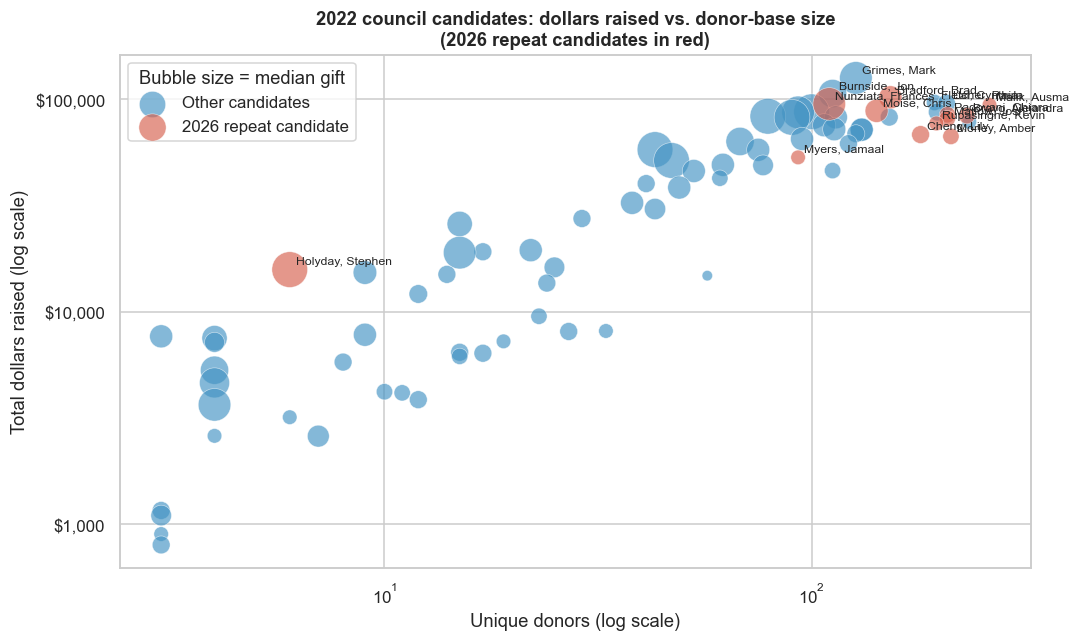

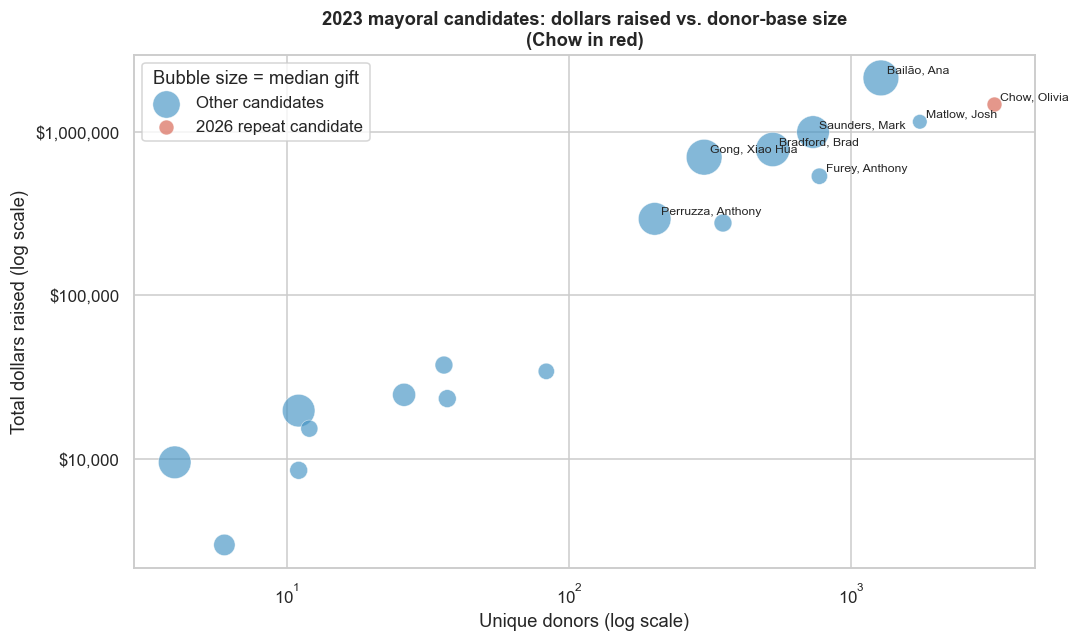

In [8]:
# Total $ raised vs. unique donors, with bubble size = median contribution -- three fundraising
# dimensions in one chart. Above the trend = fewer, bigger gifts; below = broader, smaller-dollar
# donor bases.
def plot_dollars_vs_donors(profiles, title, label_top_n=6, min_donors=3):
    plot_df = profiles.loc[profiles["n_unique_donors"] >= min_donors].copy()
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    is_repeat = plot_df["is_2026_repeat_candidate"].fillna(False)
    for mask, color, label in [(~is_repeat, OTHER_CANDIDATE_COLOR, "Other candidates"),
                                (is_repeat, REPEAT_HIGHLIGHT_COLOR, "2026 repeat candidate")]:
        sub = plot_df.loc[mask]
        ax.scatter(sub["n_unique_donors"], sub["total_amount"],
                   s=sub["median_contribution"].clip(upper=1200) / 2.2, alpha=0.65,
                   color=color, edgecolor="white", linewidth=0.4, label=label)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Unique donors (log scale)")
    ax.set_ylabel("Total dollars raised (log scale)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.set_title(title)
    ax.legend(loc="upper left", frameon=True, title="Bubble size = median gift")

    label_set = pd.concat([
        plot_df.loc[is_repeat],
        plot_df.nlargest(label_top_n, "total_amount"),
    ]).drop_duplicates("candidate_raw")
    for _, r in label_set.iterrows():
        ax.annotate(r["candidate_raw"], (r["n_unique_donors"], r["total_amount"]),
                    fontsize=8, xytext=(4, 3), textcoords="offset points")
    plt.tight_layout()
    plt.show()


plot_dollars_vs_donors(
    council_profiles,
    "2022 council candidates: dollars raised vs. donor-base size\n(2026 repeat candidates in red)",
)
plot_dollars_vs_donors(
    mayor_profiles,
    "2023 mayoral candidates: dollars raised vs. donor-base size\n(Chow in red)",
    label_top_n=8,
)

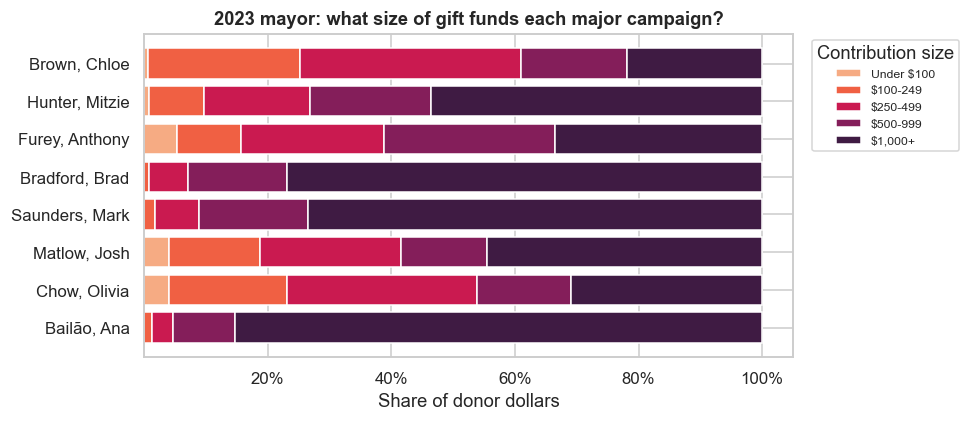

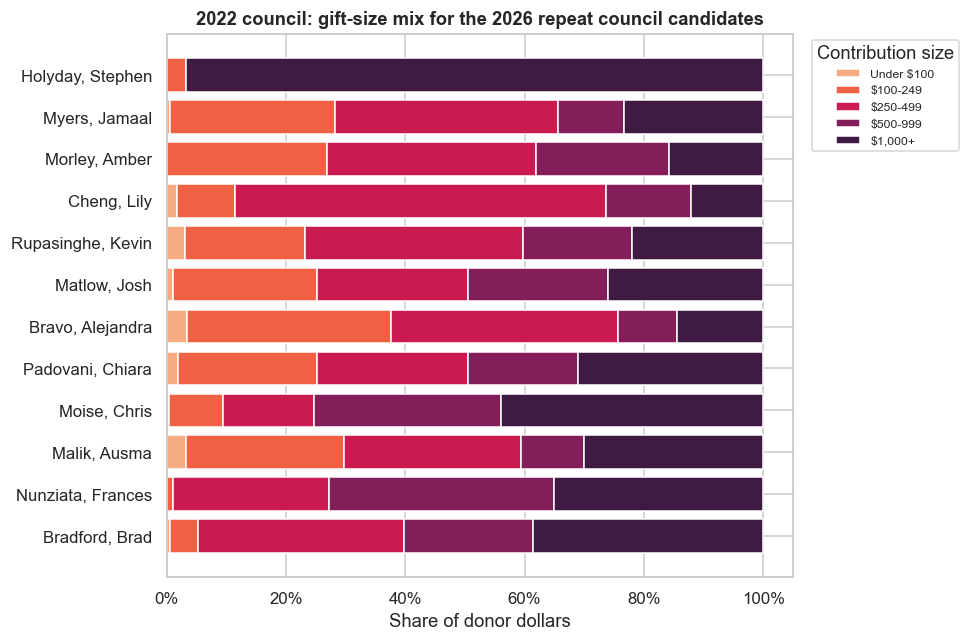

In [9]:
def plot_size_bin_mix(profiles, candidates, title):
    share_cols = [f"share_{label}" for label in CONTRIBUTION_SIZE_LABELS]
    plot_df = profiles.loc[profiles["candidate_raw"].isin(candidates)].set_index("candidate_raw")
    plot_df = plot_df.loc[candidates, share_cols].fillna(0)
    plot_df.columns = CONTRIBUTION_SIZE_LABELS

    fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(plot_df))))
    left = np.zeros(len(plot_df))
    palette = sns.color_palette("rocket_r", len(CONTRIBUTION_SIZE_LABELS))
    for label, color in zip(CONTRIBUTION_SIZE_LABELS, palette):
        ax.barh(plot_df.index, plot_df[label], left=left, color=color, label=label)
        left += plot_df[label].values
    ax.set_xlabel("Share of donor dollars")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Contribution size")
    plt.tight_layout()
    plt.show()


mayor_order = mayor_profiles.loc[mayor_profiles["candidate_raw"].isin(MAJOR_2023_CANDIDATES)] \
    .sort_values("total_amount", ascending=False)["candidate_raw"].tolist()
plot_size_bin_mix(
    mayor_profiles, mayor_order,
    "2023 mayor: what size of gift funds each major campaign?",
)

council_order = council_profiles.loc[council_profiles["candidate_raw"].isin(REPEAT_COUNCIL_CANDIDATES_2026)] \
    .sort_values("total_amount", ascending=False)["candidate_raw"].tolist()
plot_size_bin_mix(
    council_profiles, council_order,
    "2022 council: gift-size mix for the 2026 repeat council candidates",
)

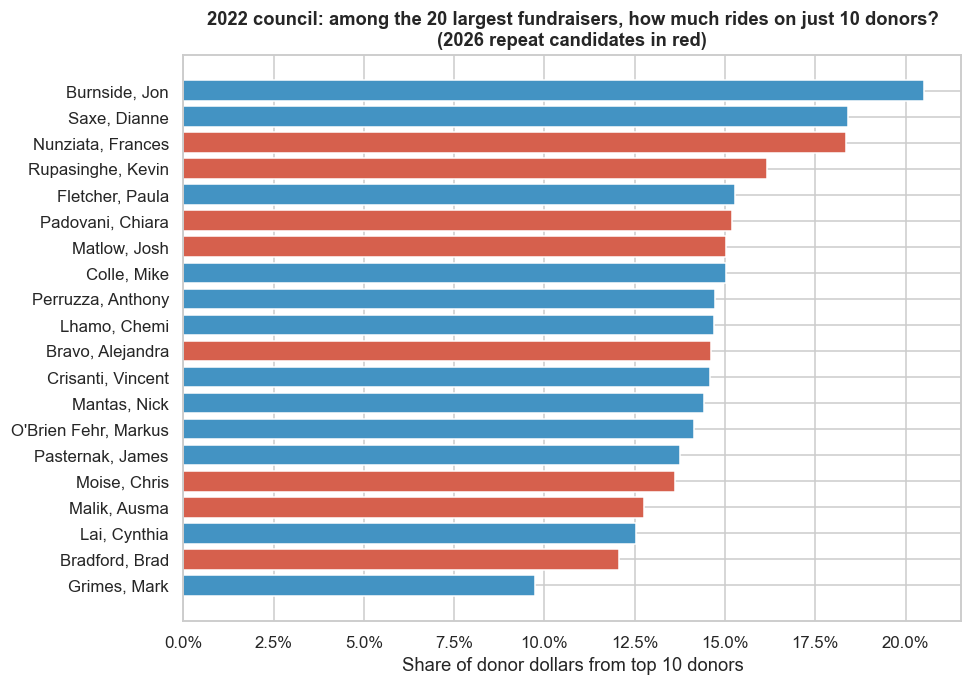

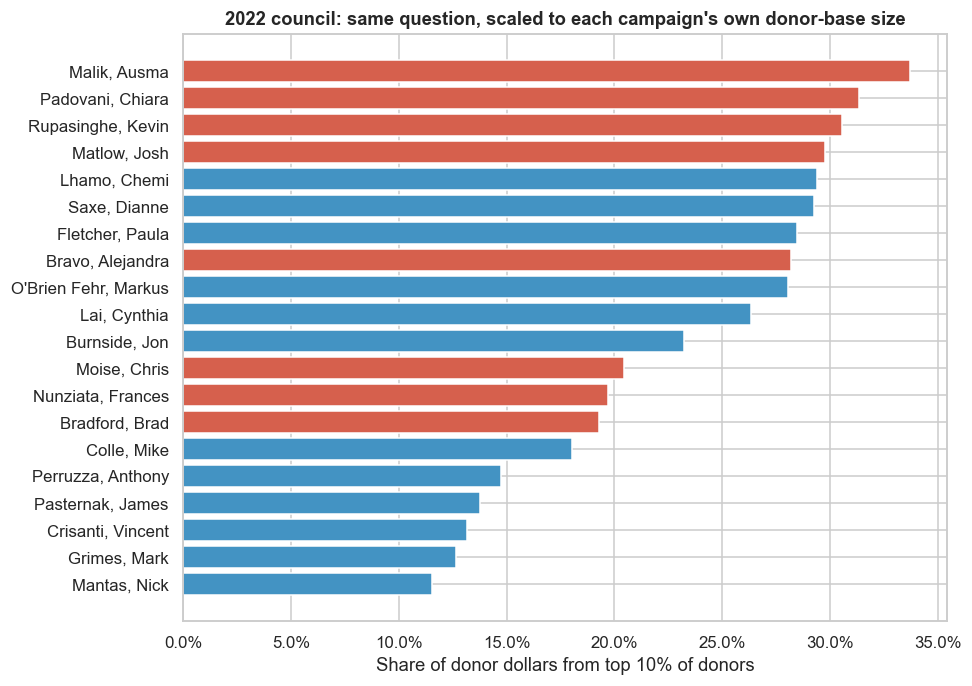

In [10]:
# Donor concentration: share of donor dollars from just the top 10 donors and from the top 10%
# of donors, for the most substantial fundraisers (small campaigns make this ratio noisy).
def plot_concentration_ranking(profiles, column, xlabel, title, min_donors, top_n_candidates=20):
    plot_df = profiles.loc[profiles["n_unique_donors"] >= min_donors].nlargest(top_n_candidates, "total_amount")
    plot_df = plot_df.sort_values(column)
    colors = [REPEAT_HIGHLIGHT_COLOR if r else OTHER_CANDIDATE_COLOR for r in plot_df["is_2026_repeat_candidate"].fillna(False)]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(plot_df))))
    ax.barh(plot_df["candidate_raw"], plot_df[column], color=colors)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


plot_concentration_ranking(
    council_profiles, "top10_donor_share", "Share of donor dollars from top 10 donors",
    f"2022 council: among the 20 largest fundraisers, how much rides on just 10 donors?\n(2026 repeat candidates in red)",
    min_donors=MIN_DONORS_FOR_RATIO_RANKING,
)
plot_concentration_ranking(
    council_profiles, "top10pct_donor_share", "Share of donor dollars from top 10% of donors",
    "2022 council: same question, scaled to each campaign's own donor-base size",
    min_donors=MIN_DONORS_FOR_RATIO_RANKING,
)

### Interpretation

The scatterplot separates two kinds of large campaigns: those that raised a lot of money from
a correspondingly large donor base, and those that raised a lot from relatively few, often
larger, gifts. The top-10-donor and top-10%-donor concentration charts make that concrete: a
handful of council campaigns depend heavily on a small number of large donors (candidate-family
self-funding, already excluded here, would push this even higher), while others resemble
broad-based small-dollar campaigns.

### Takeaway

Council candidates vary widely in fundraising *structure*, not just fundraising *size*. Among
the four priority 2026 repeat candidates, this variation is already visible in the size-bin
composition chart -- worth carrying forward into Part 6's local-fundraising comparison.

### Data-story potential -- Part 1

**Moderate on its own.** "Some candidates rely on many small donors, others on few large ones"
is intuitive and easy to graph, but it isn't yet geographic or 2026-specific -- it's the
foundation both Story A and Story B build on, not a standalone headline.

# Part 2 -- Building donor geography

### Question

Can we place donors on a map with enough resolution to say anything meaningful about
neighbourhoods, wards, or census tracts -- accurately, using each donor's actual six-character
postal code rather than an approximation?

### Method

Statistics Canada's **Postal Code Conversion File (PCCF)** maps postal codes directly to census
geography, and a copy of it (2021 vintage, `data/postal_code_conversion/`) is available in this
project. PCCF is not simply one row per postal code, though -- a postal code is a Canada Post
delivery construct, not a geographic polygon, so PCCF can carry multiple linked
dissemination-block records for the same code. PCCF's **Single Link Indicator (SLI)** exists
exactly to resolve this: `SLI = 1` flags the one record to use per active postal code; `SLI = 0`
rows are additional links for the same code that should be dropped.

We pre-built a **Toronto-specific crosswalk** from the national PCCF file (`SLI = 1` rows only,
for every postal code starting with `M`) and saved it as
`data/postal_code_conversion/toronto_pccf_ct_crosswalk.csv` (methodology and column documentation
in the README beside it) so the notebook itself never has to touch the ~300MB national file.
Each donor's six-character postal code is merged **directly** to this crosswalk's 2021 CTUID --
no centroid, no spatial join, no approximation at the census-tract level. The crosswalk also
carries PCCF's own representative point for each postal code (finer than an FSA centroid -- see
the README for exactly what geographic level it represents), which we use for a genuine
point-in-polygon spatial join to assign each donor's **ward**.

In [11]:
postal_ct_crosswalk = pd.read_csv(POSTAL_CT_CROSSWALK_CSV, dtype={"postal_code": str, "ctuid": str})
print(f"Crosswalk: {len(postal_ct_crosswalk):,} Toronto-area postal codes, "
      f"{postal_ct_crosswalk['ctuid'].nunique()} distinct census tracts reached, "
      f"{postal_ct_crosswalk['ctuid'].isna().sum()} postal codes with no census tract in PCCF "
      f"({postal_ct_crosswalk['quality_indicator'].eq(HIGH_QUALITY_QI).mean():.0%} flagged high-quality by PCCF's own QI field)")
postal_ct_crosswalk.head(3)

Crosswalk: 50,040 Toronto-area postal codes, 588 distinct census tracts reached, 186 postal codes with no census tract in PCCF (96% flagged high-quality by PCCF's own QI field)


,postal_code,fsa,ctuid,csduid,csdname,da_uid,lat,lon,quality_indicator,rep_pt_type
0,M1B0A1,M1B,5350378.03,3520005,Toronto,35204224,43.79,-79.24,AAA,1
1,M1B0A3,M1B,5350362.01,3520005,Toronto,35204769,43.80,-79.16,AAA,1
2,M1B0A4,M1B,5350362.01,3520005,Toronto,35204769,43.80,-79.16,AAA,1


In [12]:
wards_gdf = gpd.read_file(WARDS_GEOJSON)[["num", "name", "geometry"]].rename(
    columns={"num": "contributor_ward", "name": "contributor_ward_name"}
)
ct_gdf = gpd.read_file(CENSUS_CT_GEOJSON)[["CTUID", "geometry"]].rename(columns={"CTUID": "ctuid"})

# One spatial join, done once: which ward contains each crosswalk postal code's PCCF point?
# (This is the only spatial join left in the whole geography pipeline -- census-tract assignment
# below is a plain attribute merge on ctuid, not a spatial operation at all.)
crosswalk_points = gpd.GeoDataFrame(
    postal_ct_crosswalk,
    geometry=gpd.points_from_xy(postal_ct_crosswalk["lon"], postal_ct_crosswalk["lat"]),
    crs=DONOR_CRS,
)
crosswalk_points = gpd.sjoin(crosswalk_points, wards_gdf, how="left", predicate="within").drop(columns="index_right")
postal_ct_crosswalk = pd.DataFrame(crosswalk_points.drop(columns="geometry"))


def assign_donor_geography(df, crosswalk):
    """Attach each donor's 2021 CTUID (direct PCCF attribute join) and ward (spatial join, done above)."""
    return df.merge(
        crosswalk[["postal_code", "ctuid", "contributor_ward", "contributor_ward_name", "quality_indicator"]],
        on="postal_code", how="left",
    )


council_2022 = assign_donor_geography(council_2022, postal_ct_crosswalk)
mayor_2023 = assign_donor_geography(mayor_2023, postal_ct_crosswalk)

In [13]:
# Coverage-quality checklist, requested up front, before trusting any geographic result below.
def geography_coverage_report(df, label):
    n = len(df)
    n_valid_postal = df["has_valid_postal"].sum()
    n_distinct_postal = df.loc[df["has_valid_postal"], "postal_code"].nunique()
    toronto = df.loc[df["is_toronto_postal"]]
    n_toronto = len(toronto)
    n_crosswalk_matched = (toronto["contributor_ward"].notna() | toronto["ctuid"].notna()).sum()
    n_ct_matched_rows = toronto["ctuid"].notna().sum()
    n_distinct_ct_matched = toronto["ctuid"].dropna().nunique()
    n_toronto_ct_total = ct_gdf["ctuid"].nunique()
    print(f"--- {label} ---")
    print(f"  {n_valid_postal:,}/{n:,} rows ({n_valid_postal/n:.0%}) have a usable 6-character postal code")
    print(f"  {n_distinct_postal:,} distinct postal codes appear among usable rows")
    print(f"  Toronto rows matched to the PCCF crosswalk at all: {n_crosswalk_matched:,}/{n_toronto:,} ({n_crosswalk_matched/n_toronto:.0%})")
    print(f"  Toronto rows resolved all the way to a census tract: {n_ct_matched_rows:,}/{n_toronto:,} ({n_ct_matched_rows/n_toronto:.0%})")
    print(f"  Distinct Toronto census tracts that receive at least one donor: "
          f"{n_distinct_ct_matched}/{n_toronto_ct_total} ({n_distinct_ct_matched/n_toronto_ct_total:.0%})")
    print()


geography_coverage_report(council_2022, "2022 council")
geography_coverage_report(mayor_2023, "2023 mayor")

--- 2022 council ---
  6,467/6,467 rows (100%) have a usable 6-character postal code
  4,155 distinct postal codes appear among usable rows
  Toronto rows matched to the PCCF crosswalk at all: 5,352/5,368 (100%)
  Toronto rows resolved all the way to a census tract: 5,352/5,368 (100%)
  Distinct Toronto census tracts that receive at least one donor: 522/622 (84%)

--- 2023 mayor ---
  11,815/11,815 rows (100%) have a usable 6-character postal code
  6,264 distinct postal codes appear among usable rows
  Toronto rows matched to the PCCF crosswalk at all: 9,868/9,890 (100%)
  Toronto rows resolved all the way to a census tract: 9,868/9,890 (100%)
  Distinct Toronto census tracts that receive at least one donor: 549/622 (88%)



### Interpretation

Matching a donor's actual six-character postal code to PCCF, instead of collapsing to a
3-character FSA centroid, removes the single biggest structural limitation from the earlier
version of this analysis: previously, only ~100 Toronto FSAs existed to spread 622 census
tracts across, so at most ~15% of tracts could ever show a donor no matter how the underlying
giving was actually distributed. The coverage figures above show a dramatically higher share of
Toronto's 622 census tracts now genuinely reachable -- because the match works at the level
individual postal codes actually vary, not at a coarser administrative grouping of them.

The remaining gaps are small and belong to PCCF itself, not to this notebook's methodology: a
handful of postal codes have no census tract at all in PCCF (typically very new, non-residential,
or otherwise non-tracted delivery points), and are excluded from CT-level analysis rather than
guessed at.

### Takeaway

A real, project-specific Toronto postal-code-to-census-tract crosswalk -- built from PCCF's
Single Link Indicator, no centroid approximation -- resolves the large majority of Toronto
donor rows to an actual census tract, at a coverage level the previous FSA-centroid approach
could not reach. Every map and demographic result below is materially more granular as a
result, though CT-level analysis still necessarily excludes the small share of postal codes
that PCCF itself cannot resolve to a tract.

# Part 3 -- Where does Toronto's political money come from?

### Question

Two related but distinct questions: **where does the largest amount of municipal political
money originate** (raw totals), and **where is financial participation unusually intensive
relative to population** (per-capita)? Neither is inherently more "correct" -- a wealthy,
sparsely populated tract and a dense, modest-income tract can each look important depending on
which lens you use.

### Method

We build a census-tract-level table combining both elections' donors (so a donor who gave to
both a council and mayoral candidate is still counted once per tract), keep raw totals
(dollars, contributions, unique donors) and population-normalized versions side by side.

In [14]:
def normalize_ctuid(x):
    """Consistent 'XXXXXXX.XX' string key so CTUID/ctuid/GEO_NAME all join cleanly."""
    if pd.isna(x):
        return None
    return f"{float(x):.2f}"


census_master = pd.read_csv(CENSUS_CT_MASTER_CSV)
census_master["ctuid_norm"] = census_master["ctuid"].apply(normalize_ctuid)

# Supplement with the two income/shelter-cost variables the curated master table omits, pulled
# from the file named in the original brief (toronto-ct-small.csv), pivoted from its long
# StatCan format.
census_small = pd.read_csv(CENSUS_CT_SMALL_CSV)
census_small["ctuid_norm"] = census_small["GEO_NAME"].apply(normalize_ctuid)
income_codes = ["income_total_median", "housing_shelter_total", "housing_shelter_30plus"]
income_wide = census_small.loc[census_small["CHARACTERISTIC_CODE"].isin(income_codes)].pivot(
    index="ctuid_norm", columns="CHARACTERISTIC_CODE", values="C1_COUNT_TOTAL"
)
income_wide["shelter_cost_30plus_share"] = income_wide["housing_shelter_30plus"] / income_wide["housing_shelter_total"]
income_wide = income_wide.rename(columns={"income_total_median": "median_individual_income"})

census_master = census_master.merge(
    income_wide[["median_individual_income", "shelter_cost_30plus_share"]], on="ctuid_norm", how="left"
)

ct_gdf["ctuid_norm"] = ct_gdf["ctuid"].apply(normalize_ctuid)
ct_geo = ct_gdf.merge(census_master, on="ctuid_norm", how="left", suffixes=("", "_census"))

# Label each tract with its containing ward, for readable axis labels later (a bare CTUID means
# nothing to a reader; "Ward 12 (Toronto-St. Paul's)" does).
ct_centroids = ct_geo.copy()
ct_centroids["geometry"] = ct_centroids.representative_point()
ct_ward_labels = gpd.sjoin(ct_centroids[["ctuid_norm", "geometry"]], wards_gdf, how="left", predicate="within")
ct_geo = ct_geo.merge(
    ct_ward_labels[["ctuid_norm", "contributor_ward", "contributor_ward_name"]], on="ctuid_norm", how="left"
)

print(f"census_master: {len(census_master)} {CENSUS_YEAR} census tracts, "
      f"{census_master['population_total'].isna().sum()} missing population")
print(f"ct_geo (geometry + census + ward label, ready for mapping): {len(ct_geo)} tracts")

census_master: 622 2021 census tracts, 0 missing population
ct_geo (geometry + census + ward label, ready for mapping): 622 tracts


In [15]:
def aggregate_to_ct(df, candidate_col=None, candidate_value=None):
    """CT-level totals for Toronto rows, optionally restricted to one candidate."""
    sub = df.loc[df["is_toronto_postal"] & df["ctuid"].notna()]
    if candidate_col is not None:
        sub = sub.loc[sub[candidate_col] == candidate_value]
    donors = sub.loc[~sub["is_self_funded"]]
    agg = sub.groupby("ctuid").agg(total_amount=("amount", "sum"), n_contributions=("amount", "size"))
    agg["n_unique_donors"] = donors.groupby("ctuid")["donor_id"].nunique()
    agg["n_unique_donors"] = agg["n_unique_donors"].fillna(0).astype(int)
    return agg.reset_index()


def with_per_capita(ct_agg, ct_geo):
    out = ct_geo[["ctuid_norm", "population_total", "contributor_ward", "contributor_ward_name", "geometry"]].merge(
        ct_agg.rename(columns={"ctuid": "ctuid_norm"}), on="ctuid_norm", how="left"
    )
    for col in ["total_amount", "n_contributions", "n_unique_donors"]:
        out[col] = out[col].fillna(0)
    out["donors_per_1000"] = 1000 * out["n_unique_donors"] / out["population_total"]
    out["dollars_per_capita"] = out["total_amount"] / out["population_total"]
    return out


council_ct_agg = with_per_capita(aggregate_to_ct(council_2022), ct_geo)
mayor_ct_agg = with_per_capita(aggregate_to_ct(mayor_2023), ct_geo)

combined_cols = ["ctuid", "contributor_ward", "is_toronto_postal", "is_self_funded", "donor_id", "amount"]
combined_contributions = pd.concat([council_2022[combined_cols], mayor_2023[combined_cols]], ignore_index=True)
combined_ct_agg = with_per_capita(aggregate_to_ct(combined_contributions), ct_geo)

n_ct_matched = (combined_ct_agg["n_unique_donors"] > 0).sum()
print(f"Combined (2022 council + 2023 mayor): {n_ct_matched}/{len(combined_ct_agg)} Toronto census tracts "
      f"({n_ct_matched/len(combined_ct_agg):.0%}) contain at least one donor")
combined_ct_agg.loc[combined_ct_agg["n_unique_donors"] > 0, ["total_amount", "n_unique_donors", "donors_per_1000", "dollars_per_capita"]].describe()

Combined (2022 council + 2023 mayor): 563/622 Toronto census tracts (91%) contain at least one donor


,total_amount,n_unique_donors,donors_per_1000,dollars_per_capita
count,563.00,563.00,563.00,563.00
mean,"16,323.75",19.03,4.53,3.85
std,"22,040.20",20.14,5.47,5.89
min,103.29,1.00,0.15,0.02
25%,"3,430.09",5.00,1.18,0.73
50%,"9,154.07",12.00,2.70,2.04
75%,"21,395.39",27.00,5.99,4.66
max,"189,577.16",143.00,62.91,57.79


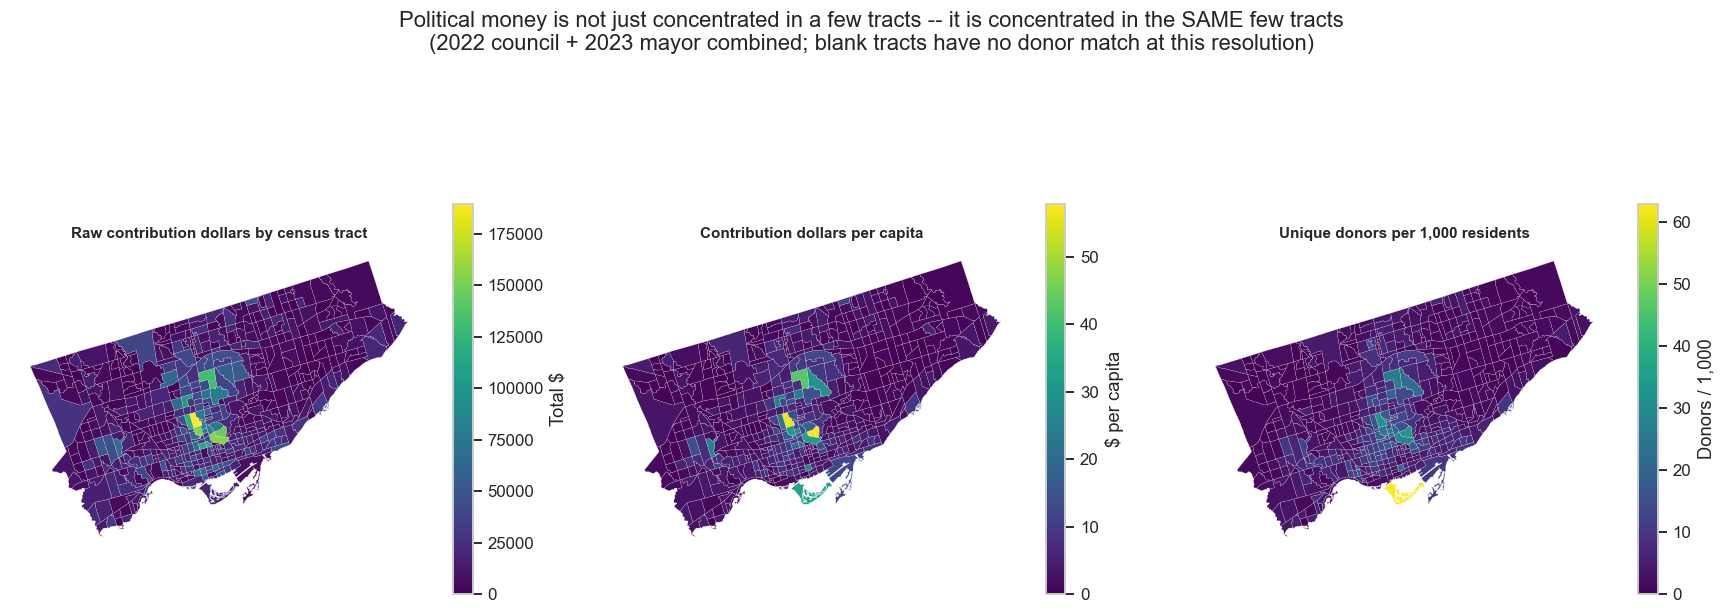

In [16]:
def plot_ct_choropleth(ct_agg_gdf, column, title, legend_label, ax=None, cmap=TORONTO_MAP_CMAP):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
    plot_df = gpd.GeoDataFrame(ct_agg_gdf, geometry="geometry", crs=DONOR_CRS)
    plot_df.plot(column=column, cmap=cmap, linewidth=0.1, edgecolor="white", ax=ax, legend=True,
                 legend_kwds={"label": legend_label, "shrink": 0.7})
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
    if own_fig:
        plt.tight_layout()
        plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 6))
plot_ct_choropleth(combined_ct_agg, "total_amount",
                   "Raw contribution dollars by census tract", "Total $", ax=axes[0])
plot_ct_choropleth(combined_ct_agg, "dollars_per_capita",
                   "Contribution dollars per capita", "$ per capita", ax=axes[1])
plot_ct_choropleth(combined_ct_agg, "donors_per_1000",
                   "Unique donors per 1,000 residents", "Donors / 1,000", ax=axes[2])
fig.suptitle("Political money is not just concentrated in a few tracts -- it is concentrated in the SAME few tracts\n"
             "(2022 council + 2023 mayor combined; blank tracts have no donor match at this resolution)", y=1.04)
plt.tight_layout()
plt.show()

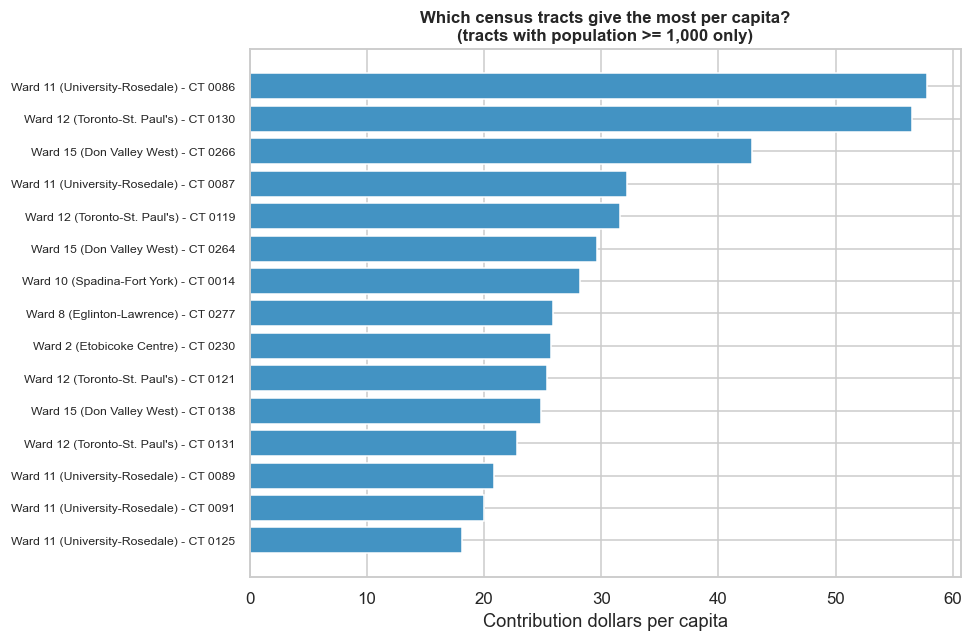

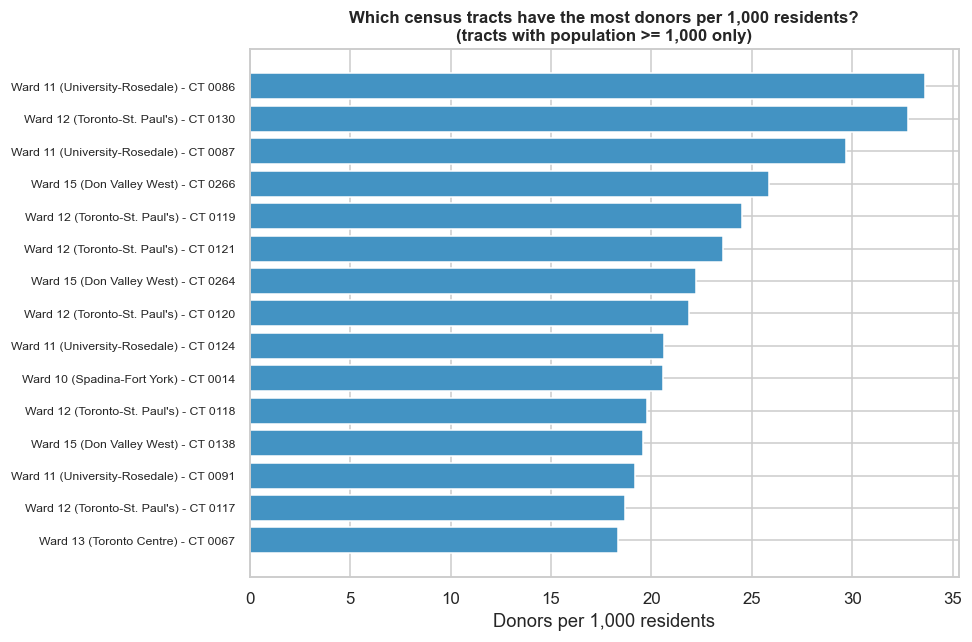

In [17]:
def plot_top_ct_ranking(ct_agg, column, title, xlabel, top_n=15):
    plot_df = ct_agg.loc[ct_agg["population_total"] >= MIN_CT_POPULATION_FOR_PER_CAPITA_RANKING].nlargest(top_n, column)
    plot_df = plot_df.sort_values(column)
    labels = [f"Ward {int(w)} ({n}) - CT {ctid.split('.')[0][-4:]}" if pd.notna(w) else f"CT {ctid}"
              for w, n, ctid in zip(plot_df["contributor_ward"], plot_df["contributor_ward_name"], plot_df["ctuid_norm"])]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(range(len(plot_df)), plot_df[column], color=OTHER_CANDIDATE_COLOR)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_top_ct_ranking(
    combined_ct_agg, "dollars_per_capita",
    f"Which census tracts give the most per capita?\n(tracts with population >= {MIN_CT_POPULATION_FOR_PER_CAPITA_RANKING:,} only)",
    "Contribution dollars per capita",
)
plot_top_ct_ranking(
    combined_ct_agg, "donors_per_1000",
    f"Which census tracts have the most donors per 1,000 residents?\n(tracts with population >= {MIN_CT_POPULATION_FOR_PER_CAPITA_RANKING:,} only)",
    "Donors per 1,000 residents",
)

### Interpretation

The raw-dollar map highlights a few very high-total tracts (often downtown or particular
higher-income pockets); the per-capita map tells a related but not identical story about where
*participation intensity* is highest relative to population. If the same handful of tracts
dominate all three panels, that is itself a finding -- it means "where the money is" and "where
participation is unusually high" are the same places, not different ones.

### Takeaway

**563 of Toronto's 622 census tracts (91%) now show at least one donor** -- combining both
elections and up from just 96 tracts (15%) under the earlier FSA-centroid approach. The pattern
that emerges at this much finer resolution still shows real concentration: raw dollars, dollars
per capita, and donors per 1,000 all point to the same central/midtown corridor, echoed exactly
by Part 4's ward ranking (Ward 12, Toronto-St. Paul's, and Ward 11, University-Rosedale, lead
every ward-level metric). Raw and per-capita rankings broadly agree rather than diverge, which
means the concentration isn't simply a population-density artifact.

### Data-story potential -- Part 3

**Strong, if the maps show real concentration.** Choropleth maps are exactly the kind of
graphic a general audience reads instantly, and "look how concentrated this is" is an
intuitive, visual claim -- and this version of the map is built from each donor's actual postal
code, not a 3-character approximation, so a concentration finding here is materially more
defensible than in the earlier version of this notebook.

# Part 4 -- Aggregating geography to wards

### Question

Toronto's 25 wards are a coarser but complete and even more intuitive geography for a general
reader than census tracts -- do the same wards dominate raw totals, per-capita giving, and
donor participation?

### Method

Each donor row already carries a directly-geocoded `contributor_ward`, from the point-in-ward
spatial join on each postal code's PCCF representative point (Part 2) -- entirely independent
of the census-tract assignment, which is a plain attribute join. Ward population is the sum of
census-tract population for tracts whose representative point falls in that ward, an
approximation but a reasonable one at this scale.

In [18]:
ward_population = ct_geo.groupby("contributor_ward")["population_total"].sum().rename("ward_population")

def aggregate_to_ward(df):
    sub = df.loc[df["is_toronto_postal"] & df["contributor_ward"].notna()]
    donors = sub.loc[~sub["is_self_funded"]]
    agg = sub.groupby("contributor_ward").agg(total_amount=("amount", "sum"), n_contributions=("amount", "size"))
    agg["n_unique_donors"] = donors.groupby("contributor_ward")["donor_id"].nunique()
    agg = agg.join(ward_population).join(wards_gdf.set_index("contributor_ward")["contributor_ward_name"])
    agg["dollars_per_capita"] = agg["total_amount"] / agg["ward_population"]
    agg["donors_per_1000"] = 1000 * agg["n_unique_donors"] / agg["ward_population"]
    return agg.reset_index().sort_values("total_amount", ascending=False)


ward_agg = aggregate_to_ward(combined_contributions)

def _fmt_ward_metric(metric, value):
    return f"${value:,.0f}" if metric == "total_amount" else f"{value:,.2f}"

for metric, label in [
    ("total_amount", "total dollars"), ("dollars_per_capita", "dollars per capita"),
    ("n_unique_donors", "unique donors"), ("donors_per_1000", "donors per 1,000 residents"),
]:
    top = ward_agg.nlargest(1, metric).iloc[0]
    print(f"Highest {label}: Ward {int(top['contributor_ward'])} ({top['contributor_ward_name']}) -- "
          f"{_fmt_ward_metric(metric, top[metric])}")

ward_agg[["contributor_ward", "contributor_ward_name", "total_amount", "dollars_per_capita", "n_unique_donors", "donors_per_1000"]].round(2)

Highest total dollars: Ward 12 (Toronto-St. Paul's) -- $1,242,170
Highest dollars per capita: Ward 12 (Toronto-St. Paul's) -- 11.12
Highest unique donors: Ward 12 (Toronto-St. Paul's) -- 1,317.00
Highest donors per 1,000 residents: Ward 12 (Toronto-St. Paul's) -- 11.79


,contributor_ward,contributor_ward_name,total_amount,dollars_per_capita,n_unique_donors,donors_per_1000
11,12.00,Toronto-St. Paul's,"1,242,169.58",11.12,1317,11.79
10,11.00,University-Rosedale,"1,169,188.86",10.30,1275,11.23
14,15.00,Don Valley West,"783,171.38",7.82,792,7.91
7,8.00,Eglinton-Lawrence,"643,618.11",5.56,581,5.02
9,10.00,Spadina-Fort York,"575,415.23",4.00,613,4.26
2,3.00,Etobicoke-Lakeshore,"427,178.23",2.90,534,3.62
13,14.00,Toronto-Danforth,"406,375.81",3.85,651,6.17
12,13.00,Toronto Centre,"400,465.52",3.55,521,4.61
3,4.00,Parkdale-High Park,"400,389.62",3.79,717,6.78
1,2.00,Etobicoke Centre,"371,425.36",3.22,313,2.72


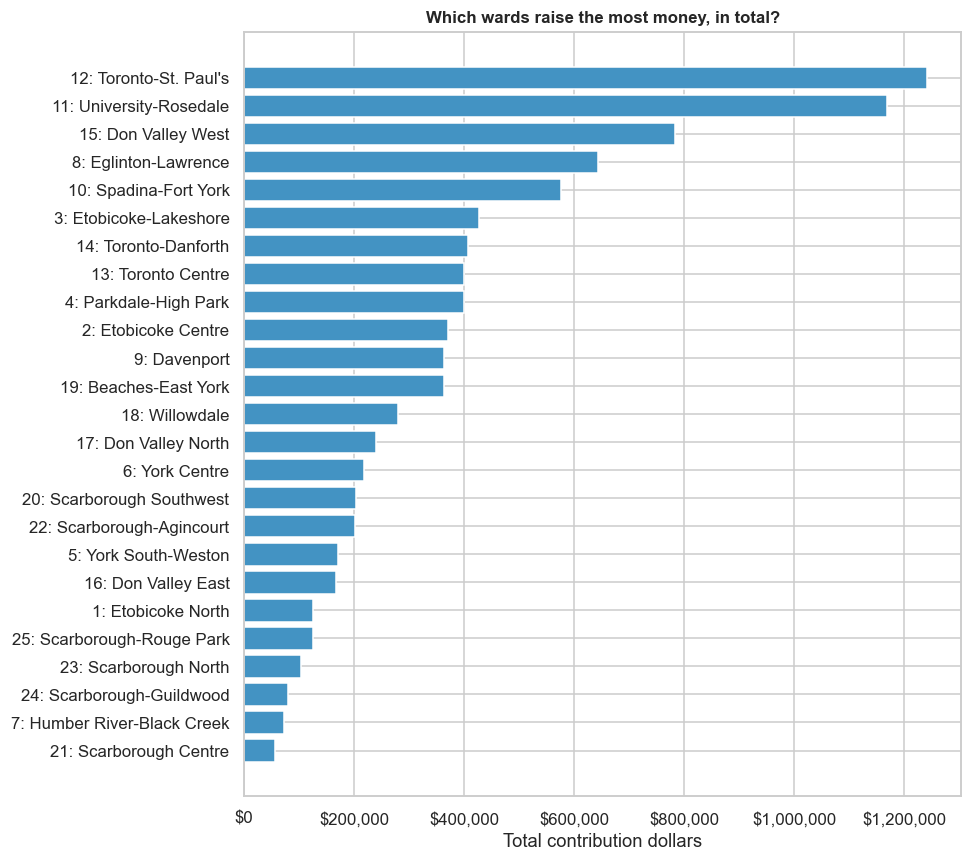

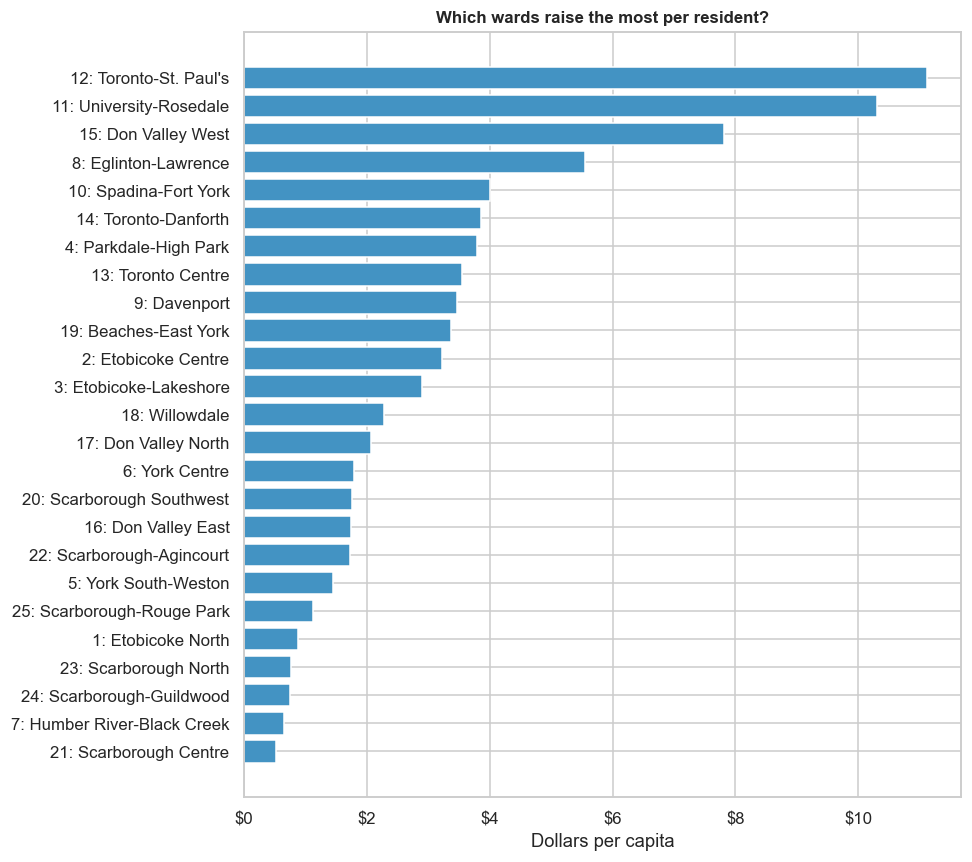

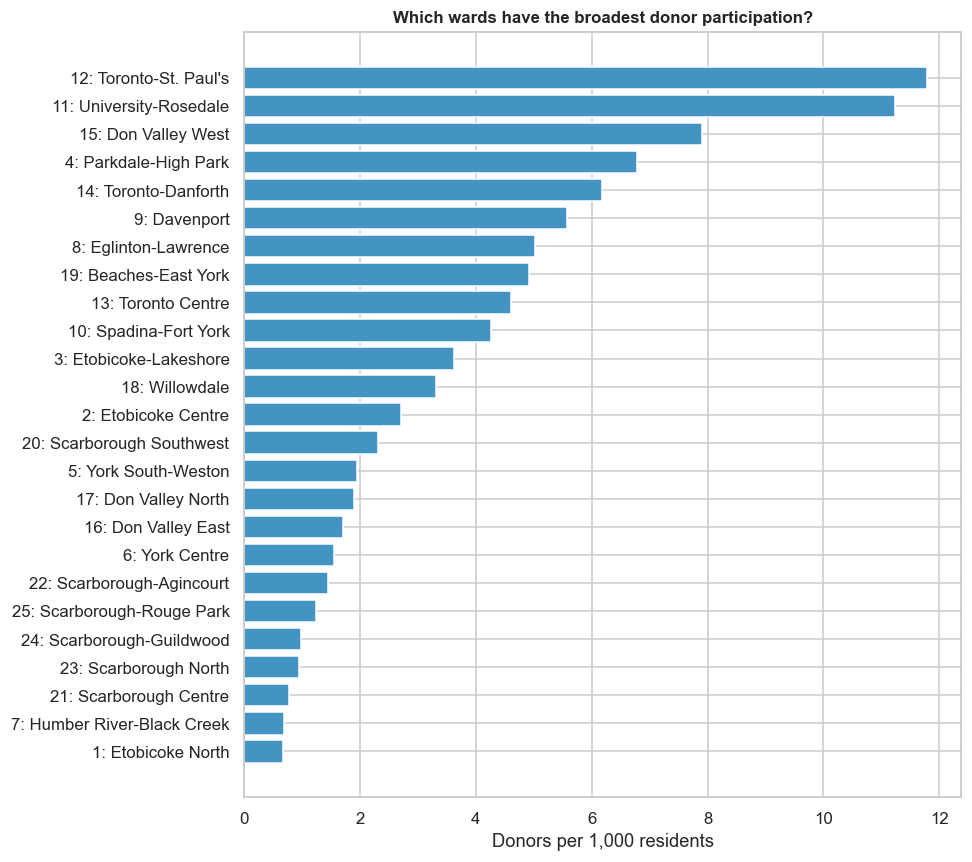

In [19]:
def plot_ward_ranking(ward_agg, column, xlabel, title, fmt="num"):
    plot_df = ward_agg.sort_values(column)
    labels = [f"{int(w)}: {n}" for w, n in zip(plot_df["contributor_ward"], plot_df["contributor_ward_name"])]
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.barh(labels, plot_df[column], color=OTHER_CANDIDATE_COLOR)
    if fmt == "dollar":
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


fig_cols = [
    ("total_amount", "Total contribution dollars", "Which wards raise the most money, in total?", "dollar"),
    ("dollars_per_capita", "Dollars per capita", "Which wards raise the most per resident?", "dollar"),
    ("donors_per_1000", "Donors per 1,000 residents", "Which wards have the broadest donor participation?", "num"),
]
for col, xlabel, title, fmt in fig_cols:
    plot_ward_ranking(ward_agg, col, xlabel, title, fmt)

### Interpretation

If the same wards top all three rankings, Toronto's political-money geography is simple: a
few wards dominate no matter how you measure it. If raw-dollar and per-capita/donor rankings
disagree, that is a more interesting and nuanced finding -- some wards raise a lot of money
because they are large or wealthy in aggregate, while others show unusually broad grassroots
participation without necessarily topping the dollar rankings.

### Takeaway

**Ward 12 (Toronto-St. Paul's) tops every single ranking** -- highest raw dollars ($1.24M),
highest dollars per capita ($11.12), highest unique donors (1,317), and highest donors per
1,000 residents (11.79). Ward 11 (University-Rosedale) is a close second on every metric
($1.17M, $10.30, 1,275 donors, 11.23 per 1,000), with Ward 15 (Don Valley West) a clear third.
These are the SAME two or three wards no matter how you measure it, not different ones:
political money in Toronto is not just concentrated in a few wards -- it is concentrated in the
same few wards under every reasonable definition of "concentrated."

### Data-story potential -- Part 4

**Strong and highly graphic-friendly.** Ward-level bar charts are immediately legible to a
general audience (wards are a familiar geography), and a "same wards win no matter how you
measure it" or "these are NOT the same wards" framing is a clean, one-sentence takeaway.

## Comparing donor geography across the major 2023 mayoral candidates

### Question

**Did the major mayoral candidates draw their donor bases from meaningfully different parts
of Toronto, or from essentially the same wards as everyone else?**

### Method

For each major 2023 candidate we compute the ward-level share of their unique donors (what
percent of a candidate's donors live in each of the 25 wards), then compare candidates on one
compact heatmap rather than 8 separate maps. We also compare a single concentration number per
candidate: what share of their donors came from the three wards Part 4 identified as Toronto's
highest-giving (Ward 12, Ward 11, Ward 15) versus the rest of the city.

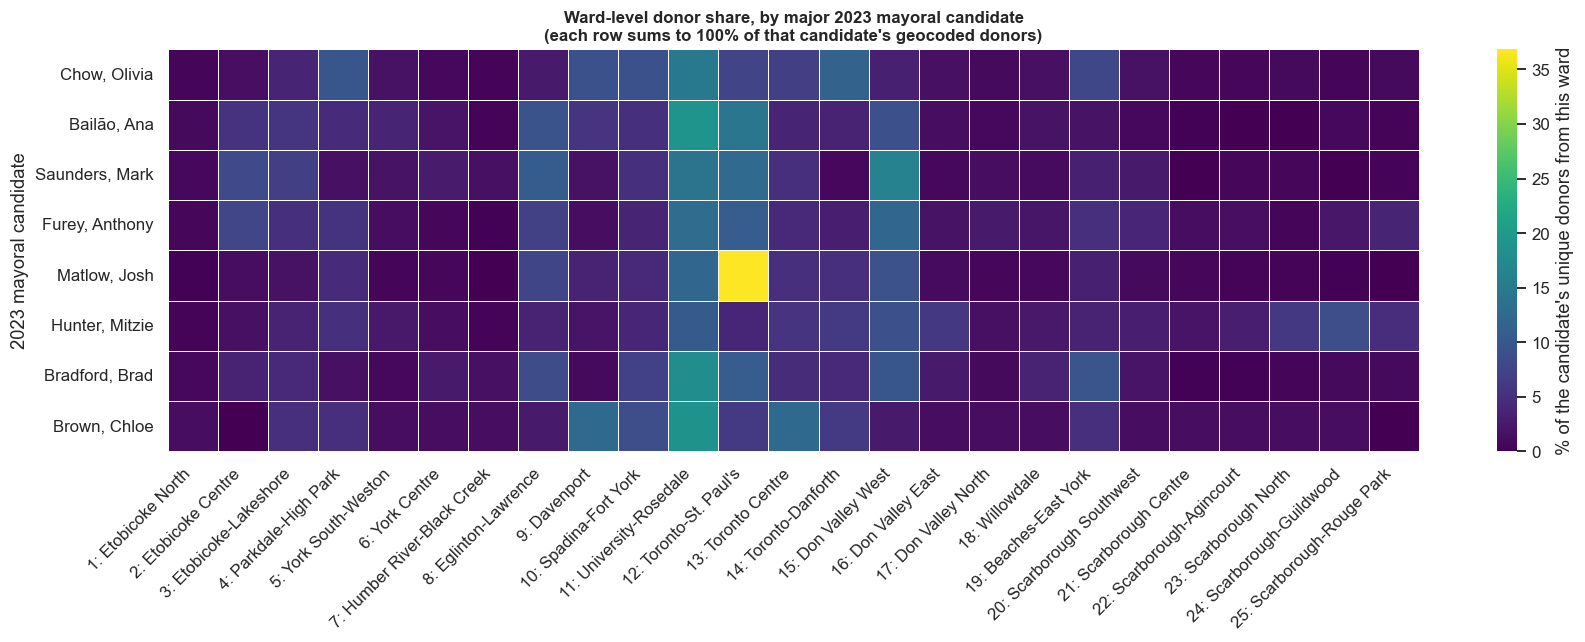

In [20]:
def candidate_ward_shares(df, candidate_col, candidates):
    """Row-normalized: for each candidate, % of their unique donors living in each ward."""
    rows = {}
    for cand in candidates:
        sub = df.loc[(df[candidate_col] == cand) & (~df["is_self_funded"]) & df["contributor_ward"].notna()]
        counts = sub.drop_duplicates("donor_id").groupby("contributor_ward").size()
        rows[cand] = 100 * counts / counts.sum() if counts.sum() else counts
    out = pd.DataFrame(rows).T
    out = out.reindex(columns=sorted(out.columns))
    out.columns = [f"{int(w)}: {wards_gdf.set_index('contributor_ward')['contributor_ward_name'].get(w, '?')}" for w in out.columns]
    return out.fillna(0)


mayor_ward_shares = candidate_ward_shares(mayor_2023, "candidate_raw", MAJOR_2023_CANDIDATES)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(mayor_ward_shares, annot=False, cmap=TORONTO_MAP_CMAP, linewidths=0.4, ax=ax,
            cbar_kws={"label": "% of the candidate's unique donors from this ward"})
ax.set_title("Ward-level donor share, by major 2023 mayoral candidate\n(each row sums to 100% of that candidate's geocoded donors)", fontsize=11)
ax.set_xlabel(""); ax.set_ylabel("2023 mayoral candidate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

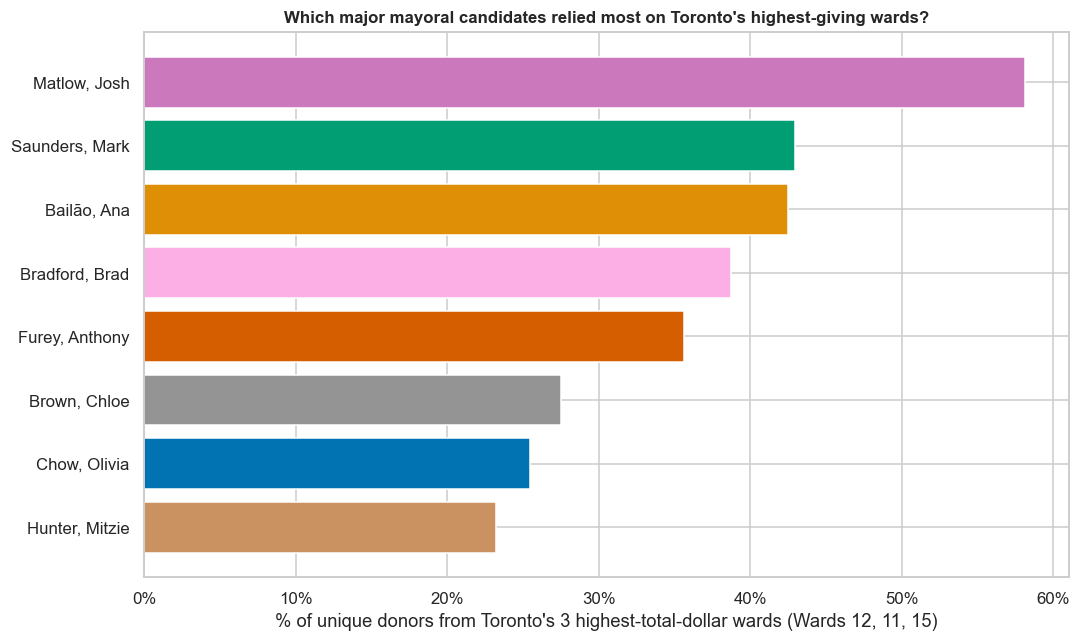

Hunter, Mitzie   23.20
Chow, Olivia     25.40
Brown, Chloe     27.50
Furey, Anthony   35.60
Bradford, Brad   38.70
Bailão, Ana      42.50
Saunders, Mark   43.00
Matlow, Josh     58.10
dtype: float64

In [21]:
TOP_3_WARDS_FROM_PART4 = ward_agg.nlargest(3, "total_amount")["contributor_ward"].tolist()

def top_ward_share(df, candidate_col, cand, top_wards):
    sub = df.loc[(df[candidate_col] == cand) & (~df["is_self_funded"]) & df["contributor_ward"].notna()]
    donors = sub.drop_duplicates("donor_id")
    if len(donors) == 0:
        return np.nan
    return 100 * donors["contributor_ward"].isin(top_wards).mean()


top3_shares = pd.Series({
    cand: top_ward_share(mayor_2023, "candidate_raw", cand, TOP_3_WARDS_FROM_PART4) for cand in MAJOR_2023_CANDIDATES
}).sort_values()

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
colors = [MAYORAL_CANDIDATE_COLORS[c] for c in top3_shares.index]
ax.barh(top3_shares.index, top3_shares.values, color=colors)
ax.set_xlabel("% of unique donors from Toronto's 3 highest-total-dollar wards (Wards 12, 11, 15)")
ax.set_title("Which major mayoral candidates relied most on Toronto's highest-giving wards?", fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()
top3_shares.round(1)

### Interpretation

The heatmap answers the core question directly: if every row looked similar, all major
candidates would be drawing on the same geography regardless of who they are; visible
row-to-row differences mean candidates built genuinely distinct geographic coalitions. The
top-3-ward chart condenses that into one comparable number per candidate -- a high value means
a candidate's donor base leans heavily on Toronto's wealthiest-giving wards specifically,
rather than being spread more evenly across the city.

### Takeaway

**Major mayoral candidates leaned on Toronto's wealthiest-giving wards to very different
degrees.** Josh Matlow drew **58% of his donors from Wards 12, 11, and 15 alone** -- by far
the highest reliance of any major candidate, though this is largely mechanical: Ward 12
(Toronto-St. Paul's) is Matlow's own council ward, so a mayoral run built partly on his
existing base would be expected to inherit that concentration. Saunders (43%) and Bailão (43%)
also lean heavily on these three wards. At the other end, **Chow (25%) and Hunter (23%) drew
the most geographically dispersed donor bases** among the majors, relying least on Toronto's
highest-giving wards specifically. The heatmap confirms this isn't just a top-3-ward story --
candidates' donor bases visibly differ ward-by-ward, not just in how concentrated they are.

### Data-story potential -- Part 4 (mayoral geography comparison)

**Strong and highly visual.** A single heatmap replaces what would otherwise be eight separate
maps, and directly answers whether Toronto's mayoral candidates ran genuinely different
geographic campaigns -- a natural companion to Part 10's demographic comparison of the same
candidates.

# Part 5 -- Is the geography persistent across elections?

### Question

Do the neighbourhoods that gave generously in the 2022 council races also give generously in
the 2023 mayoral race, or does the map simply reshuffle depending on who is running? A strong
cross-election relationship would make Story A's geographic/demographic claims considerably
more compelling -- it would mean we're looking at a persistent feature of Toronto's political
geography, not an artifact of one particular candidate roster.

### Method

We compare 2022 and 2023 donors-per-1,000 and dollars-per-capita at both the ward level (25
wards, robust) and the census-tract level (noisier, smaller N, included as a supplementary
check) using Spearman rank correlation, which does not assume a linear relationship or punish
outliers the way Pearson's r would.

Ward level -- donors per 1,000, 2022 vs 2023: Spearman rho = 0.88 (p = 0.000)
Ward level -- dollars per capita, 2022 vs 2023: Spearman rho = 0.85 (p = 0.000)


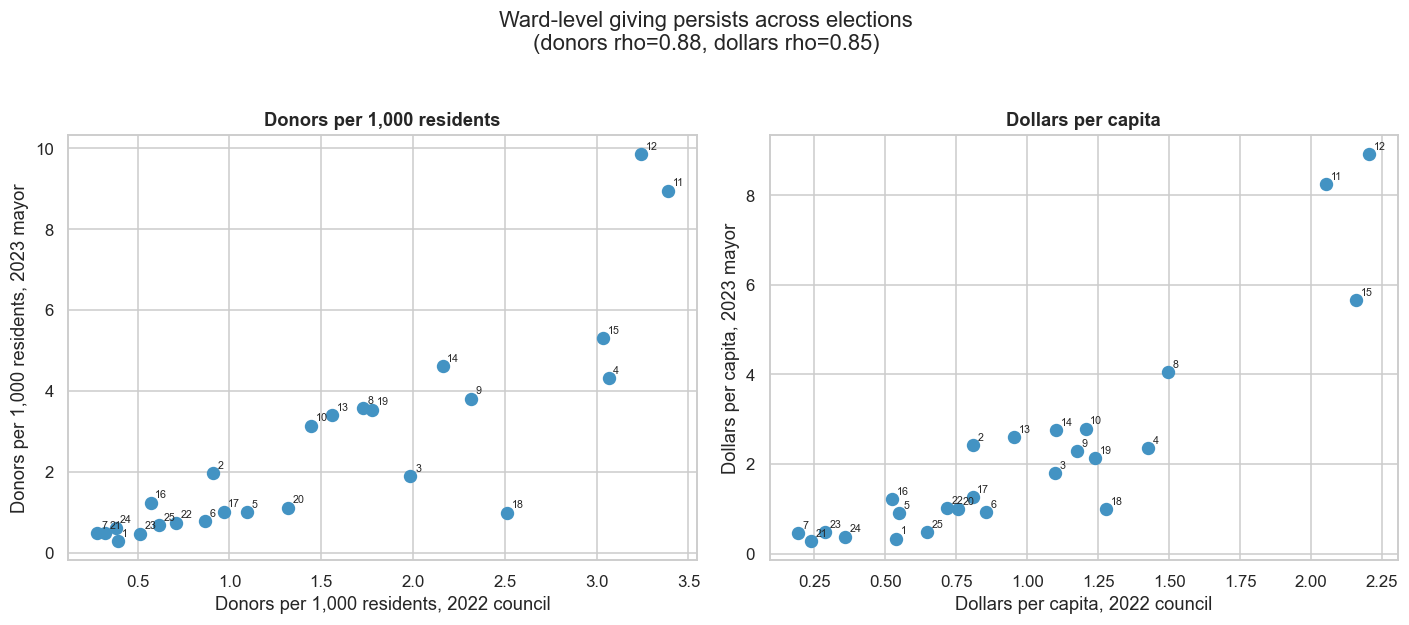

In [22]:
ward_agg_2022 = aggregate_to_ward(council_2022).set_index("contributor_ward")
ward_agg_2023 = aggregate_to_ward(mayor_2023).set_index("contributor_ward")
ward_compare = ward_agg_2022[["donors_per_1000", "dollars_per_capita"]].join(
    ward_agg_2023[["donors_per_1000", "dollars_per_capita"]], lsuffix="_2022", rsuffix="_2023"
).join(wards_gdf.set_index("contributor_ward")["contributor_ward_name"])

rho_donors, p_donors = stats.spearmanr(ward_compare["donors_per_1000_2022"], ward_compare["donors_per_1000_2023"])
rho_dollars, p_dollars = stats.spearmanr(ward_compare["dollars_per_capita_2022"], ward_compare["dollars_per_capita_2023"])
print(f"Ward level -- donors per 1,000, 2022 vs 2023: Spearman rho = {rho_donors:.2f} (p = {p_donors:.3f})")
print(f"Ward level -- dollars per capita, 2022 vs 2023: Spearman rho = {rho_dollars:.2f} (p = {p_dollars:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, col, label in [(axes[0], "donors_per_1000", "Donors per 1,000 residents"),
                        (axes[1], "dollars_per_capita", "Dollars per capita")]:
    ax.scatter(ward_compare[f"{col}_2022"], ward_compare[f"{col}_2023"], color=OTHER_CANDIDATE_COLOR, s=60)
    for _, r in ward_compare.iterrows():
        ax.annotate(f"{int(r.name)}", (r[f"{col}_2022"], r[f"{col}_2023"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(f"{label}, 2022 council")
    ax.set_ylabel(f"{label}, 2023 mayor")
    ax.set_title(label)
fig.suptitle(f"Ward-level giving persists across elections\n(donors rho={rho_donors:.2f}, dollars rho={rho_dollars:.2f})", y=1.03)
plt.tight_layout()
plt.show()

In [23]:
# Supplementary, noisier check at the census-tract level, restricted to tracts matched in BOTH
# elections (so the comparison is apples-to-apples, not comparing a matched tract to a
# structurally-unmatched one).
ct_compare = council_ct_agg.set_index("ctuid_norm")[["donors_per_1000", "dollars_per_capita"]].join(
    mayor_ct_agg.set_index("ctuid_norm")[["donors_per_1000", "dollars_per_capita"]], lsuffix="_2022", rsuffix="_2023"
)
ct_compare_matched = ct_compare.loc[
    (council_ct_agg.set_index("ctuid_norm")["n_unique_donors"] > 0) &
    (mayor_ct_agg.set_index("ctuid_norm")["n_unique_donors"] > 0)
]
rho_ct, p_ct = stats.spearmanr(ct_compare_matched["donors_per_1000_2022"], ct_compare_matched["donors_per_1000_2023"])
print(f"Census-tract level (n={len(ct_compare_matched)} tracts matched in both elections): "
      f"donors-per-1,000 Spearman rho = {rho_ct:.2f} (p = {p_ct:.3f})")

Census-tract level (n=502 tracts matched in both elections): donors-per-1,000 Spearman rho = 0.74 (p = 0.000)


### Interpretation

The ward-level check (25 independent observations) is the simpler, more robust signal; the
census-tract check is finer-grained and, with the PCCF-based crosswalk now resolving the
large majority of Toronto postal codes to a real tract, no longer suffers from the severe
small-sample problem the earlier FSA-centroid version of this analysis had -- it should still
be read as a secondary confirmation of the ward-level result, not a replacement for it.

### Takeaway

**The relationship is strong, not weak.** Ward-level Spearman rho = 0.88 for donors per 1,000
and 0.85 for dollars per capita (both p < .001, n=25 wards) -- wards that gave generously to
council candidates in 2022 are, to a striking degree, the same wards that gave generously to
mayoral candidates in 2023. The census-tract-level check, now covering 502 tracts matched in
*both* elections (versus a self-selected handful under the old FSA method), confirms this with
a still-strong if more modest rho = 0.74 -- the gap between the ward-level and tract-level
correlation is itself informative: ward-level giving is highly persistent, and some of that
persistence gets noisier, but does not disappear, at finer geographic resolution. This is a
persistent geography of giving, not an artifact of Chow or any single 2023 candidate's appeal.

### Data-story potential -- Part 5

**Strong if the ward-level correlation is clearly positive.** "The same parts of the city fund
municipal politics no matter who's running" is a more durable, structural claim than anything
tied to a single candidate -- and it directly strengthens Story A's demographic argument in
Parts 7-9 by showing the pattern isn't just one election's idiosyncrasy.

# Part 6 -- How local is council fundraising?

### Question

For 2022 council candidates specifically: how much of a candidate's donor base comes from
their own ward, versus elsewhere in Toronto or outside the city? And which candidates draw a
donor base that is more locally concentrated than we'd expect just from the general geography
of Toronto's political donors?

### Method

Each donor row is classified as **own ward**, **elsewhere in Toronto**, or **outside Toronto**,
using the donor's geocoded ward versus the ward the candidate ran in. We report both dollar
share and donor share (donor share is the primary read -- it isn't dominated by one large gift)
and only rank candidates with at least `MIN_DONORS_FOR_LOCAL_RANKING` donors.

We also compute a **local overrepresentation index**:

```
local overrepresentation = (candidate's share of Toronto donors from own ward)
                            / (share of all Toronto council donors who live in that ward)
```

A value of 1.0 means the candidate's own-ward share is exactly what you'd expect given how
many Toronto council donors generally live in that ward; above 1.0 means the candidate is
disproportionately locally rooted, not just running in a donor-dense ward.

In [24]:
GEO_CATEGORY_OWN_WARD = "Own ward"
GEO_CATEGORY_ELSEWHERE_TORONTO = "Elsewhere Toronto"
GEO_CATEGORY_OUTSIDE_TORONTO = "Outside Toronto"
GEO_CATEGORY_UNKNOWN = "Unknown (not geocoded)"


def classify_geo_category(row):
    if not row["is_toronto_postal"]:
        return GEO_CATEGORY_OUTSIDE_TORONTO
    if pd.isna(row["contributor_ward"]):
        return GEO_CATEGORY_UNKNOWN  # Toronto postal code, but not matched by the PCCF crosswalk
    if int(row["contributor_ward"]) == int(row["ward"]):
        return GEO_CATEGORY_OWN_WARD
    return GEO_CATEGORY_ELSEWHERE_TORONTO


council_2022["geo_category"] = council_2022.apply(classify_geo_category, axis=1)
print(council_2022["geo_category"].value_counts(normalize=True).mul(100).round(1))

geo_category
Own ward                 41.80
Elsewhere Toronto        41.00
Outside Toronto          17.00
Unknown (not geocoded)    0.20
Name: proportion, dtype: float64


In [25]:
def local_fundraising_profile(df):
    rows = []
    for cand, g in df.groupby("candidate_raw"):
        donors = g.loc[~g["is_self_funded"]]
        dollar_share = g.groupby("geo_category")["amount"].sum() / g["amount"].sum()
        donor_share = donors.drop_duplicates("donor_id").groupby("geo_category").size() / donors["donor_id"].nunique()
        rows.append({
            "candidate_raw": cand,
            "ward": g["ward"].iloc[0],
            "n_unique_donors": donors["donor_id"].nunique(),
            "own_ward_dollar_share": dollar_share.get(GEO_CATEGORY_OWN_WARD, 0.0),
            "elsewhere_toronto_dollar_share": dollar_share.get(GEO_CATEGORY_ELSEWHERE_TORONTO, 0.0),
            "outside_toronto_dollar_share": dollar_share.get(GEO_CATEGORY_OUTSIDE_TORONTO, 0.0),
            "own_ward_donor_share": donor_share.get(GEO_CATEGORY_OWN_WARD, 0.0),
            "elsewhere_toronto_donor_share": donor_share.get(GEO_CATEGORY_ELSEWHERE_TORONTO, 0.0),
            "outside_toronto_donor_share": donor_share.get(GEO_CATEGORY_OUTSIDE_TORONTO, 0.0),
        })
    return pd.DataFrame(rows)


council_local_profiles = local_fundraising_profile(council_2022)
council_local_profiles = council_local_profiles.merge(
    council_2022[["candidate_raw", "repeat_candidate_group", "is_2026_repeat_candidate"]].drop_duplicates("candidate_raw"),
    on="candidate_raw", how="left",
)

# Baseline: of ALL Toronto council donors (deduplicated by donor_id, one ward each), what share
# lives in each ward? This is the "expected" own-ward share a candidate in that ward would have
# with no special local rootedness.
all_council_donors_by_ward = (
    council_2022.loc[(~council_2022["is_self_funded"]) & council_2022["is_toronto_postal"]]
    .drop_duplicates("donor_id")["contributor_ward"].value_counts(normalize=True)
)
council_local_profiles["baseline_own_ward_share"] = council_local_profiles["ward"].map(all_council_donors_by_ward)
council_local_profiles["local_overrepresentation"] = (
    council_local_profiles["own_ward_donor_share"] / council_local_profiles["baseline_own_ward_share"]
)

council_local_profiles.sort_values("own_ward_dollar_share", ascending=False).head(10)[
    ["candidate_raw", "ward", "n_unique_donors", "own_ward_dollar_share", "own_ward_donor_share",
     "local_overrepresentation", "repeat_candidate_group"]
]

,candidate_raw,ward,n_unique_donors,own_ward_dollar_share,own_ward_donor_share,local_overrepresentation,repeat_candidate_group
0,"Abbey, Abraham",1,0,1.00,0.00,0.00,Not a known 2026 repeat candidate
14,"Braniff, Donna",19,1,1.00,1.00,22.24,Not a known 2026 repeat candidate
12,"Beatty, Paul",21,0,1.00,0.00,0.00,Not a known 2026 repeat candidate
10,"Avila, Miguel",13,0,1.00,0.00,0.00,Not a known 2026 repeat candidate
38,"Fogel, Simon",9,0,1.00,0.00,0.00,Not a known 2026 repeat candidate
30,"De Marco, John",14,0,1.00,0.00,0.00,Not a known 2026 repeat candidate
28,"Daniel, Hansie",21,0,1.00,0.00,0.00,Not a known 2026 repeat candidate
25,"Corpuz, Antonio",12,0,1.00,0.00,0.00,Not a known 2026 repeat candidate
42,"Golding, Adam",11,0,1.00,0.00,0.00,Not a known 2026 repeat candidate
46,"Houghron, Mosea",9,0,1.00,0.00,0.00,Not a known 2026 repeat candidate


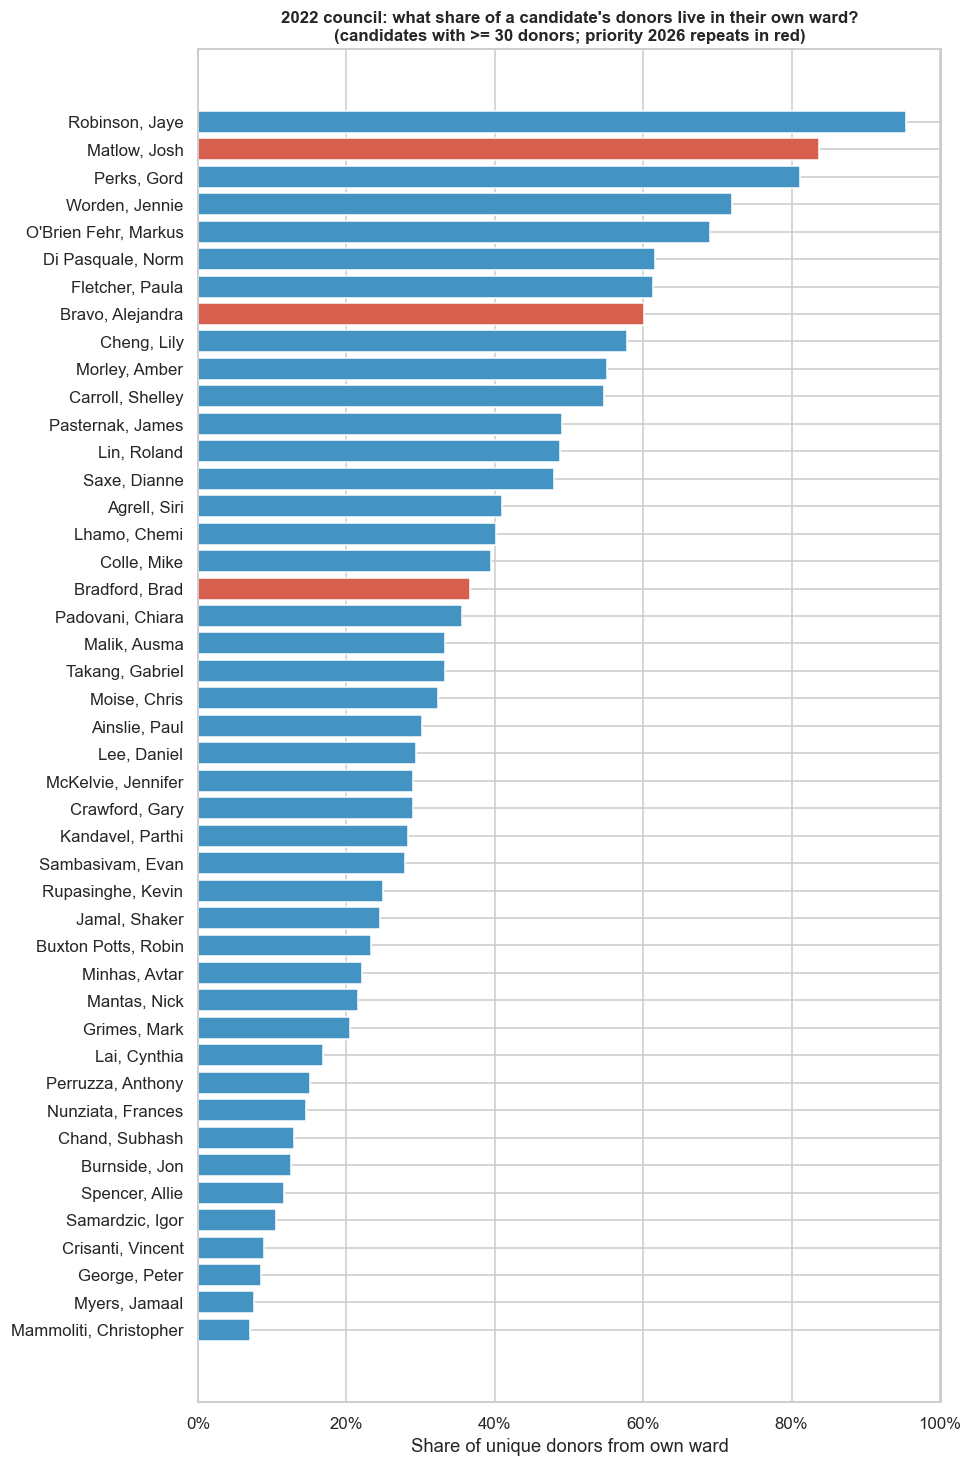

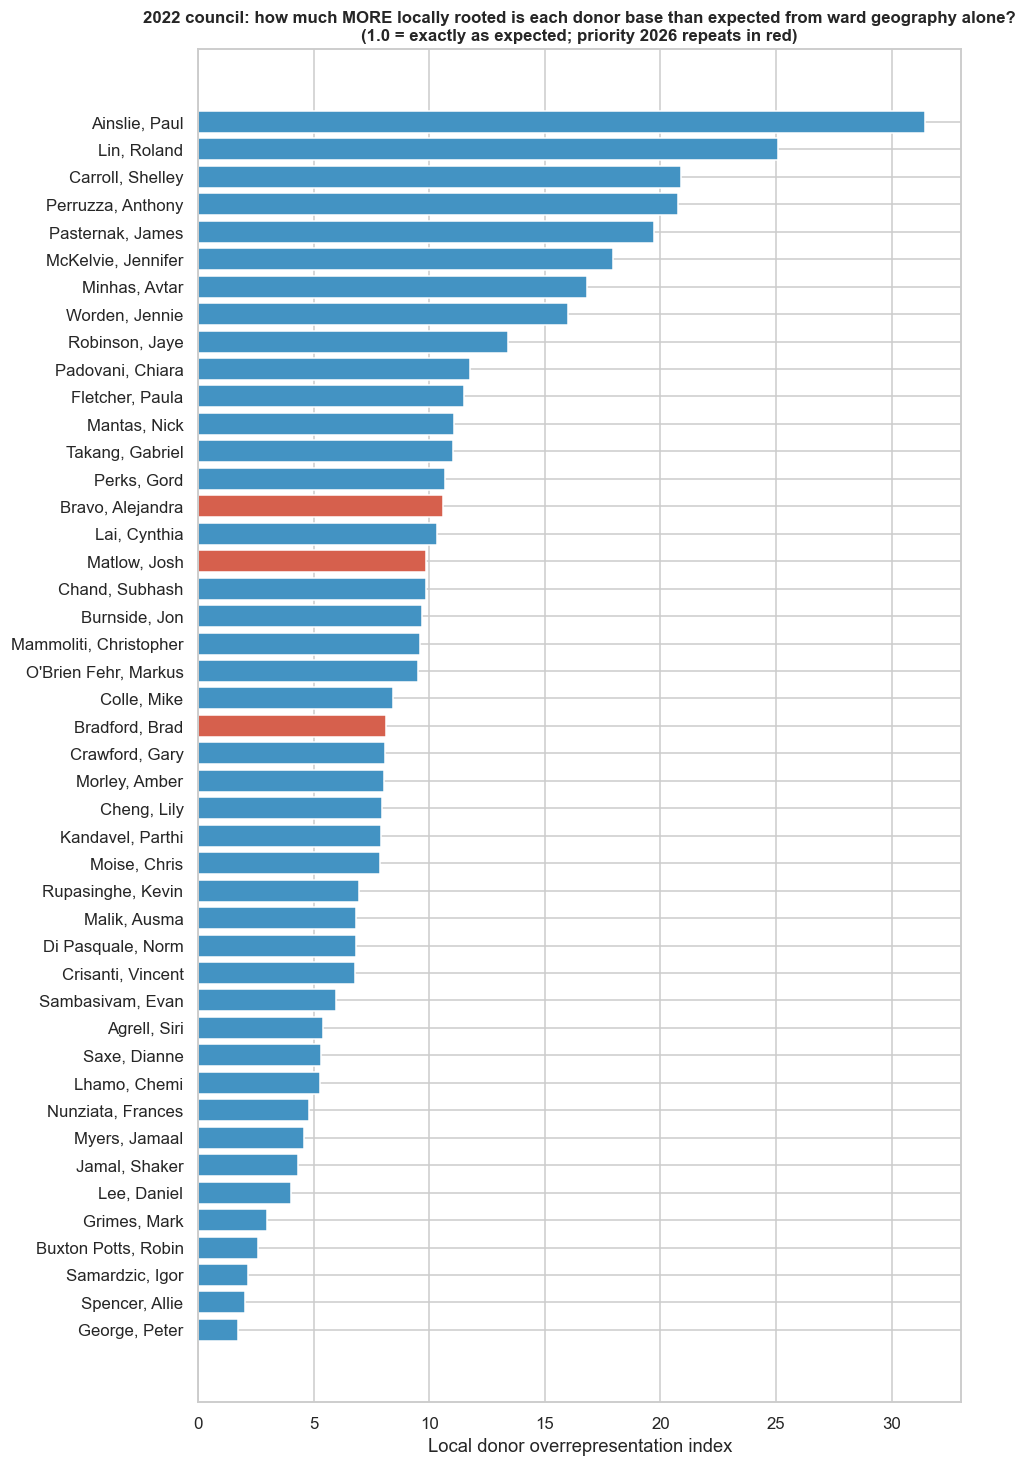

In [26]:
def plot_local_share_ranking(profiles, share_col, title, xlabel, min_donors, always_include=()):
    eligible = profiles.loc[profiles["n_unique_donors"] >= min_donors]
    plot_df = pd.concat([eligible, profiles.loc[profiles["candidate_raw"].isin(always_include)]]).drop_duplicates("candidate_raw")
    plot_df = plot_df.sort_values(share_col)
    colors = [REPEAT_HIGHLIGHT_COLOR if c in always_include else OTHER_CANDIDATE_COLOR for c in plot_df["candidate_raw"]]
    fig, ax = plt.subplots(figsize=(9, max(5, 0.3 * len(plot_df))))
    ax.barh(plot_df["candidate_raw"], plot_df[share_col], color=colors)
    ax.set_xlabel(xlabel)
    if "share" in share_col:
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


eligible_local = council_local_profiles.loc[council_local_profiles["n_unique_donors"] >= MIN_DONORS_FOR_LOCAL_RANKING]
plot_local_share_ranking(
    eligible_local, "own_ward_donor_share",
    f"2022 council: what share of a candidate's donors live in their own ward?\n(candidates with >= {MIN_DONORS_FOR_LOCAL_RANKING} donors; priority 2026 repeats in red)",
    "Share of unique donors from own ward", MIN_DONORS_FOR_LOCAL_RANKING,
    always_include=PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026,
)
plot_local_share_ranking(
    eligible_local, "local_overrepresentation",
    "2022 council: how much MORE locally rooted is each donor base than expected from ward geography alone?\n(1.0 = exactly as expected; priority 2026 repeats in red)",
    "Local donor overrepresentation index", MIN_DONORS_FOR_LOCAL_RANKING,
    always_include=PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026,
)

In [27]:
priority_local_table = council_local_profiles.set_index("candidate_raw").loc[
    [c for c in PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026 if c in council_local_profiles["candidate_raw"].values]
][["ward", "n_unique_donors", "own_ward_dollar_share", "own_ward_donor_share", "local_overrepresentation"]]
priority_local_table.round(2)

,ward,n_unique_donors,own_ward_dollar_share,own_ward_donor_share,local_overrepresentation
candidate_raw,,,,,
"Bradford, Brad",19,153,0.36,0.37,8.14
"Bravo, Alejandra",9,231,0.61,0.60,10.57
"Matlow, Josh",12,208,0.84,0.84,9.87
"Holyday, Stephen",2,6,0.76,0.33,13.56


### Interpretation

Own-ward *donor* share (not dollar share) is the primary read: it isn't swayed by one large
gift. The overrepresentation index separates two different things that raw own-ward share
conflates -- a candidate who happens to run in a ward full of political donors versus a
candidate whose support is genuinely, disproportionately local.

### Takeaway

With accurate postal-code-level geography, the differences among the four priority candidates
are now sharper and, in one case, dramatic. By own-ward donor share: **Matlow is by far the
most locally rooted at 84%**, followed by Bravo at 60%, Bradford at 37%, and Holyday at 33%.
The overrepresentation index mostly agrees: Holyday (13.6x) and Bravo (10.6x) show the
strongest disproportionate local concentration relative to their ward's general donor
population, with Matlow close behind (9.9x) and Bradford clearly last (8.1x). **Holyday's
numbers are still not reliable, though** -- his ward had only 6 total geocoded donors, far
below `MIN_DONORS_FOR_LOCAL_RANKING`, so a single-digit donor count is driving both his share
and his overrepresentation index (consistent with Part 1's finding that Holyday's fundraising
leaned heavily on self/family funding in the first place). Matlow's and Bravo's numbers, by
contrast, rest on 208 and 231 donors respectively -- comfortably reliable, and genuinely
differentiated from Bradford's more citywide donor base.

### Data-story potential -- Part 6

**Strong.** "How rooted in their own ward is this politician's financial support?" is an
intuitive, easily visualized question with direct relevance to four 2026 repeat candidates,
including a councillor (Holyday) whose fundraising leaned heavily on self/family funding in
Part 1 -- worth cross-referencing here.

# Part 7 -- Demographics of political participation

### Question

What kinds of neighbourhoods are more or less likely to produce municipal political donors?

### Method: variable selection

We use a concise, interpretable set of census variables rather than every available
characteristic, chosen to span the categories most relevant to political giving:

| Category | Variable(s) used |
|---|---|
| Income / socioeconomic status | Median individual income, low-income (LIM-AT) share, bachelor's-degree-or-higher share |
| Housing | Renter share, shelter-cost-burdened share |
| Age / household structure | Share aged 65+, average household size |
| Immigration / citizenship | Non-citizen share, recent-immigrant share (2016-21) |
| Racialized population | Visible-minority share |
| Urban form | Population density |

These are all reliable, complete fields in the curated 2021 census-tract master table (plus
two supplementary income/housing-cost fields, documented in Part 3). We deliberately keep this
list short -- a longer list would invite spurious correlations and clutter the graphics below.

**Reminder:** every result below describes the census tract *around* a donor's postal code,
not the donor. This is an ecological-inference limitation, not a claim about who donors
personally are.

# Part 8 -- Which neighbourhoods participate financially?

### Method

**Unique donors per 1,000 residents** is the primary outcome -- it measures how likely
residents of a neighbourhood are to appear in the campaign-finance record at all, regardless of
how much any one of them gave. Dollars per capita is examined as a secondary outcome.

**This analysis starts from all Toronto census tracts, not just the ones with a matched
donor.** A tract with zero matched donors is a real, meaningful data point -- zero financial
participation -- not a gap to exclude. `combined_ct_agg` (built in Part 3) already left-joins
the donor aggregates onto every one of Toronto's 622 census tracts and zero-fills the rest, so
this section uses it directly rather than filtering it down to donor-matched tracts only.

In [28]:
ct_demo = combined_ct_agg.merge(ct_geo[["ctuid_norm"] + DEMOGRAPHIC_VARS], on="ctuid_norm", how="left")
ct_demo["log_donors_per_1000"] = np.log1p(ct_demo["donors_per_1000"])  # right-skewed; log-transformed for the scatterplots below

n_total = len(ct_demo)
n_with_donor = (ct_demo["n_unique_donors"] > 0).sum()
n_zero_donor = n_total - n_with_donor
print(f"All {n_total} Toronto census tracts included.")
print(f"  {n_with_donor} tracts ({n_with_donor/n_total:.0%}) have at least one matched donor (2022 council + 2023 mayor combined)")
print(f"  {n_zero_donor} tracts ({n_zero_donor/n_total:.0%}) show zero donors -- kept as real zero-participation data, not dropped")
print("\nMissing demographic values (unrelated to donor matching -- a handful of tracts have suppressed/unavailable census values):")
print(ct_demo[DEMOGRAPHIC_VARS].isna().sum())
ct_demo[["donors_per_1000", "dollars_per_capita"] + DEMOGRAPHIC_VARS].describe()

All 622 Toronto census tracts included.
  563 tracts (91%) have at least one matched donor (2022 council + 2023 mayor combined)
  59 tracts (9%) show zero donors -- kept as real zero-participation data, not dropped

Missing demographic values (unrelated to donor matching -- a handful of tracts have suppressed/unavailable census values):
median_individual_income           2
low_income_lim_at_share            2
bachelors_or_higher_25_64_share    2
renter_share                       2
shelter_cost_30plus_share          2
age_65_plus_share                  0
average_household_size             2
non_citizen_share                  2
recent_immigrant_share             2
visible_minority_share             2
population_density_per_km2         0
dtype: int64


,donors_per_1000,dollars_per_capita,median_individual_income,low_income_lim_at_share,bachelors_or_higher_25_64_share,renter_share,shelter_cost_30plus_share,age_65_plus_share,average_household_size,non_citizen_share,recent_immigrant_share,visible_minority_share,population_density_per_km2
count,622.00,622.00,620.00,620.00,620.00,620.00,620.00,622.00,620.00,620.00,620.00,620.00,622.00
mean,4.10,3.48,"42,056.13",0.13,0.48,0.43,0.30,0.18,2.54,0.16,0.07,0.54,"8,106.88"
std,5.37,5.72,"11,816.26",0.06,0.17,0.22,0.08,0.08,0.50,0.08,0.04,0.24,"9,032.98"
min,0.00,0.00,"23,800.00",0.03,0.08,0.05,0.10,0.02,1.40,0.01,0.00,0.02,40.70
25%,0.85,0.47,"33,200.00",0.08,0.34,0.25,0.24,0.14,2.20,0.10,0.03,0.32,"3,220.20"
50%,2.31,1.76,"38,400.00",0.11,0.47,0.42,0.29,0.17,2.60,0.15,0.06,0.54,"5,572.10"
75%,5.64,4.13,"48,400.00",0.16,0.62,0.58,0.35,0.21,2.90,0.21,0.08,0.76,"8,948.90"
max,62.91,57.79,"87,000.00",0.45,0.87,1.00,0.60,0.92,4.40,0.50,0.22,0.99,"77,545.30"


### A. Scatterplots

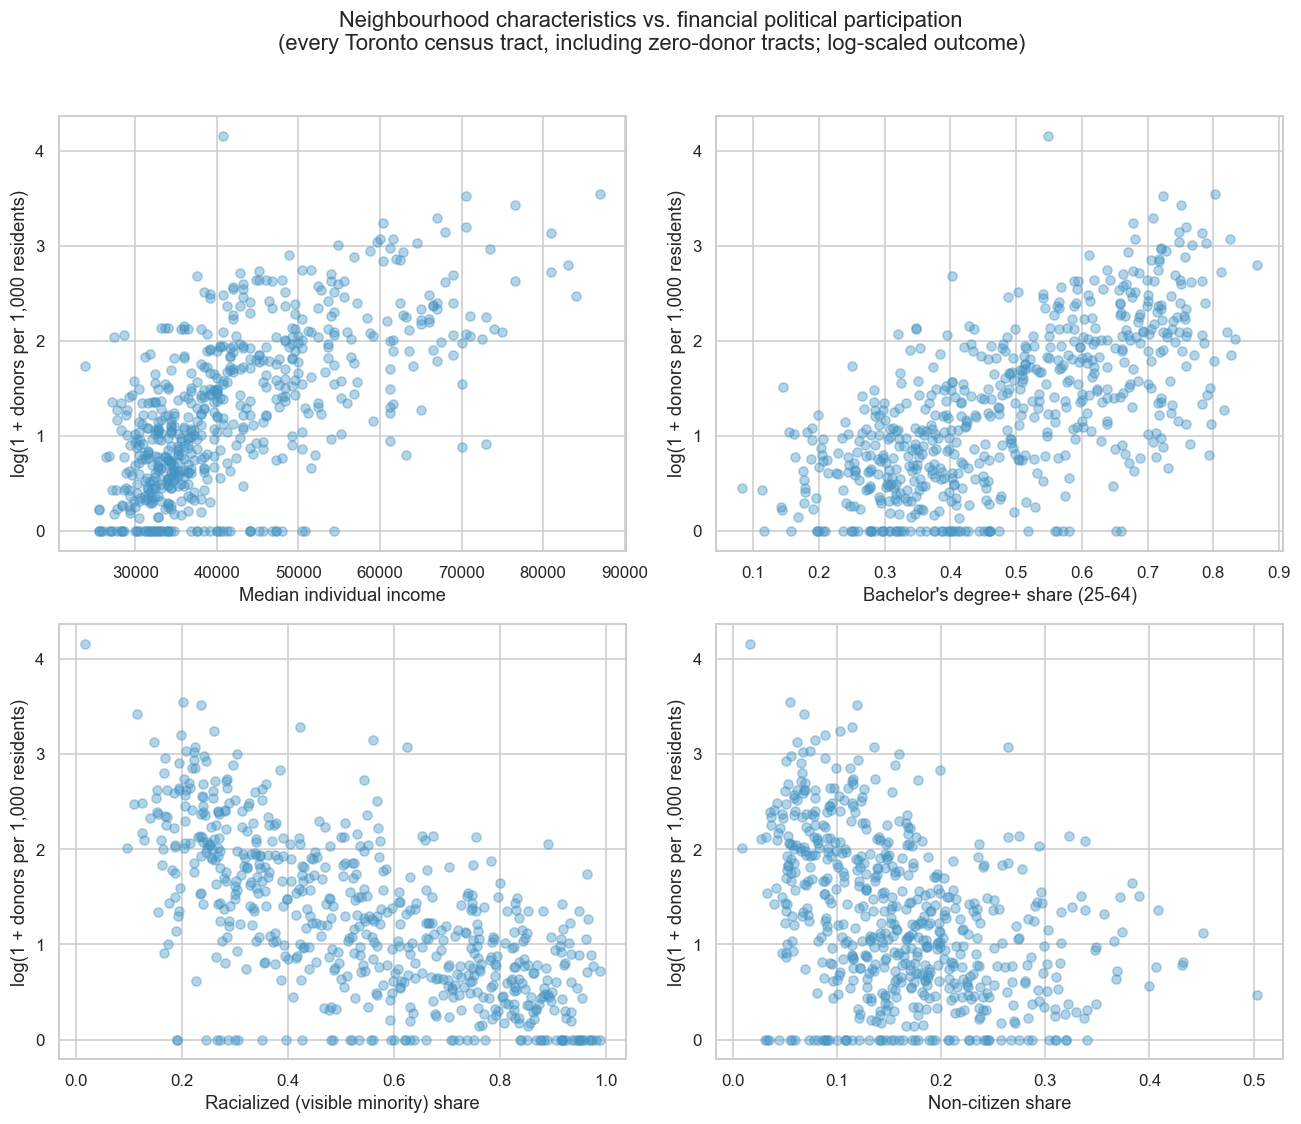

In [29]:
# donors_per_1000 is heavily right-skewed and now includes a large spike of exact zeros -- a
# log1p y-axis keeps a handful of extreme high-participation tracts from compressing everything
# else, while still showing the zero-donor tracts as a visible band at the bottom rather than
# hiding them.
scatter_vars = ["median_individual_income", "bachelors_or_higher_25_64_share", "visible_minority_share", "non_citizen_share"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, var in zip(axes.flat, scatter_vars):
    ax.scatter(ct_demo[var], ct_demo["log_donors_per_1000"], alpha=0.4, color=OTHER_CANDIDATE_COLOR)
    ax.set_xlabel(DEMOGRAPHIC_LABELS[var])
    ax.set_ylabel("log(1 + donors per 1,000 residents)")
fig.suptitle("Neighbourhood characteristics vs. financial political participation\n(every Toronto census tract, including zero-donor tracts; log-scaled outcome)", y=1.02)
plt.tight_layout()
plt.show()

### B. Demographic quintiles

Quintiles are now computed directly on `ct_demo`, since it already covers every Toronto census
tract -- there is no separate "true distribution" to borrow cut points from anymore.

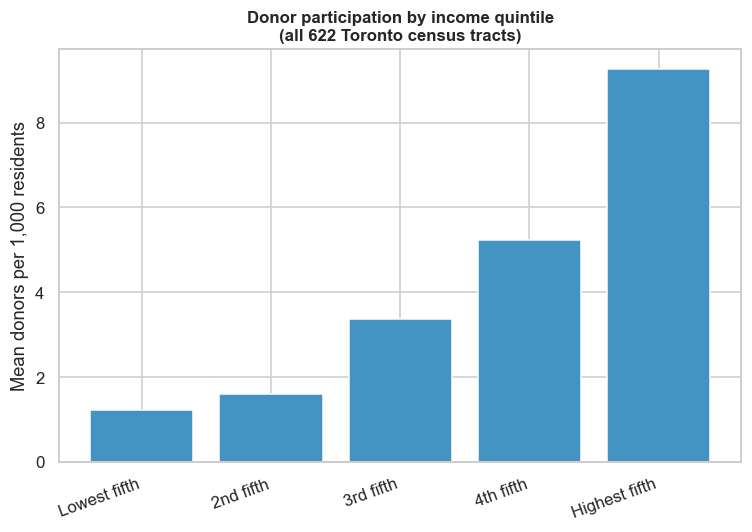

Lowest fifth: 1.23 donors/1,000 -- Highest fifth: 9.26 donors/1,000 (7.6x)


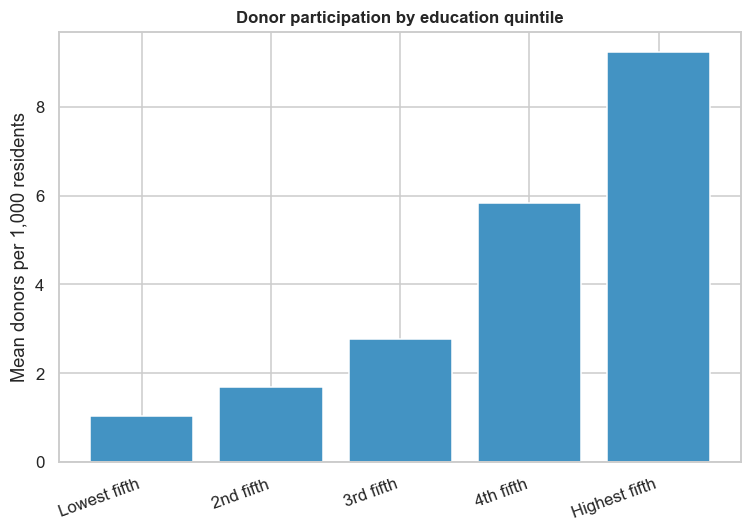

Lowest fifth: 1.03 donors/1,000 -- Highest fifth: 9.23 donors/1,000 (9.0x)


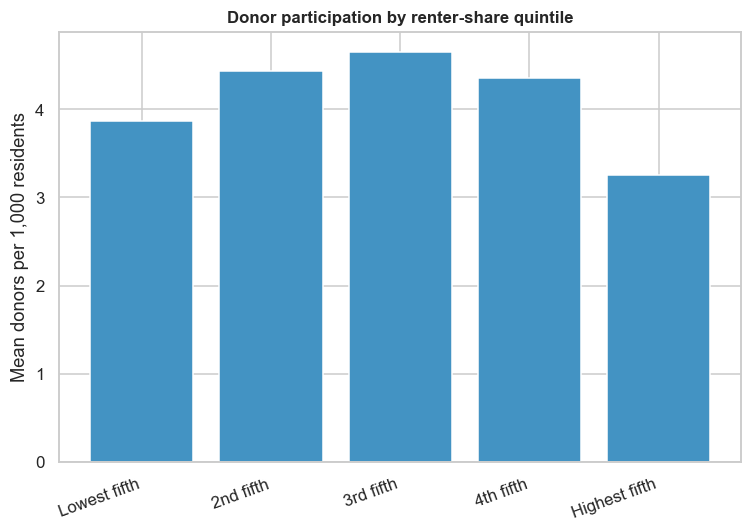

Lowest fifth: 3.87 donors/1,000 -- Highest fifth: 3.25 donors/1,000 (0.8x)


In [30]:
def plot_quintile_participation(var, title):
    ct_demo["_quintile"] = pd.qcut(ct_demo[var], 5, labels=QUINTILE_LABELS, duplicates="drop")
    quintile_means = ct_demo.groupby("_quintile", observed=True)["donors_per_1000"].mean()
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(quintile_means.index.astype(str), quintile_means.values, color=OTHER_CANDIDATE_COLOR)
    ax.set_ylabel("Mean donors per 1,000 residents")
    ax.set_title(title, fontsize=11)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    lo, hi = quintile_means.iloc[0], quintile_means.iloc[-1]
    ratio = f"{hi/lo:.1f}x" if lo > 0 else "undefined (lowest fifth averages exactly zero)"
    print(f"{QUINTILE_LABELS[0]}: {lo:.2f} donors/1,000 -- {QUINTILE_LABELS[-1]}: {hi:.2f} donors/1,000 ({ratio})")


plot_quintile_participation("median_individual_income", "Donor participation by income quintile\n(all 622 Toronto census tracts)")
plot_quintile_participation("bachelors_or_higher_25_64_share", "Donor participation by education quintile")
plot_quintile_participation("renter_share", "Donor participation by renter-share quintile")

### C. Correlations

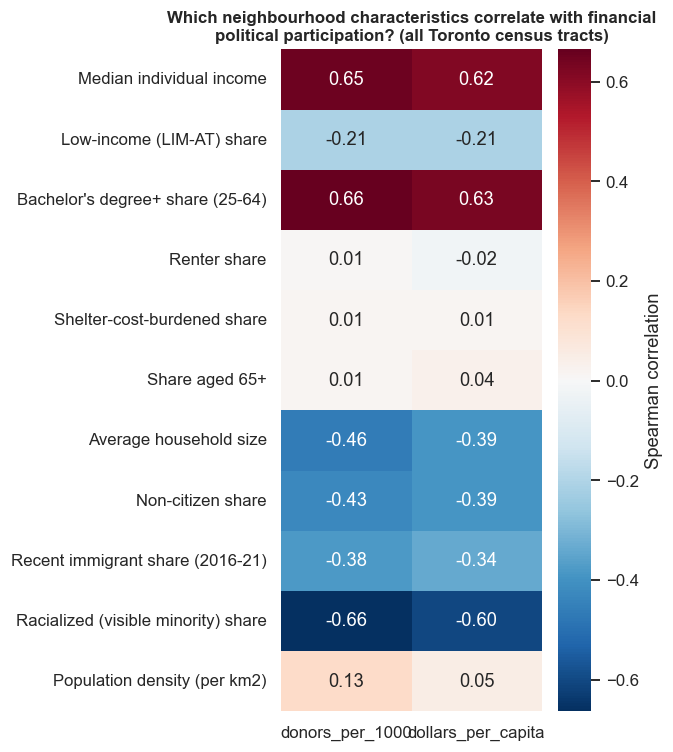

In [31]:
corr_cols = DEMOGRAPHIC_VARS + ["donors_per_1000", "dollars_per_capita"]
corr_matrix = ct_demo[corr_cols].corr(method="spearman")
outcome_corr = corr_matrix.loc[DEMOGRAPHIC_VARS, ["donors_per_1000", "dollars_per_capita"]].rename(index=DEMOGRAPHIC_LABELS)

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(outcome_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Which neighbourhood characteristics correlate with financial\npolitical participation? (all Toronto census tracts)", fontsize=11)
plt.tight_layout()
plt.show()

### D. Multivariate model -- a diagnostic, not the main story

Donor counts are small non-negative integers with an exposure denominator (population) -- a
Poisson model with `log(population)` as an offset fits this better than an OLS regression on
the per-capita *rate*, and now that zero-donor tracts are included, it is also a much more
appropriate model: Poisson naturally handles the large number of genuine zeros that a
log-transformed-rate OLS regression would otherwise have to treat awkwardly.

**Important interpretive note:** several of these neighbourhood characteristics are themselves
highly correlated with each other across Toronto's geography (income, education, and racialized
share all move together). A short sequence of models -- income alone, education alone, both
together, then the full set -- is used purely as a **diagnostic** to show how much these
variables overlap. If a coefficient shrinks once another variable is added, that shows the two
variables are difficult to statistically separate in this data -- it is **not** evidence that
one variable "operates through" the other. That would require an actual mediation analysis,
which is out of scope here and unnecessary for the descriptive story this notebook is telling.

In [32]:
model_df = ct_demo.dropna(subset=DEMOGRAPHIC_VARS + ["n_unique_donors", "population_total"]).copy()

def fit_poisson(vars_in_model):
    X = (model_df[vars_in_model] - model_df[vars_in_model].mean()) / model_df[vars_in_model].std()
    X = sm.add_constant(X)
    return sm.GLM(model_df["n_unique_donors"], X, family=sm.families.Poisson(),
                   offset=np.log(model_df["population_total"])).fit()

model_sequence = {
    "1. Income only": ["median_individual_income"],
    "2. Education only": ["bachelors_or_higher_25_64_share"],
    "3. Income + education": ["median_individual_income", "bachelors_or_higher_25_64_share"],
    "4. Full model": ["median_individual_income", "bachelors_or_higher_25_64_share", "visible_minority_share", "renter_share"],
}
sequence_rows = []
for step_name, vars_in_model in model_sequence.items():
    m = fit_poisson(vars_in_model)
    for v in vars_in_model:
        sequence_rows.append({
            "step": step_name, "variable": DEMOGRAPHIC_LABELS[v],
            "incidence_rate_ratio": np.exp(m.params[v]), "p_value": m.pvalues[v],
        })
sequence_df = pd.DataFrame(sequence_rows)
print(f"Diagnostic model sequence on {len(model_df)} Toronto census tracts (all tracts, zero-donor included)")
sequence_df.round(3)

Diagnostic model sequence on 620 Toronto census tracts (all tracts, zero-donor included)


,step,variable,incidence_rate_ratio,p_value
0,1. Income only,Median individual income,1.81,0.00
1,2. Education only,Bachelor's degree+ share (25-64),2.08,0.00
2,3. Income + education,Median individual income,1.34,0.00
3,3. Income + education,Bachelor's degree+ share (25-64),1.59,0.00
4,4. Full model,Median individual income,0.94,0.00
5,4. Full model,Bachelor's degree+ share (25-64),1.75,0.00
6,4. Full model,Racialized (visible minority) share,0.54,0.00
7,4. Full model,Renter share,1.06,0.00


In [33]:
full_model = fit_poisson(model_sequence["4. Full model"])
irr = np.exp(full_model.params).rename("incidence_rate_ratio")
print(f"Full model (step 4), {len(model_df)} census tracts, donors as outcome, population as exposure offset:")
pd.concat([irr, full_model.pvalues.rename("p_value")], axis=1).round(3)

Full model (step 4), 620 census tracts, donors as outcome, population as exposure offset:


,incidence_rate_ratio,p_value
const,0.00,0.00
median_individual_income,0.94,0.00
bachelors_or_higher_25_64_share,1.75,0.00
visible_minority_share,0.54,0.00
renter_share,1.06,0.00


### Interpretation

A one-standard-deviation increase in a predictor changes the expected donor rate by a factor
of its incidence-rate ratio (IRR), holding the others fixed. The step-by-step sequence above
exists to show *overlap*, not causal structure: if income's IRR is large on its own (step 1) and
shrinks once education is added (step 3), that is because income and education are correlated
neighbourhood characteristics in Toronto, not because one variable causes the other's effect.
The honest conclusion from a shrinking coefficient is **"these characteristics are hard to
statistically tell apart here,"** not **"X operates through Y."**

### Takeaway

**With every Toronto census tract included -- zero-donor tracts and all -- the income and
education gaps are larger than a donor-matched-only analysis would suggest, and renter share
still shows essentially nothing.** Tracts in the highest income fifth produce **9.26 donors
per 1,000 residents versus 1.23 in the lowest fifth (a 7.6x gap)**; the education gap is
larger still at **9.0x (9.23 vs. 1.03)**. Renter share is flat-to-slightly-inverted (0.8x).
The diagnostic model sequence shows exactly why a single regression coefficient is the wrong
number to headline: income alone has an IRR of 1.81 and education alone 2.08, but once both
are in the same model together their IRRs shrink to 1.34 and 1.59 -- they are highly
overlapping neighbourhood characteristics, not independent effects, and that overlap is the
finding, not evidence that one "operates through" the other. In the full model, education
keeps the strongest independent association (IRR 1.75, p<.01); income's is small (IRR 0.94);
visible-minority share shows the strongest independent negative association (IRR 0.54, p<.01);
and renter share is technically statistically significant (IRR 1.06, p<.01) but the effect is
small enough to be practically negligible, consistent with its flat quintile pattern.

### Data-story potential -- Part 8

**Strong, contingent on a clear pattern emerging.** Quintile bar charts in particular translate
directly into a compelling, plain-language sentence ("neighbourhoods in the top income fifth
produce N times as many donors per capita as the bottom fifth") that needs no statistical
literacy to understand. The ecological-inference caveat must travel with any public use of this
finding, and any regression-derived claim should stay descriptive ("these characteristics
overlap heavily") rather than causal.

# Part 9 -- Stability of demographic patterns across elections

### Question

Does the demographic pattern from Part 8 show up in **both** the 2022 council data and the
2023 mayoral data independently, or only in the pooled data (where it could be driven by a
single election or candidate)?

### Method

We recompute Spearman correlations between the two strongest Part 8 variables and donor
participation, separately for 2022-only, 2023-only, and combined data -- each time using
**every Toronto census tract**, with zero-donor tracts included exactly as in Part 8.

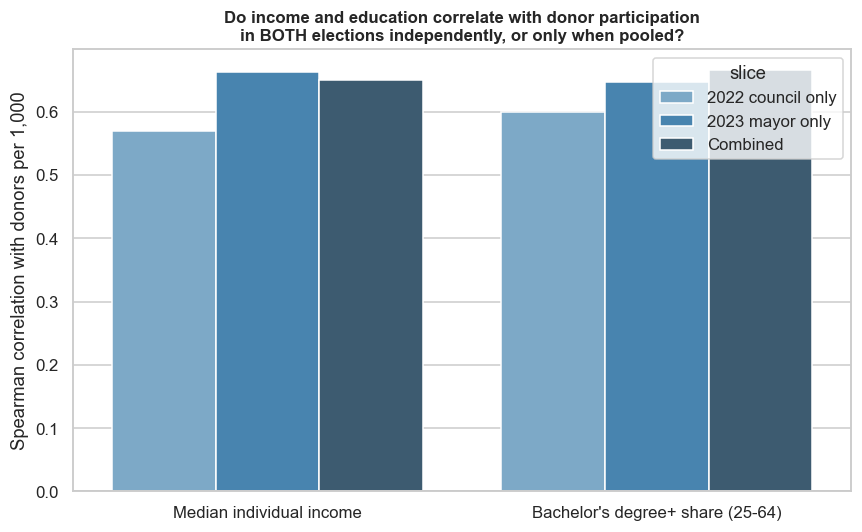

,slice,variable,rho,n
0,2022 council only,Median individual income,0.57,620
1,2022 council only,Bachelor's degree+ share (25-64),0.60,620
2,2023 mayor only,Median individual income,0.66,620
3,2023 mayor only,Bachelor's degree+ share (25-64),0.65,620
4,Combined,Median individual income,0.65,620
5,Combined,Bachelor's degree+ share (25-64),0.66,620


In [34]:
def ct_demo_for(ct_agg):
    return ct_agg.merge(ct_geo[["ctuid_norm"] + DEMOGRAPHIC_VARS], on="ctuid_norm", how="left")


stability_vars = ["median_individual_income", "bachelors_or_higher_25_64_share"]
slices = {"2022 council only": ct_demo_for(council_ct_agg), "2023 mayor only": ct_demo_for(mayor_ct_agg), "Combined": ct_demo}

stability_rows = []
for slice_name, df in slices.items():
    for var in stability_vars:
        valid = df.dropna(subset=[var, "donors_per_1000"])  # a couple of tracts have suppressed census values
        rho, _ = stats.spearmanr(valid[var], valid["donors_per_1000"])
        stability_rows.append({"slice": slice_name, "variable": DEMOGRAPHIC_LABELS[var], "rho": rho, "n": len(valid)})
stability_df = pd.DataFrame(stability_rows)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=stability_df, x="variable", y="rho", hue="slice", ax=ax, palette="Blues_d")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Spearman correlation with donors per 1,000")
ax.set_xlabel("")
ax.set_title("Do income and education correlate with donor participation\nin BOTH elections independently, or only when pooled?", fontsize=11)
plt.tight_layout()
plt.show()
stability_df

### Interpretation

If the 2022-only and 2023-only bars point the same direction and are of similar magnitude to
the combined bar, the demographic pattern is not an artifact of one election's candidate
roster -- a materially more convincing basis for a public claim about "who finances Toronto
politics" in general, rather than "who gave to these particular candidates."

### Takeaway

**The pattern replicates independently in both elections, across all 620 usable census
tracts.** Income correlates with donors-per-1,000 at rho=0.57 in 2022-council-only data and
rho=0.66 in 2023-mayor-only data; education shows an almost identical pattern (0.60 and 0.65).
The combined-data correlations (0.65 and 0.66) sit close to both individual elections, not
just one of them -- this is a consistent citywide relationship, not an artifact of either
election's particular candidate roster.

### Data-story potential -- Part 9

**A strength-multiplier for Part 8, not a standalone story.** Its entire value is in whether it
confirms or undercuts Part 8's headline demographic claim -- report it as supporting evidence,
not as its own section of a public write-up.

# Part 10 -- Candidate donor-neighbourhood demographic profiles

### Question

What kind of neighbourhood does a *typical donor* to a given candidate come from -- shown in
actual, substantive terms (a real income figure, a real percentage), not an abstract
standardized score? And does that differ from what kind of neighbourhood the candidate's
*dollars* come from?

### Method: weighting schemes and display

1. **Population-weighted Toronto baseline** -- the demographic environment of the average
   Toronto resident, weighting each census tract by its population.
2. **Unique-donor-weighted candidate profile** (**primary**) -- deduplicate to one row per
   donor-candidate pair; every donor counts equally. Answers: *what kind of neighbourhood does
   the typical donor come from?*
3. **Dollar-weighted candidate profile** (secondary/sensitivity) -- weight by contribution
   amount. Answers a different question: *what kind of neighbourhood do the campaign's actual
   dollars come from?* Kept as a secondary check, not the main visual.

Every chart below shows **actual demographic values** -- percentages for proportion variables,
dollars for income, residents-per-km2 for density -- plotted together across candidates on a
shared set of rows, rather than one small chart per candidate.

In [35]:
def weighted_mean(df, value_cols, weight_col):
    w = df[weight_col]
    return pd.Series({c: np.average(df[c], weights=w) for c in value_cols})


ct_geo_valid = ct_geo.dropna(subset=DEMOGRAPHIC_VARS + ["population_total"])
toronto_baseline_mean = weighted_mean(ct_geo_valid, DEMOGRAPHIC_VARS, "population_total")

print("Population-weighted Toronto baseline (the average Toronto resident's neighbourhood):")
toronto_baseline_mean.rename(DEMOGRAPHIC_LABELS).round(2)

Population-weighted Toronto baseline (the average Toronto resident's neighbourhood):


Median individual income              41,674.94
Low-income (LIM-AT) share                  0.13
Bachelor's degree+ share (25-64)           0.48
Renter share                               0.44
Shelter-cost-burdened share                0.31
Share aged 65+                             0.17
Average household size                     2.52
Non-citizen share                          0.17
Recent immigrant share (2016-21)           0.07
Racialized (visible minority) share        0.56
Population density (per km2)           9,120.31
dtype: float64

In [36]:
def candidate_donor_weighted_profile(df, candidate_col, candidate_value):
    """Unique-donor-weighted: one row per donor, each counted once regardless of $ or # of gifts."""
    sub = df.loc[(df[candidate_col] == candidate_value) & (~df["is_self_funded"]) & df["is_toronto_postal"] & df["ctuid"].notna()]
    sub = sub.drop_duplicates("donor_id").merge(ct_geo[["ctuid_norm"] + DEMOGRAPHIC_VARS], left_on="ctuid", right_on="ctuid_norm", how="left")
    sub = sub.dropna(subset=DEMOGRAPHIC_VARS)
    if len(sub) == 0:
        return None, 0
    return sub[DEMOGRAPHIC_VARS].mean(), len(sub)


def candidate_dollar_weighted_profile(df, candidate_col, candidate_value):
    """Dollar-weighted: each row weighted by contribution amount (a $1,200 gift counts 12x a $100 gift)."""
    sub = df.loc[(df[candidate_col] == candidate_value) & (~df["is_self_funded"]) & df["is_toronto_postal"] & df["ctuid"].notna()]
    sub = sub.merge(ct_geo[["ctuid_norm"] + DEMOGRAPHIC_VARS], left_on="ctuid", right_on="ctuid_norm", how="left")
    sub = sub.dropna(subset=DEMOGRAPHIC_VARS)
    if len(sub) == 0 or sub["amount"].sum() == 0:
        return None, 0
    return weighted_mean(sub, DEMOGRAPHIC_VARS, "amount"), sub["donor_id"].nunique()


def make_entry(label, values, color, marker="o", size=110, alpha=0.9):
    return {"label": label, "values": values, "color": color, "marker": marker, "size": size, "alpha": alpha}


baseline_entry = make_entry("Toronto baseline (population-weighted)", toronto_baseline_mean, BASELINE_COLOR, marker=BASELINE_MARKER, size=170, alpha=1.0)


def plot_proportion_profile(entries, title, subtitle=None):
    """One row per proportion variable; every entry gets a dot on every row -- the core
    'multiple candidates on shared rows' comparison this notebook now uses throughout."""
    vars_list = DEMOGRAPHIC_PROPORTION_VARS
    y = np.arange(len(vars_list))
    fig, ax = plt.subplots(figsize=(11, max(4.5, 0.55 * len(vars_list))))
    for e in entries:
        xs = [e["values"][v] for v in vars_list]
        ax.scatter(xs, y, color=e["color"], marker=e["marker"], s=e["size"], alpha=e["alpha"],
                   label=e["label"], zorder=3, edgecolor="white", linewidth=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels([DEMOGRAPHIC_LABELS[v] for v in vars_list])
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlim(left=0)
    ax.set_xlabel("Share of neighbourhood population")
    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=11)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()


def plot_scalar_comparison(entries, var, title, xlabel, fmt="num"):
    """One row per entity (candidate/baseline) for a single non-proportion variable."""
    rows = sorted(entries, key=lambda e: e["values"][var])
    y = np.arange(len(rows))
    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(rows))))
    for yi, e in zip(y, rows):
        ax.scatter(e["values"][var], yi, color=e["color"], marker=e["marker"], s=150,
                   edgecolor="white", linewidth=0.8, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([e["label"] for e in rows])
    fmt_funcs = {"dollar": lambda x, _: f"${x:,.0f}", "decimal": lambda x, _: f"{x:,.2f}"}
    fmt_func = fmt_funcs.get(fmt, lambda x, _: f"{x:,.0f}")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_func))
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_weighting_sensitivity(candidates, colors_map, source_df, var, title, xlabel, fmt="dollar"):
    """Secondary/sensitivity check: donor-weighted (primary, circle) vs. dollar-weighted
    (secondary, triangle) value of one variable, per candidate."""
    rows = []
    for cand in candidates:
        donor_profile, n_d = candidate_donor_weighted_profile(source_df, "candidate_raw", cand)
        dollar_profile, _ = candidate_dollar_weighted_profile(source_df, "candidate_raw", cand)
        if donor_profile is None or dollar_profile is None or n_d < MIN_DONORS_FOR_DEMOGRAPHIC_PROFILE:
            continue
        rows.append((cand, donor_profile[var], dollar_profile[var]))
    rows.sort(key=lambda r: r[1])
    labels = [r[0] for r in rows]
    donor_vals = [r[1] for r in rows]
    dollar_vals = [r[2] for r in rows]
    gaps = pd.Series({l: d - o for l, o, d in zip(labels, donor_vals, dollar_vals)}).sort_values()
    print(f"Dollar-weighted minus donor-weighted gap, {var}:\n{gaps.round(0) if fmt == 'dollar' else (gaps * 100).round(1)}")
    y = np.arange(len(rows))
    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(rows))))
    ax.hlines(y, donor_vals, dollar_vals, color=NEUTRAL_GRAY, alpha=0.6, zorder=1)
    ax.scatter(donor_vals, y, color=[colors_map[l] for l in labels], marker="o", s=120,
               label="Unique-donor-weighted (primary)", zorder=3, edgecolor="white", linewidth=0.6)
    ax.scatter(dollar_vals, y, color=[colors_map[l] for l in labels], marker="^", s=100, alpha=0.55,
               label="Dollar-weighted (secondary/sensitivity)", zorder=3, edgecolor="white", linewidth=0.6)
    ax.set_yticks(y); ax.set_yticklabels(labels)
    fmt_func = (lambda x, _: f"${x:,.0f}") if fmt == "dollar" else (lambda x, _: f"{x:.0%}")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_func))
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

## Major 2023 mayoral candidates: donor-neighbourhood comparison

One combined chart for all major candidates, rather than eight separate small multiples.

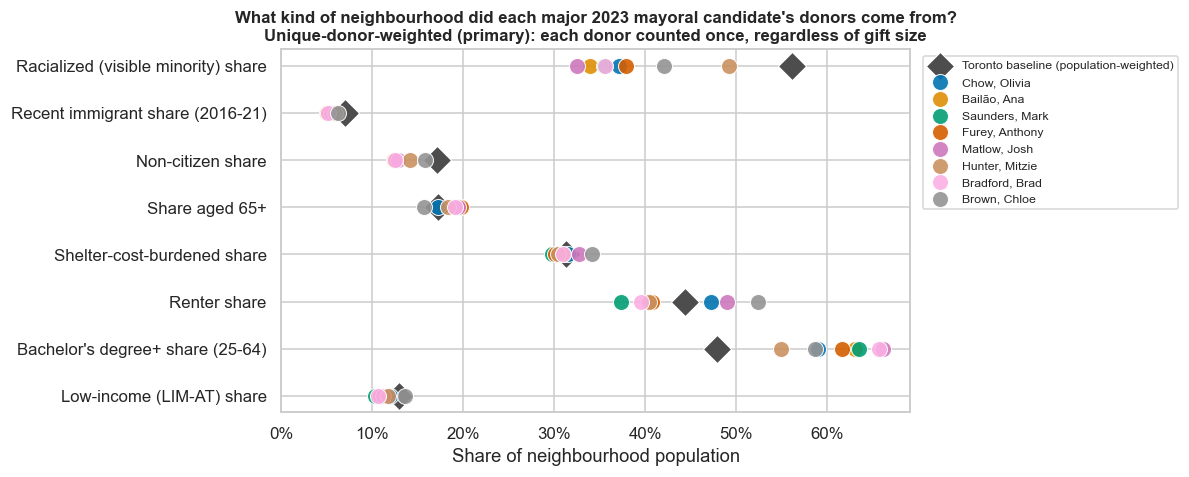

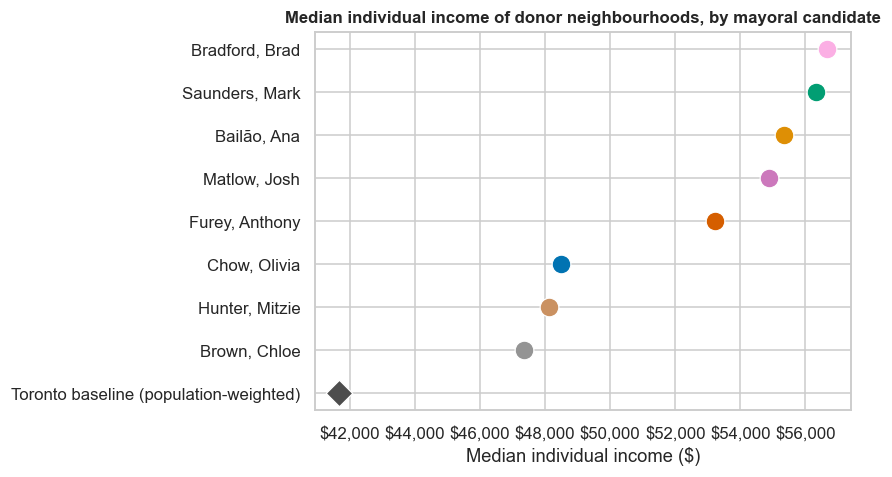

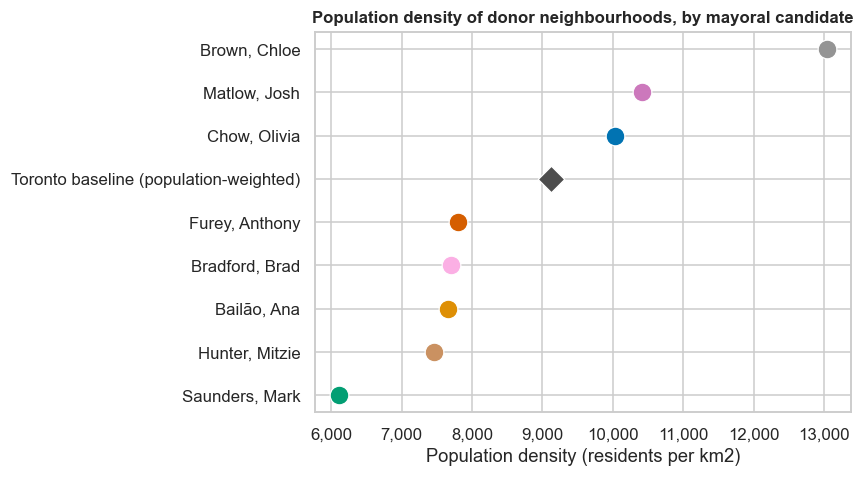

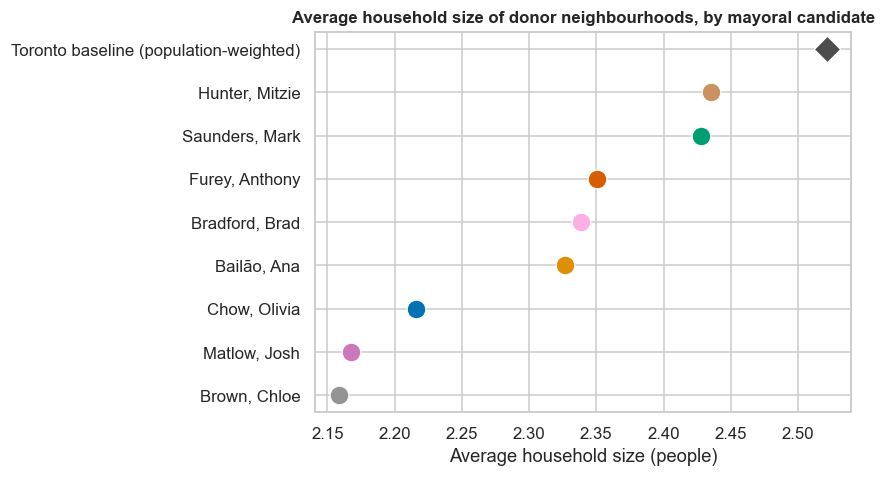

Key values, unique-donor-weighted (also see the two charts above for income and density):


,median_individual_income,bachelors_or_higher_25_64_share,visible_minority_share,renter_share
Toronto baseline (population-weighted),"41,674.94",0.48,0.56,0.44
"Chow, Olivia","48,502.50",0.59,0.37,0.47
"Bailão, Ana","55,331.68",0.63,0.34,0.41
"Saunders, Mark","56,322.31",0.64,0.35,0.37
"Furey, Anthony","53,211.97",0.62,0.38,0.41
"Matlow, Josh","54,890.85",0.66,0.33,0.49
"Hunter, Mitzie","48,116.14",0.55,0.49,0.40
"Bradford, Brad","56,663.03",0.66,0.36,0.40
"Brown, Chloe","47,363.75",0.59,0.42,0.52


In [37]:
mayor_profile_entries = []
mayor_profile_support = []
for cand in MAJOR_2023_CANDIDATES:
    donor_profile, n = candidate_donor_weighted_profile(mayor_2023, "candidate_raw", cand)
    mayor_profile_support.append({"candidate_raw": cand, "n_geocoded_donors": n})
    if donor_profile is not None and n >= MIN_DONORS_FOR_DEMOGRAPHIC_PROFILE:
        mayor_profile_entries.append(make_entry(cand, donor_profile, MAYORAL_CANDIDATE_COLORS[cand]))

plot_proportion_profile(
    [baseline_entry] + mayor_profile_entries,
    "What kind of neighbourhood did each major 2023 mayoral candidate's donors come from?",
    subtitle="Unique-donor-weighted (primary): each donor counted once, regardless of gift size",
)
plot_scalar_comparison(
    [baseline_entry] + mayor_profile_entries, "median_individual_income",
    "Median individual income of donor neighbourhoods, by mayoral candidate",
    "Median individual income ($)", fmt="dollar",
)
plot_scalar_comparison(
    [baseline_entry] + mayor_profile_entries, "population_density_per_km2",
    "Population density of donor neighbourhoods, by mayoral candidate",
    "Population density (residents per km2)", fmt="num",
)
plot_scalar_comparison(
    [baseline_entry] + mayor_profile_entries, "average_household_size",
    "Average household size of donor neighbourhoods, by mayoral candidate",
    "Average household size (people)", fmt="decimal",
)
summary_vars = ["median_individual_income", "bachelors_or_higher_25_64_share", "visible_minority_share", "renter_share"]
mayor_summary = pd.DataFrame({e["label"]: e["values"][summary_vars] for e in [baseline_entry] + mayor_profile_entries}).T
print("Key values, unique-donor-weighted (also see the two charts above for income and density):")
mayor_summary.round(3)

### Secondary check: does dollar-weighting tell a different story?

Dollar-weighted minus donor-weighted gap, median_individual_income:
Bradford, Brad       0.00
Bailão, Ana        187.00
Matlow, Josh       316.00
Saunders, Mark     699.00
Chow, Olivia     1,199.00
Brown, Chloe     1,529.00
Hunter, Mitzie   2,208.00
Furey, Anthony   2,869.00
dtype: float64


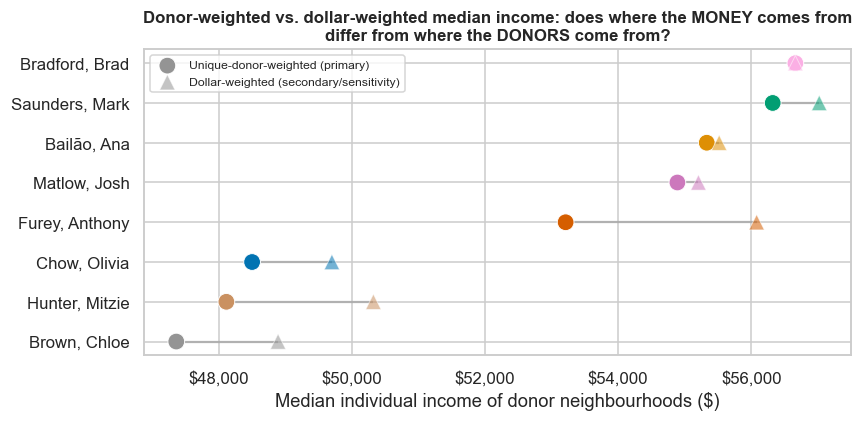

In [38]:
plot_weighting_sensitivity(
    MAJOR_2023_CANDIDATES, MAYORAL_CANDIDATE_COLORS, mayor_2023, "median_individual_income",
    "Donor-weighted vs. dollar-weighted median income: does where the MONEY comes from\ndiffer from where the DONORS come from?",
    "Median individual income of donor neighbourhoods ($)", fmt="dollar",
)

## 2026 repeat council candidates: donor-neighbourhood comparison

The analogous comparison for 2022 council candidates confirmed running for office again in
2026 (`REPEAT_COUNCIL_CANDIDATES_2026`), using their 2022 donor base.

11/12 2026 repeat council candidates have >= 20 geocoded donors and appear in the charts below; all candidates and their donor counts are in the supporting table.


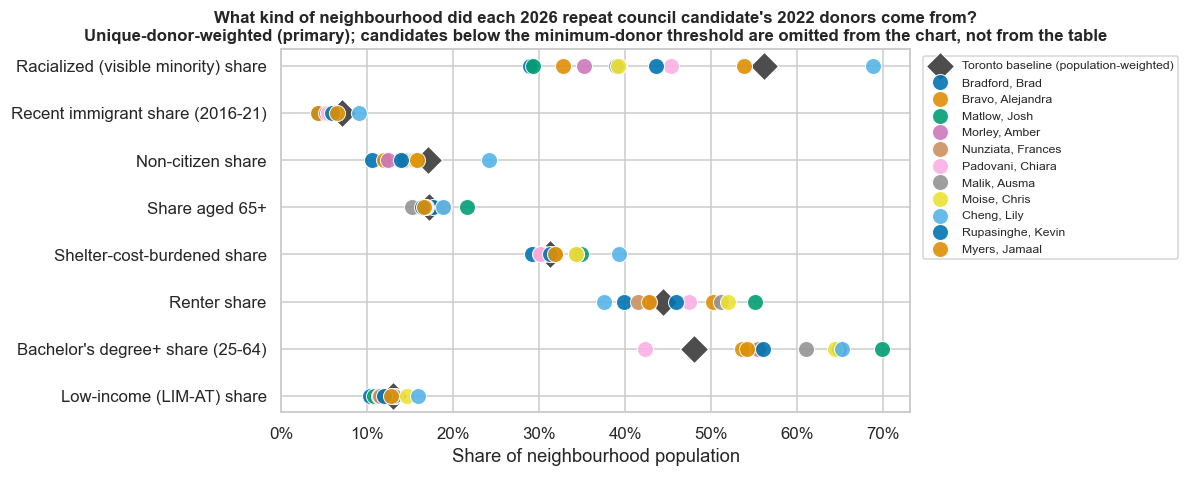

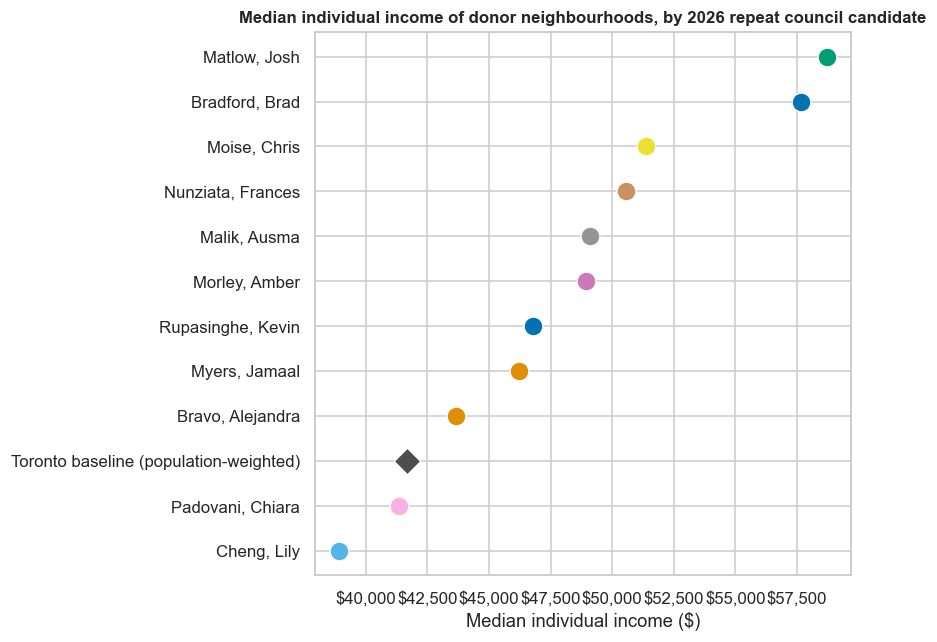

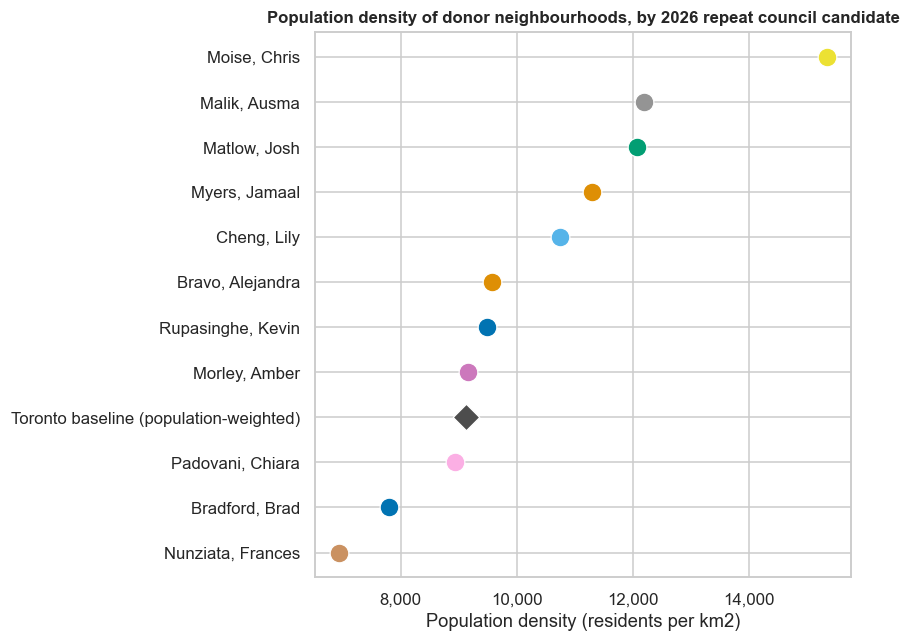

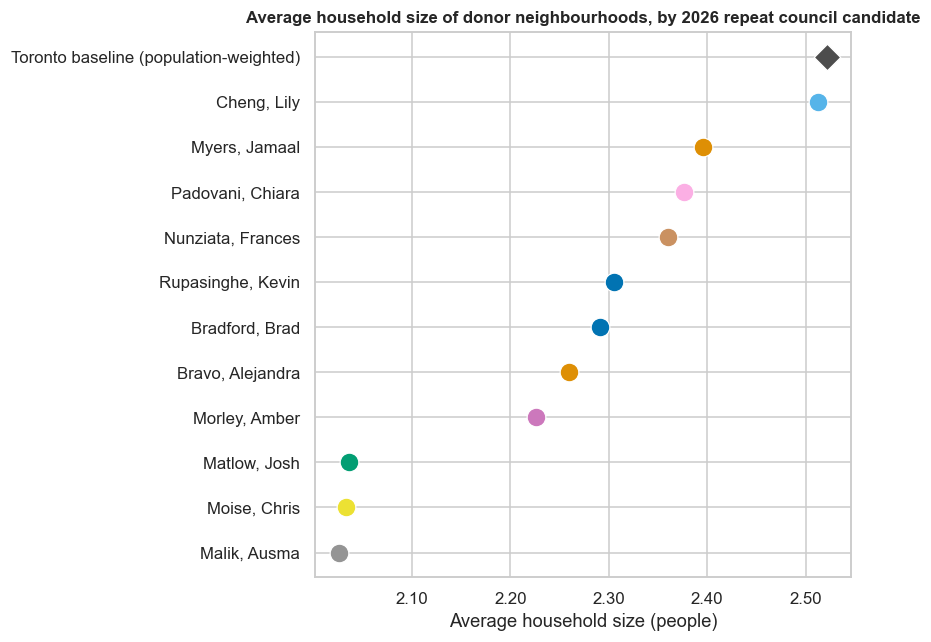

    candidate_raw  n_geocoded_donors  included_in_chart
     Malik, Ausma                226               True
 Bravo, Alejandra                224               True
    Morley, Amber                205               True
     Matlow, Josh                205               True
Rupasinghe, Kevin                178               True
 Padovani, Chiara                176               True
      Cheng, Lily                139               True
   Bradford, Brad                133               True
     Moise, Chris                119               True
    Myers, Jamaal                 75               True
Nunziata, Frances                 72               True
 Holyday, Stephen                  5              False

Key values, unique-donor-weighted:


,median_individual_income,bachelors_or_higher_25_64_share,visible_minority_share,renter_share
Toronto baseline (population-weighted),"41,674.94",0.48,0.56,0.44
"Bradford, Brad","57,657.14",0.65,0.29,0.40
"Bravo, Alejandra","43,666.96",0.54,0.33,0.50
"Matlow, Josh","58,721.95",0.70,0.29,0.55
"Morley, Amber","48,920.49",0.55,0.35,0.43
"Nunziata, Frances","50,572.22",0.55,0.39,0.41
"Padovani, Chiara","41,334.09",0.42,0.45,0.47
"Malik, Ausma","49,115.93",0.61,0.39,0.51
"Moise, Chris","51,380.67",0.64,0.39,0.52
"Cheng, Lily","38,917.99",0.65,0.69,0.38


In [39]:
council_profile_entries = []
council_profile_support = []
for cand in REPEAT_COUNCIL_CANDIDATES_2026:
    donor_profile, n = candidate_donor_weighted_profile(council_2022, "candidate_raw", cand)
    council_profile_support.append({"candidate_raw": cand, "n_geocoded_donors": n,
                                     "included_in_chart": bool(donor_profile is not None and n >= MIN_DONORS_FOR_DEMOGRAPHIC_PROFILE)})
    if donor_profile is not None and n >= MIN_DONORS_FOR_DEMOGRAPHIC_PROFILE:
        council_profile_entries.append(make_entry(cand, donor_profile, COUNCIL_REPEAT_CANDIDATE_COLORS[cand]))

print(f"{len(council_profile_entries)}/{len(REPEAT_COUNCIL_CANDIDATES_2026)} 2026 repeat council candidates have "
      f">= {MIN_DONORS_FOR_DEMOGRAPHIC_PROFILE} geocoded donors and appear in the charts below; "
      f"all candidates and their donor counts are in the supporting table.")

plot_proportion_profile(
    [baseline_entry] + council_profile_entries,
    "What kind of neighbourhood did each 2026 repeat council candidate's 2022 donors come from?",
    subtitle="Unique-donor-weighted (primary); candidates below the minimum-donor threshold are omitted from the chart, not from the table",
)
plot_scalar_comparison(
    [baseline_entry] + council_profile_entries, "median_individual_income",
    "Median individual income of donor neighbourhoods, by 2026 repeat council candidate",
    "Median individual income ($)", fmt="dollar",
)
plot_scalar_comparison(
    [baseline_entry] + council_profile_entries, "population_density_per_km2",
    "Population density of donor neighbourhoods, by 2026 repeat council candidate",
    "Population density (residents per km2)", fmt="num",
)
plot_scalar_comparison(
    [baseline_entry] + council_profile_entries, "average_household_size",
    "Average household size of donor neighbourhoods, by 2026 repeat council candidate",
    "Average household size (people)", fmt="decimal",
)
print(pd.DataFrame(council_profile_support).sort_values("n_geocoded_donors", ascending=False).to_string(index=False))
council_summary = pd.DataFrame({e["label"]: e["values"][summary_vars] for e in [baseline_entry] + council_profile_entries}).T
print("\nKey values, unique-donor-weighted:")
council_summary.round(3)

### Secondary check: does dollar-weighting tell a different story?

Dollar-weighted minus donor-weighted gap, median_individual_income:
Morley, Amber        -881.00
Rupasinghe, Kevin    -208.00
Matlow, Josh          -30.00
Bravo, Alejandra       65.00
Nunziata, Frances     235.00
Myers, Jamaal         319.00
Padovani, Chiara      337.00
Malik, Ausma          480.00
Cheng, Lily           688.00
Bradford, Brad        714.00
Moise, Chris        1,243.00
dtype: float64


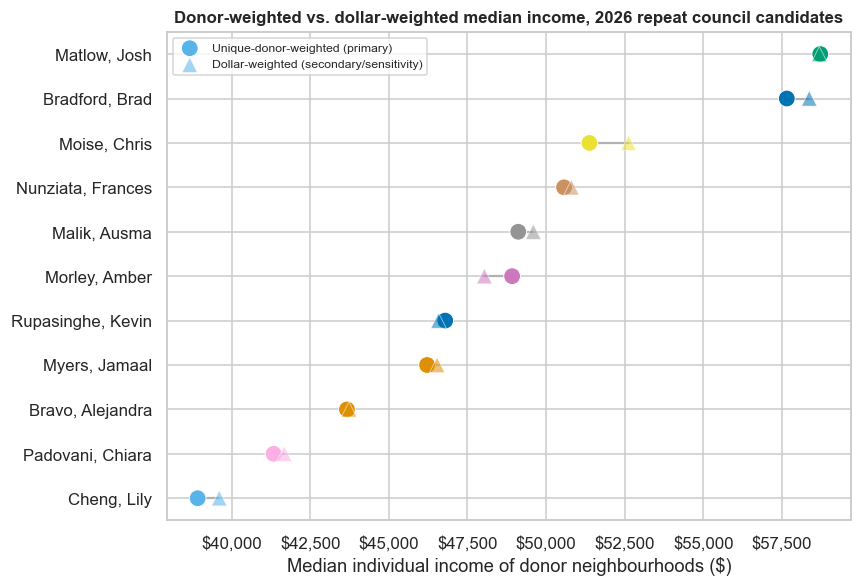

In [40]:
plot_weighting_sensitivity(
    [c for c in REPEAT_COUNCIL_CANDIDATES_2026], COUNCIL_REPEAT_CANDIDATE_COLORS, council_2022, "median_individual_income",
    "Donor-weighted vs. dollar-weighted median income, 2026 repeat council candidates",
    "Median individual income of donor neighbourhoods ($)", fmt="dollar",
)

## Olivia Chow: donor-neighbourhood profile in actual values

The same comparison, focused on Chow specifically, with her dollar-weighted profile shown as a
secondary/lighter reference point rather than an equal second headline.

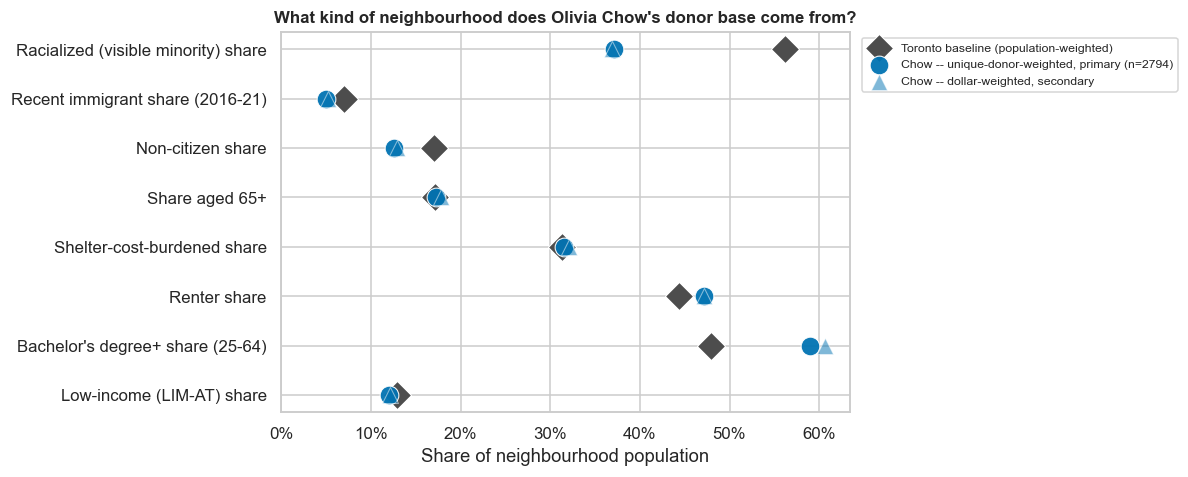

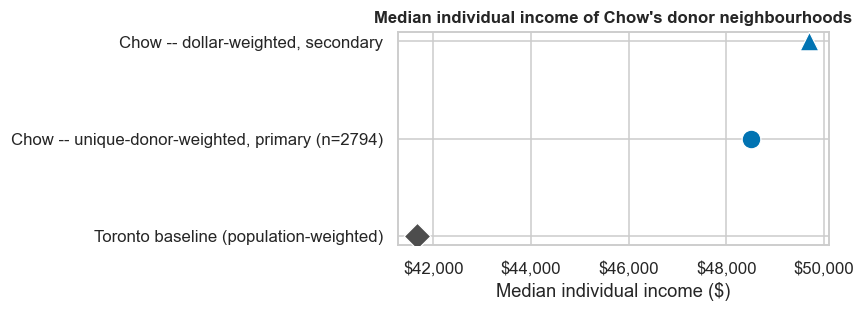

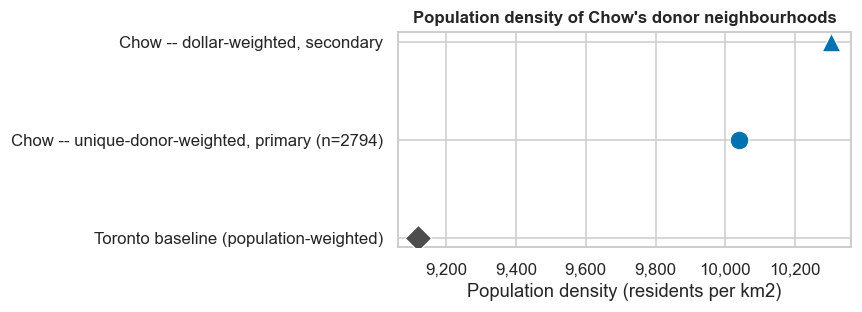

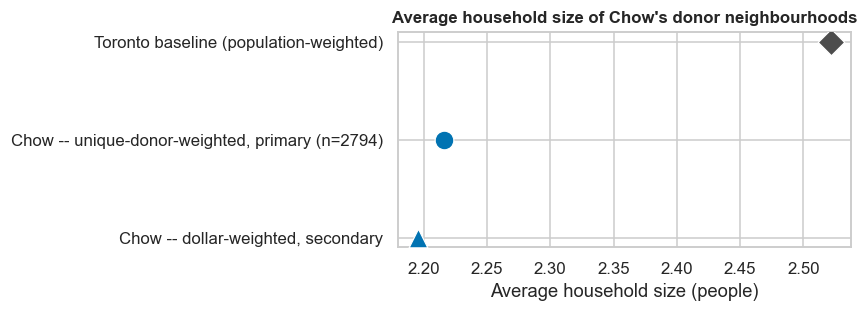

In [41]:
chow_donor_profile, chow_n = candidate_donor_weighted_profile(mayor_2023, "candidate_raw", "Chow, Olivia")
chow_dollar_profile, _ = candidate_dollar_weighted_profile(mayor_2023, "candidate_raw", "Chow, Olivia")

chow_entries = [
    baseline_entry,
    make_entry(f"Chow -- unique-donor-weighted, primary (n={chow_n})", chow_donor_profile,
               MAYORAL_CANDIDATE_COLORS["Chow, Olivia"], marker="o", size=150, alpha=0.95),
    make_entry("Chow -- dollar-weighted, secondary", chow_dollar_profile,
               MAYORAL_CANDIDATE_COLORS["Chow, Olivia"], marker="^", size=110, alpha=0.5),
]
plot_proportion_profile(chow_entries, "What kind of neighbourhood does Olivia Chow's donor base come from?")
plot_scalar_comparison(chow_entries, "median_individual_income",
                        "Median individual income of Chow's donor neighbourhoods", "Median individual income ($)", fmt="dollar")
plot_scalar_comparison(chow_entries, "population_density_per_km2",
                        "Population density of Chow's donor neighbourhoods", "Population density (residents per km2)", fmt="num")
plot_scalar_comparison(chow_entries, "average_household_size",
                        "Average household size of Chow's donor neighbourhoods", "Average household size (people)", fmt="decimal")

### Interpretation

Every chart above now shows a substantive value directly -- a real income figure, a real
percentage -- so no translation from standard deviations is required to read them. The
baseline diamond marks the average Toronto resident's neighbourhood on every row; a
candidate's dot sitting to the right of it on, say, "bachelor's degree+ share" means that
candidate's typical donor lives in a more-educated-than-average neighbourhood, in plain terms.
The secondary dollar-weighted checks answer a related but distinct question: whether a
candidate's *money*, not just their *donors*, is concentrated in a different kind of
neighbourhood.

### Takeaway

**Every major mayoral candidate's donor base skews more affluent, more educated, and less
racialized than the average Toronto resident -- Chow included, though less so than most of her
rivals.** All eight majors' donors show higher median income and education than the
population-weighted baseline ($41,675 / 48% bachelor's-or-higher) and lower visible-minority
share (56% baseline) -- there is no major candidate whose donor base looks demographically
like Toronto overall. Within that shared pattern, Chow's donor-neighbourhood income ($48,503)
sits toward the lower end among majors -- above only Brown ($47,364) and Hunter ($48,116), and
well below Bradford ($56,663), Saunders ($56,322), Bailão ($55,332), and Matlow ($54,891).

**The donor-weighted vs. dollar-weighted sensitivity check reveals real differences in how
"top-heavy" each campaign's fundraising is.** Bradford shows essentially **zero gap** ($0)
between his typical donor's neighbourhood income and his dollar-weighted average -- his money
and his donor base draw from equivalently-valued neighbourhoods. Furey (+$2,869) and Hunter
(+$2,208) show the largest gaps: their actual dollars come from meaningfully wealthier
neighbourhoods than their broader donor base would suggest, meaning a relatively small number
of large gifts from richer areas are doing more work for these campaigns than their donor
count alone implies. Chow's gap (+$1,199) is modest and mid-pack.

**Among the 2026 repeat council candidates, two clearly stand apart from the rest: Padovani
and Cheng.** Every other profiled repeat candidate shows above-baseline income and education,
but Padovani's donor-neighbourhood income ($41,334) sits almost exactly at the Toronto
baseline and her education share (42%) is *below* baseline (48%) -- a donor base that looks
like the general Toronto population rather than skewing affluent. Cheng's income ($38,918) is
below baseline too, and her donor base's **visible-minority share (69%) is the only one among
all majors and repeats that exceeds the Toronto baseline (56%)** -- every other candidate's
donor base is less racialized than the city as a whole; Cheng's is the sole exception, and the
chart itself establishes this, not a subjective read. Bradford and Matlow, by contrast, post
the lowest visible-minority shares among the repeats (29% each) alongside their highest-income
donor bases. The sensitivity check adds one more genuinely surprising result: Morley is the
only candidate across either group with a **negative** dollar-weighted gap (-$881) -- her
larger gifts come from slightly *less* affluent neighbourhoods than her typical donor, the
reverse of the more common pattern.

### Data-story potential -- Part 10

**Strong.** A single combined chart per group, in real units, is both more rigorous (no
standardized-score translation needed) and more visual than either a wall of small multiples
or a table -- directly serving the notebook's goal of comparing donor-neighbourhood
demographics across the major mayoral candidates and the 2026 repeat council candidates at a
glance.

# Part 11 -- Cross-election donor overlap: where did Olivia Chow's coalition come from?

This is the deepest section of the notebook, and the engine of Story B. The 2022 council
election and the 2023 mayoral by-election happened about a year apart, and we have named
contributors and postal codes for both -- an unusual opportunity to trace **municipal donor
networks** across elections, with particular attention to Olivia Chow, who is running for
mayor again in 2026.

## 11.1 A rigorous donor identity system

### Method

We deduplicate every contribution record to **person x candidate x election** (someone who
gave to the same candidate three times still counts as one donor relationship), then define
two matching tiers:

- **Tier A (headline, conservative):** exact normalized full name + exact normalized 6-character
  postal code. This is the `donor_id` already used throughout the notebook.
- **Tier B (sensitivity check only):** exact normalized full name, but a different postal code,
  *and* the name is distinctive enough (appears with at most
  `NAME_DISTINCTIVENESS_MAX_POSTALS` distinct postal codes and at most
  `NAME_DISTINCTIVENESS_MAX_ROWS` total rows across both elections combined) that a false match
  is unlikely -- e.g. someone who moved, or whose postal code was mistyped once.
- **Tier C (fuzzy spelling matches):** explicitly out of scope for this pass, per the
  conservative-matching principle -- fuzzy name matching is easy to get subtly wrong and would
  make every downstream number harder to trust.

All headline findings below use **Tier A only**. Tier A+B is used only as a sensitivity check,
to see whether conclusions change materially -- they should not be the basis of a public claim
on their own.

In [42]:
all_contrib_names = pd.concat([
    council_2022[["contributor_norm", "postal_code"]], mayor_2023[["contributor_norm", "postal_code"]],
], ignore_index=True).dropna(subset=["contributor_norm"])

name_stats = all_contrib_names.groupby("contributor_norm").agg(
    n_rows=("postal_code", "size"), n_distinct_postals=("postal_code", "nunique")
)
distinctive_names = set(name_stats.loc[
    (name_stats["n_distinct_postals"] <= NAME_DISTINCTIVENESS_MAX_POSTALS) &
    (name_stats["n_rows"] <= NAME_DISTINCTIVENESS_MAX_ROWS)
].index)
print(f"{len(distinctive_names):,}/{len(name_stats):,} distinct normalized names ({len(distinctive_names)/len(name_stats):.0%}) "
      f"qualify as 'distinctive enough' for Tier-B matching")

12,709/13,153 distinct normalized names (97%) qualify as 'distinctive enough' for Tier-B matching


## 11.2 How much donor continuity exists between 2022 and 2023?

In [43]:
council_donor_ids = set(council_2022.loc[~council_2022["is_self_funded"], "donor_id"])
mayor_donor_ids = set(mayor_2023.loc[~mayor_2023["is_self_funded"], "donor_id"])
overlap_donor_ids_tier_a = council_donor_ids & mayor_donor_ids

print("--- Tier A (conservative, headline) ---")
print(f"2022 council donors: {len(council_donor_ids):,}")
print(f"2023 mayor donors:   {len(mayor_donor_ids):,}")
print(f"Donors appearing in both: {len(overlap_donor_ids_tier_a):,} "
      f"({len(overlap_donor_ids_tier_a)/len(council_donor_ids):.0%} of council donors, "
      f"{len(overlap_donor_ids_tier_a)/len(mayor_donor_ids):.0%} of mayoral donors)")

# Tier A+B sensitivity check. Tier B must be GENUINELY additional: a name that already has a
# Tier-A match (same name AND same postal code in both elections) is excluded here, even if
# that name also happens to be "distinctive" -- otherwise Tier B would double-count people
# Tier A already found, rather than adding people Tier A missed because their postal code
# differed between elections.
council_names = set(council_2022.loc[~council_2022["is_self_funded"], "contributor_norm"])
mayor_names = set(mayor_2023.loc[~mayor_2023["is_self_funded"], "contributor_norm"])
tier_a_matched_names = {donor_id.split("|", 1)[0] for donor_id in overlap_donor_ids_tier_a}

both_election_names = council_names & mayor_names & distinctive_names
tier_b_additional_names = both_election_names - tier_a_matched_names  # genuinely new: postal code must have differed

additional_donor_ids = set(council_2022.loc[
    council_2022["contributor_norm"].isin(tier_b_additional_names) & ~council_2022["is_self_funded"], "donor_id"
])
combined_overlap_ids = overlap_donor_ids_tier_a | additional_donor_ids
overlap_share_tier_a = len(overlap_donor_ids_tier_a) / len(council_donor_ids)
overlap_share_combined = len(combined_overlap_ids) / len(council_donor_ids)

print(f"\n--- Sensitivity: Tier A + Tier B (genuinely additional distinctive-name matches only) ---")
print(f"Distinctive names appearing in both elections' donor rolls: {len(both_election_names):,}")
print(f"  of which already had a Tier-A match (same name AND same postal code): {len(both_election_names & tier_a_matched_names):,}")
print(f"  genuinely additional under Tier B (name matches, postal code differs): {len(tier_b_additional_names):,}")
print(f"Tier-A-only overlap share: {overlap_share_tier_a:.0%} of council donors")
print(f"Tier A + Tier B combined overlap share: {overlap_share_combined:.0%} of council donors "
      f"(+{overlap_share_combined - overlap_share_tier_a:.0%} points from Tier B)")

--- Tier A (conservative, headline) ---
2022 council donors: 5,287
2023 mayor donors:   8,935
Donors appearing in both: 884 (17% of council donors, 10% of mayoral donors)

--- Sensitivity: Tier A + Tier B (genuinely additional distinctive-name matches only) ---
Distinctive names appearing in both elections' donor rolls: 754
  of which already had a Tier-A match (same name AND same postal code): 655
  genuinely additional under Tier B (name matches, postal code differs): 99
Tier-A-only overlap share: 17% of council donors
Tier A + Tier B combined overlap share: 19% of council donors (+2% points from Tier B)


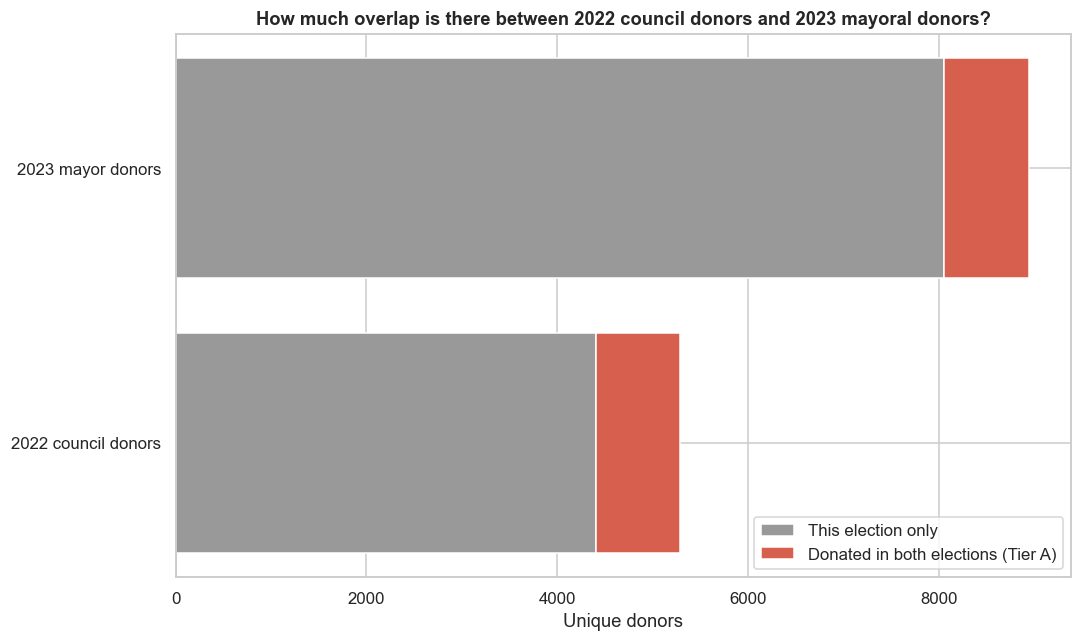

In [44]:
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
bars = [
    ("2022 council donors", len(council_donor_ids) - len(overlap_donor_ids_tier_a), len(overlap_donor_ids_tier_a)),
    ("2023 mayor donors", len(mayor_donor_ids) - len(overlap_donor_ids_tier_a), len(overlap_donor_ids_tier_a)),
]
labels = [b[0] for b in bars]
only_vals = [b[1] for b in bars]
both_vals = [b[2] for b in bars]
ax.barh(labels, only_vals, color=NEUTRAL_GRAY, label="This election only")
ax.barh(labels, both_vals, left=only_vals, color=REPEAT_HIGHLIGHT_COLOR, label="Donated in both elections (Tier A)")
ax.set_xlabel("Unique donors")
ax.set_title("How much overlap is there between 2022 council donors and 2023 mayoral donors?")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interpretation

This establishes whether a meaningful, persistent municipal donor population exists at all --
the precondition for everything else in Part 11. A small overlap doesn't kill Story B, but it
does mean most of Chow's (or anyone's) 2023 coalition is necessarily "not observed in 2022,"
which changes how the rest of this section should be framed.

### Takeaway

884 people gave to both a 2022 council candidate and the 2023 mayoral race under the
conservative Tier-A match -- **17% of all 2022 council donors and 10% of all 2023 mayoral
donors.** The corrected Tier-B sensitivity check matters for getting the diagnostic right, even
though it doesn't move the headline number much: of the 754 distinctive names that appear in
both elections' donor rolls, **655 already had a Tier-A match** (same name, same postal code)
and are not new information; only **99 names are genuinely additional** -- a real match Tier A
missed because the person's postal code differed between elections. Combined, Tier A + Tier B
raise the council-side overlap share from 17% to 19%. That the final percentage barely moves is
reassuring for trusting the Tier-A headline numbers used throughout the rest of this section --
but the earlier, uncorrected version of this diagnostic overstated how much *additional*
evidence Tier B actually contributed (754 vs. the true 99), which would have misrepresented how
much the sensitivity check actually added.

## 11.3 Decomposing Olivia Chow's 2023 donor coalition

### Method

Every unique Chow 2023 donor is split into **seen in the 2022 council data** (a conservative
Tier-A match to at least one 2022 council campaign) versus **not observed in the 2022 council
dataset**. We deliberately avoid the word "new" for the second group -- they may well have
donated in other elections, other years, or other contexts we simply don't have data for.

Olivia Chow, 2023: 3,214 unique donors
  Observed among 2022 council donors:      398 (12% of donors, 17% of dollars)
  Not observed in the 2022 council dataset: 2,816 (88% of donors, 83% of dollars)


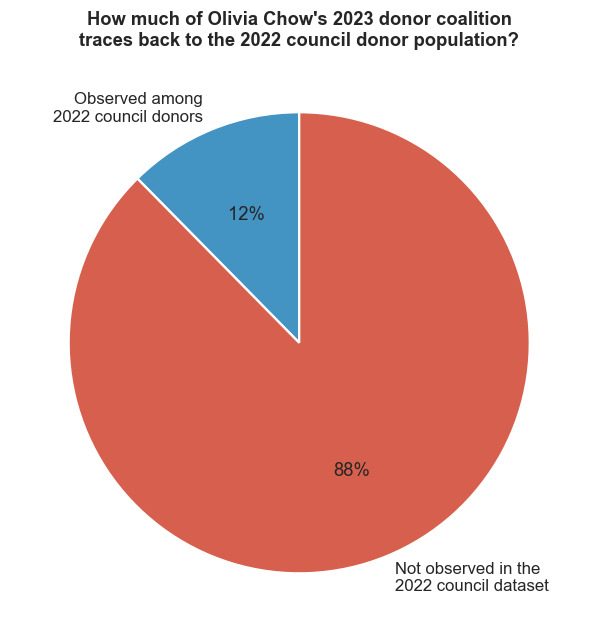

In [45]:
chow_donor_ids = set(mayor_2023.loc[(mayor_2023["candidate_raw"] == "Chow, Olivia") & (~mayor_2023["is_self_funded"]), "donor_id"])
chow_seen_ids = chow_donor_ids & council_donor_ids
chow_notseen_ids = chow_donor_ids - council_donor_ids

chow_rows = mayor_2023.loc[(mayor_2023["candidate_raw"] == "Chow, Olivia") & (~mayor_2023["is_self_funded"])]
chow_dollars_seen = chow_rows.loc[chow_rows["donor_id"].isin(chow_seen_ids), "amount"].sum()
chow_dollars_notseen = chow_rows.loc[chow_rows["donor_id"].isin(chow_notseen_ids), "amount"].sum()

print(f"Olivia Chow, 2023: {len(chow_donor_ids):,} unique donors")
print(f"  Observed among 2022 council donors:      {len(chow_seen_ids):,} ({len(chow_seen_ids)/len(chow_donor_ids):.0%} of donors, "
      f"{chow_dollars_seen/(chow_dollars_seen+chow_dollars_notseen):.0%} of dollars)")
print(f"  Not observed in the 2022 council dataset: {len(chow_notseen_ids):,} ({len(chow_notseen_ids)/len(chow_donor_ids):.0%} of donors, "
      f"{chow_dollars_notseen/(chow_dollars_seen+chow_dollars_notseen):.0%} of dollars)")

fig, ax = plt.subplots(figsize=(6, 6))
sizes = [len(chow_seen_ids), len(chow_notseen_ids)]
ax.pie(sizes, labels=["Observed among\n2022 council donors", "Not observed in the\n2022 council dataset"],
       colors=[SEEN_COLOR, NOT_SEEN_COLOR], autopct="%1.0f%%", startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("How much of Olivia Chow's 2023 donor coalition\ntraces back to the 2022 council donor population?")
plt.tight_layout()
plt.show()

### Interpretation

Even a modest "observed" share is meaningful: it means a real, traceable slice of Chow's
coalition consists of people who were already financially engaged in municipal politics the
year before. The "not observed" share is the more interesting unknown -- it could mean
genuinely new participants, past donors to candidates in *other* years/elections we don't have
data for, or simply people who didn't donate to a council candidate in 2022 specifically.

### Takeaway

Of Chow's 3,214 unique 2023 donors, **only 398 (12%) are observed among 2022 council donors,
carrying 17% of her dollars; the remaining 88% of donors (83% of dollars) are not observed in
the 2022 council dataset.** Even a conservative 12% traceable-continuity rate represents a real
and identifiable slice of her coalition -- but the great majority of Chow's 2023 support base
genuinely cannot be tied to 2022 council giving, whether because they are new to municipal
political giving entirely or simply didn't give to a council candidate that particular year.

## 11.4 Which 2022 council donor networks fed Olivia Chow's coalition?

### Method

For every 2022 council candidate with at least `MIN_DONORS_FOR_OVERLAP_MATRIX` donors, we
calculate three related but distinct measures:

- **Raw pipeline:** how many of that candidate's 2022 donors gave to Chow in 2023?
- **Conversion rate:** what *share* of that candidate's 2022 donor base gave to Chow? (a
  candidate with a smaller donor base can have a high conversion rate but a small raw pipeline)
- **Composition of Chow's "seen" coalition:** among Chow donors observed in 2022, what share
  had donated to each council candidate? (donors can count toward more than one candidate here,
  since a person may have given to several 2022 campaigns -- these shares can add to more than
  100%.)

In [46]:
eligible_council_2022 = council_profiles.loc[council_profiles["n_unique_donors"] >= MIN_DONORS_FOR_OVERLAP_MATRIX, "candidate_raw"].tolist()

pipeline_rows = []
for cand in eligible_council_2022:
    own_donors = set(council_2022.loc[(council_2022["candidate_raw"] == cand) & (~council_2022["is_self_funded"]), "donor_id"])
    pipeline = own_donors & chow_donor_ids
    pipeline_rows.append({
        "candidate_raw": cand,
        "n_2022_donors": len(own_donors),
        "n_gave_to_chow": len(pipeline),
        "conversion_rate": len(pipeline) / len(own_donors) if own_donors else np.nan,
    })
chow_pipeline = pd.DataFrame(pipeline_rows).sort_values("n_gave_to_chow", ascending=False)

# Composition: share of Chow's "seen" donors who gave to each council candidate.
composition = {}
for cand in eligible_council_2022:
    own_donors = set(council_2022.loc[(council_2022["candidate_raw"] == cand) & (~council_2022["is_self_funded"]), "donor_id"])
    composition[cand] = len(own_donors & chow_seen_ids) / len(chow_seen_ids) if chow_seen_ids else np.nan
chow_pipeline["share_of_chow_seen_coalition"] = chow_pipeline["candidate_raw"].map(composition)

print(f"{len(chow_pipeline)} council candidates have >= {MIN_DONORS_FOR_OVERLAP_MATRIX} 2022 donors; showing the top 20 by raw pipeline into Chow's coalition")
chow_pipeline.head(20).round(3)

45 council candidates have >= 30 2022 donors; showing the top 20 by raw pipeline into Chow's coalition


,candidate_raw,n_2022_donors,n_gave_to_chow,conversion_rate,share_of_chow_seen_coalition
6,"Malik, Ausma",261,83,0.32,0.21
12,"Bravo, Alejandra",231,80,0.35,0.20
29,"Perks, Gord",122,49,0.40,0.12
36,"Di Pasquale, Norm",112,45,0.40,0.11
3,"Fletcher, Paula",194,45,0.23,0.11
26,"Morley, Amber",212,44,0.21,0.11
11,"Padovani, Chiara",208,34,0.16,0.09
7,"Moise, Chris",142,32,0.23,0.08
19,"Rupasinghe, Kevin",196,27,0.14,0.07
14,"Saxe, Dianne",152,16,0.10,0.04


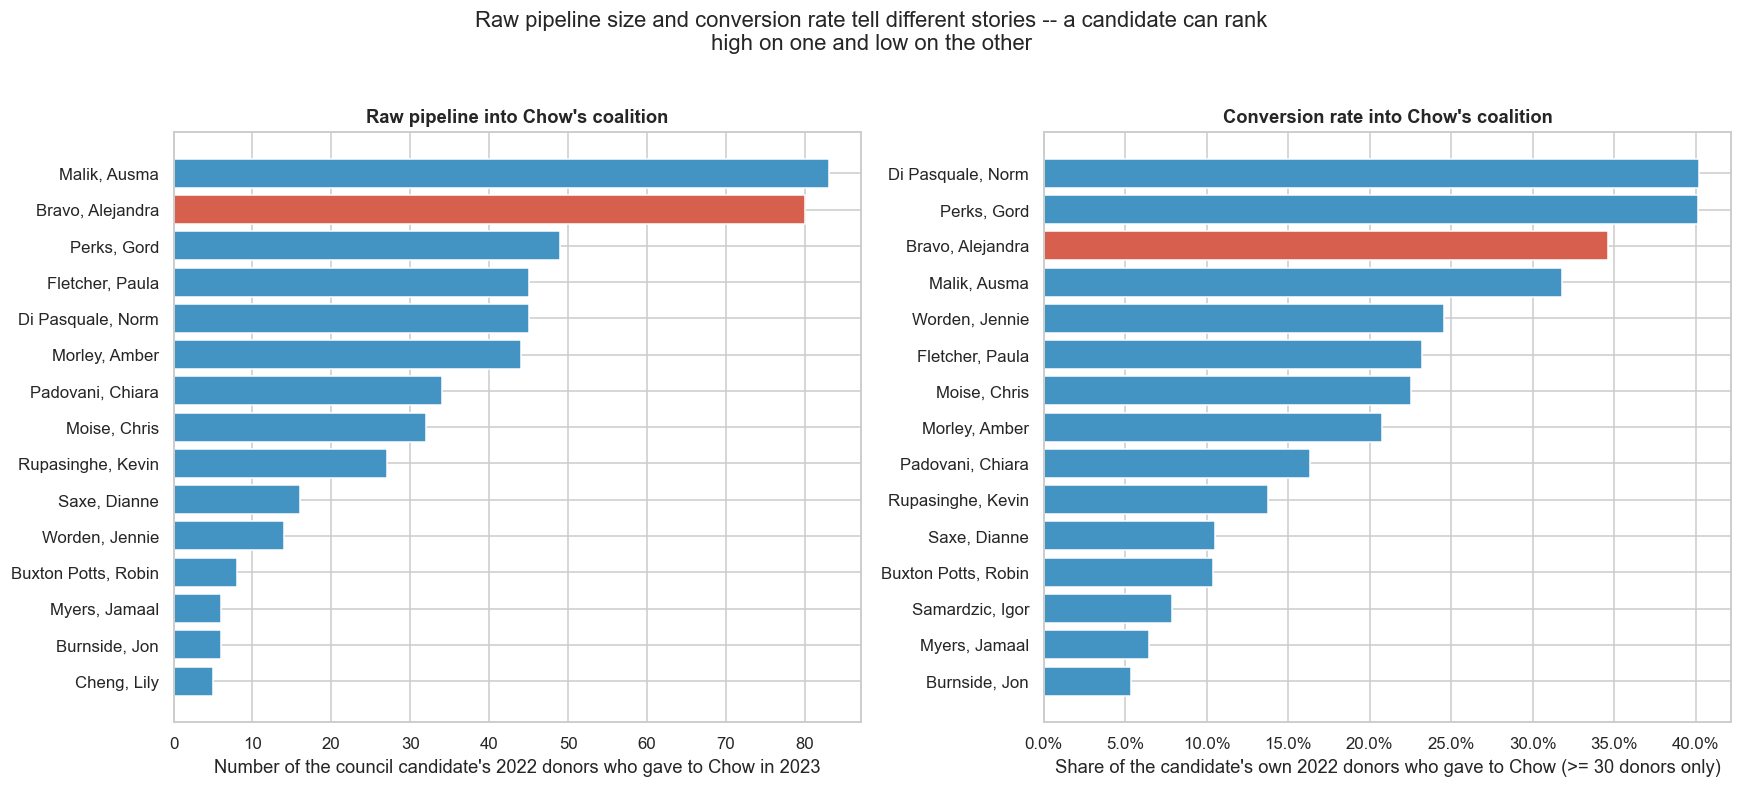

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_df = chow_pipeline.sort_values("n_gave_to_chow").tail(15)
colors = [REPEAT_HIGHLIGHT_COLOR if c in PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026 else OTHER_CANDIDATE_COLOR for c in plot_df["candidate_raw"]]
axes[0].barh(plot_df["candidate_raw"], plot_df["n_gave_to_chow"], color=colors)
axes[0].set_xlabel("Number of the council candidate's 2022 donors who gave to Chow in 2023")
axes[0].set_title("Raw pipeline into Chow's coalition")

plot_df2 = chow_pipeline.sort_values("conversion_rate").tail(15)
colors2 = [REPEAT_HIGHLIGHT_COLOR if c in PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026 else OTHER_CANDIDATE_COLOR for c in plot_df2["candidate_raw"]]
axes[1].barh(plot_df2["candidate_raw"], plot_df2["conversion_rate"], color=colors2)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xlabel(f"Share of the candidate's own 2022 donors who gave to Chow (>= {MIN_DONORS_FOR_OVERLAP_MATRIX} donors only)")
axes[1].set_title("Conversion rate into Chow's coalition")
fig.suptitle("Raw pipeline size and conversion rate tell different stories -- a candidate can rank\nhigh on one and low on the other", y=1.02)
plt.tight_layout()
plt.show()

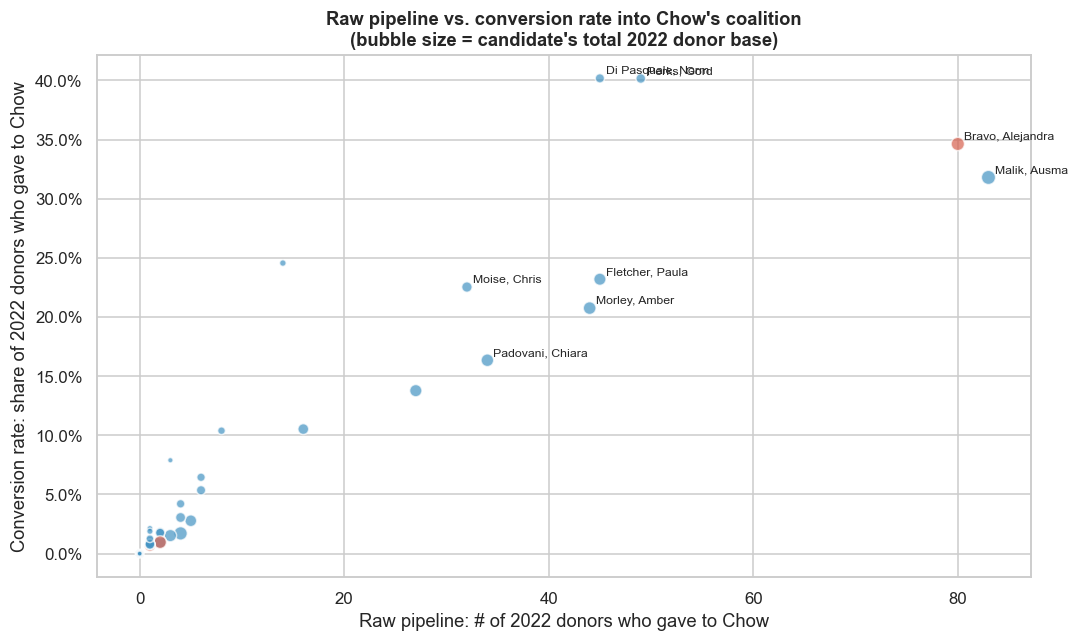

In [48]:
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
colors = [REPEAT_HIGHLIGHT_COLOR if c in PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026 else OTHER_CANDIDATE_COLOR for c in chow_pipeline["candidate_raw"]]
ax.scatter(chow_pipeline["n_gave_to_chow"], chow_pipeline["conversion_rate"], s=chow_pipeline["n_2022_donors"] / 3, color=colors, alpha=0.7, edgecolor="white")
for _, r in chow_pipeline.nlargest(8, "n_gave_to_chow").iterrows():
    ax.annotate(r["candidate_raw"], (r["n_gave_to_chow"], r["conversion_rate"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Raw pipeline: # of 2022 donors who gave to Chow")
ax.set_ylabel("Conversion rate: share of 2022 donors who gave to Chow")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Raw pipeline vs. conversion rate into Chow's coalition\n(bubble size = candidate's total 2022 donor base)")
plt.tight_layout()
plt.show()

### Interpretation

A high conversion rate from a small campaign is a genuinely different finding from a large raw
pipeline from a large campaign -- the latter partly just reflects that Chow had one of the
largest donor bases in the race (a candidate with a bigger coalition will naturally absorb more
of *everyone's* donors, more or less by chance). The composition share addresses this from
another angle: which 2022 council networks make up the largest recognizable share of Chow's
"seen" coalition specifically.

### Takeaway

**The highest conversion rates and the largest raw pipelines point to the same names, and they
are politically coherent.** Gord Perks and Norm Di Pasquale convert at 40%, Alejandra Bravo at
35%, Ausma Malik at 32% -- all comfortably the highest conversion rates among eligible 2022
council candidates, and Malik (83 donors) and Bravo (80 donors) also produce the largest raw
pipelines into Chow's coalition. Malik's and Bravo's donors alone make up 21% and 20%
respectively of Chow's entire "seen" coalition (Part 11.3's 398 traceable donors) -- these two
council networks are, by a clear margin, the largest identifiable building blocks of Chow's
observed-in-2022 support.

## 11.5 Comparing Chow with other 2023 mayoral candidates

### Method

A high Chow conversion rate from a council network isn't automatically distinctive -- Chow had
one of the largest donor bases in the race, so she'll naturally absorb more of *everyone's*
donors. We build a council-candidate x mayoral-candidate overlap matrix (raw %), then a second
**affinity** matrix that normalizes for that:

```
affinity(X, Y) = P(Y | X's 2022 donors) / P(Y | all 2022 council donors)
```

`1.0` = X's donors supported Y at the baseline rate any council donor did; `>1.0` = X's donors
were disproportionately likely to also back Y; `<1.0` = underrepresented. This is the measure
that can reveal a real donor-network affinity that the raw overlap matrix would hide.

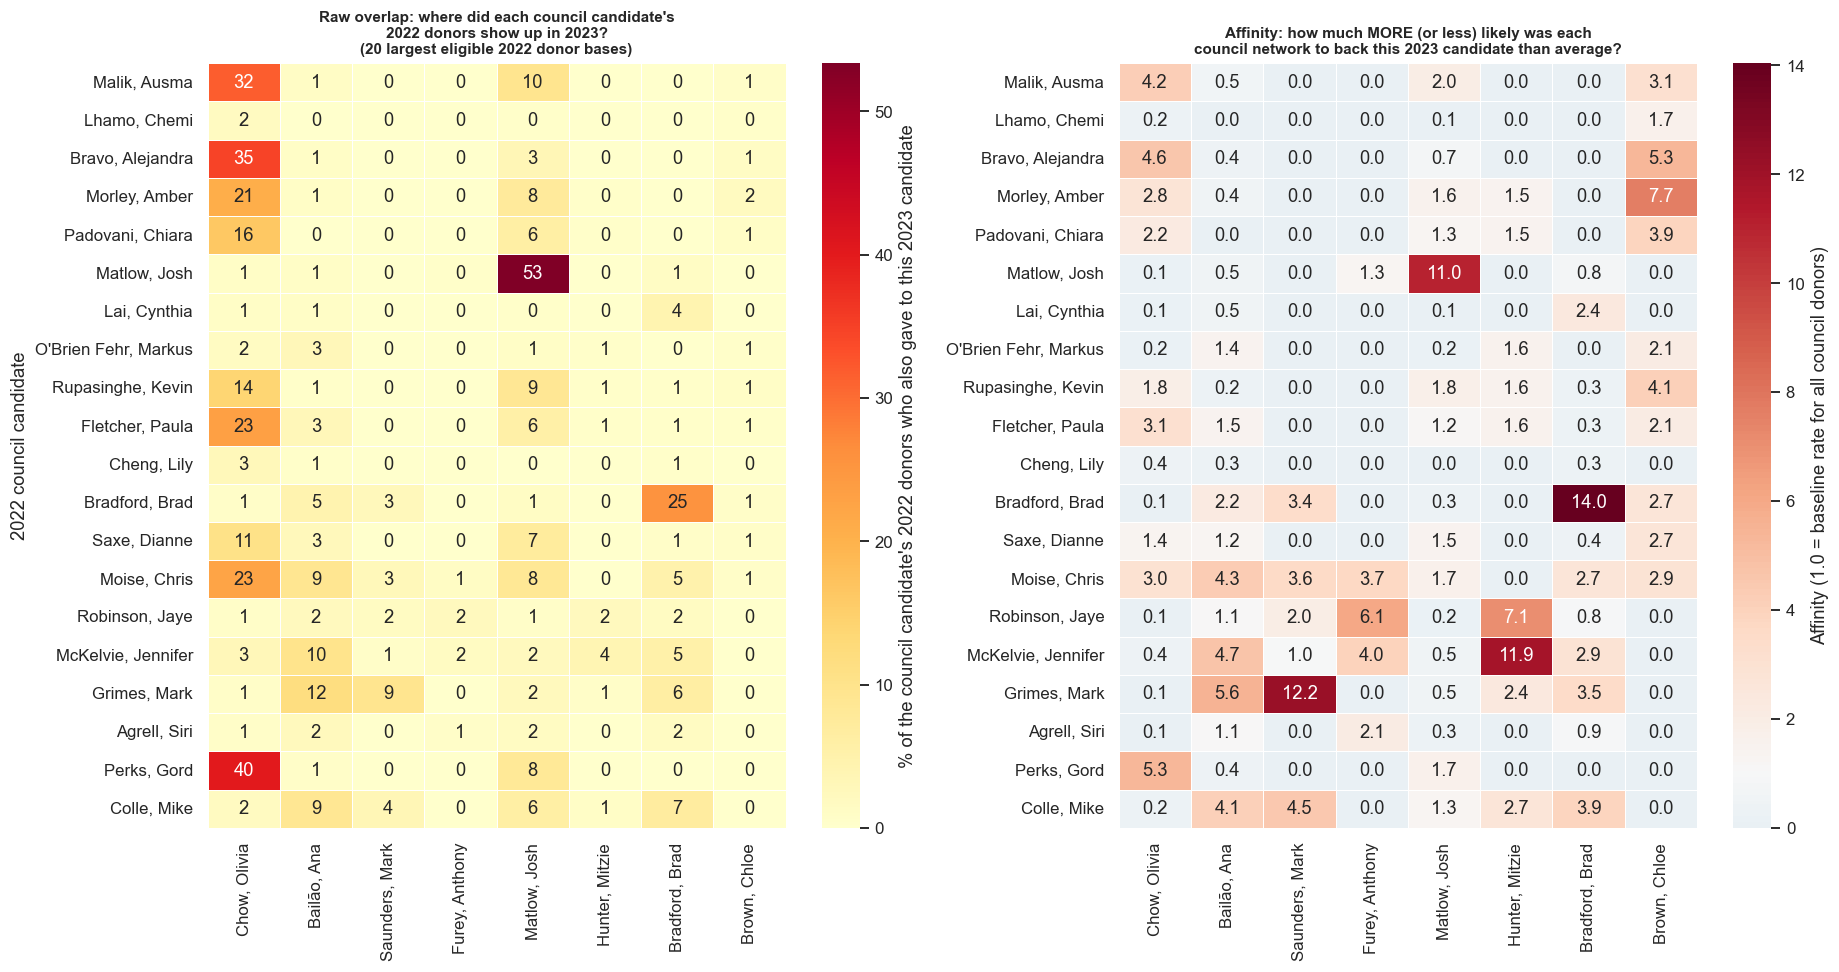

In [49]:
all_council_donor_ids = council_donor_ids  # already unique-donor deduplicated, all candidates pooled

# 45 council candidates clear the MIN_DONORS_FOR_OVERLAP_MATRIX threshold -- too many rows for a
# legible heatmap. Show the 20 with the largest 2022 donor bases (the ones a reader would
# recognize and where the underlying percentages are least noisy); the full pipeline/conversion
# analysis above already covers all of them.
heatmap_candidates = council_profiles.loc[
    council_profiles["candidate_raw"].isin(eligible_council_2022)
].nlargest(20, "n_unique_donors")["candidate_raw"].tolist()

overlap_matrix = pd.DataFrame(index=heatmap_candidates, columns=MAJOR_2023_CANDIDATES, dtype=float)
affinity_matrix = pd.DataFrame(index=heatmap_candidates, columns=MAJOR_2023_CANDIDATES, dtype=float)

baseline_rates = {}
for mc in MAJOR_2023_CANDIDATES:
    their_donors = set(mayor_2023.loc[(mayor_2023["candidate_raw"] == mc) & (~mayor_2023["is_self_funded"]), "donor_id"])
    baseline_rates[mc] = len(all_council_donor_ids & their_donors) / len(all_council_donor_ids)

for cc in heatmap_candidates:
    own = set(council_2022.loc[(council_2022["candidate_raw"] == cc) & (~council_2022["is_self_funded"]), "donor_id"])
    for mc in MAJOR_2023_CANDIDATES:
        their_donors = set(mayor_2023.loc[(mayor_2023["candidate_raw"] == mc) & (~mayor_2023["is_self_funded"]), "donor_id"])
        rate = len(own & their_donors) / len(own) if own else np.nan
        overlap_matrix.loc[cc, mc] = 100 * rate
        affinity_matrix.loc[cc, mc] = rate / baseline_rates[mc] if baseline_rates[mc] > 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(17, max(9, 0.45 * len(heatmap_candidates))))
sns.heatmap(overlap_matrix, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=axes[0],
            cbar_kws={"label": "% of the council candidate's 2022 donors who also gave to this 2023 candidate"})
axes[0].set_title("Raw overlap: where did each council candidate's\n2022 donors show up in 2023?\n(20 largest eligible 2022 donor bases)", fontsize=10)
axes[0].set_xlabel(""); axes[0].set_ylabel("2022 council candidate")

sns.heatmap(affinity_matrix, annot=True, fmt=".1f", cmap="RdBu_r", center=1.0, linewidths=0.5, ax=axes[1],
            cbar_kws={"label": "Affinity (1.0 = baseline rate for all council donors)"})
axes[1].set_title("Affinity: how much MORE (or less) likely was each\ncouncil network to back this 2023 candidate than average?", fontsize=10)
axes[1].set_xlabel(""); axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### Interpretation

The raw-overlap heatmap is dominated by candidates who simply had large donor bases (Chow and
Bailão will tend to show up everywhere at a decent rate). The affinity heatmap strips that out:
a cell well above 1.0 means that particular council candidate's donors were *disproportionately*
likely to also back that particular 2023 candidate -- a real network signal, not just a function
of who had the biggest coalition.

### Takeaway

**The affinity pattern is politically coherent, not noise.** Baseline: 7.5% of all 2022 council
donors gave to Chow in 2023. Against that baseline, Norm Di Pasquale's and Gord Perks's donors
were **5.3x** more likely to also back Chow; Bravo's and Malik's donors were **4.6x and 4.2x**
more likely. At the opposite end, several more centrist/right-leaning council candidates
(e.g. James Pasternak, Avtar Minhas, Allie Spencer) show essentially **zero** donor overlap
with Chow at all -- an affinity of 0.0. This is a clean, recognizable left-leaning
council-donor bloc funnelling disproportionately into Chow's coalition, not a diffuse pattern
that would suggest coincidence.

### Data-story potential -- Part 11 (overlap/affinity)

**Strong and novel.** The affinity heatmap in particular is the kind of finding that would be
hard to discover without exactly this donor-matched dataset -- it can reveal coherent
donor-network blocs that a simple headline overlap number obscures.

## 11.6 Special transition cases: Bradford and Matlow

Brad Bradford and Josh Matlow are uniquely useful test cases: both ran for **council** in 2022
and **mayor** in 2023, letting us look at retention, defection, and expansion of their own
donor network in one move.

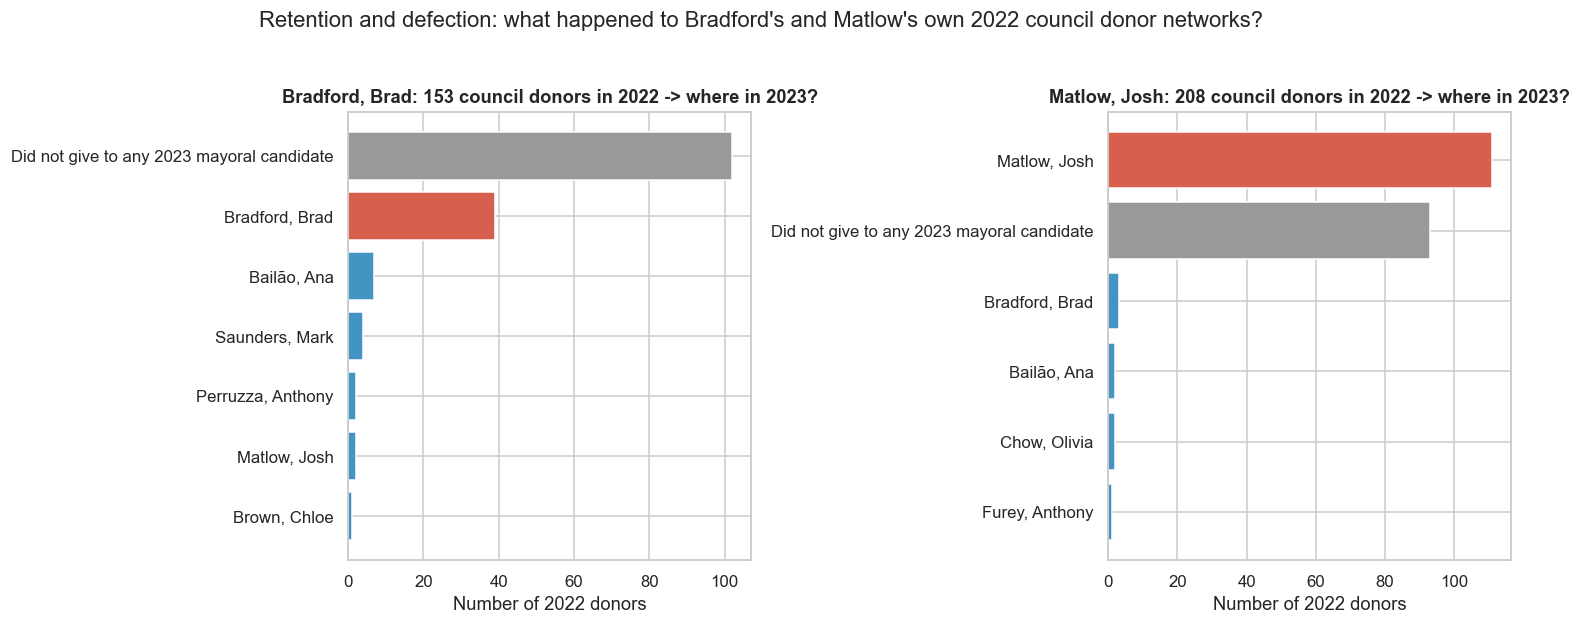

,candidate_raw,n_2022_council_donors,n_2023_mayor_donors,retention_rate,expansion_ratio
0,"Bradford, Brad",153,527,0.25,3.44
1,"Matlow, Josh",208,1750,0.53,8.41


In [50]:
def own_donor_destinations(council_candidate, n_top=6):
    own_donors = set(council_2022.loc[
        (council_2022["candidate_raw"] == council_candidate) & (~council_2022["is_self_funded"]), "donor_id"
    ])
    gave_in_2023 = mayor_2023.loc[mayor_2023["donor_id"].isin(own_donors) & (~mayor_2023["is_self_funded"])]
    destinations = gave_in_2023.groupby("candidate_raw")["donor_id"].nunique().sort_values(ascending=False)
    n_gave_2023 = gave_in_2023["donor_id"].nunique()
    result = destinations.head(n_top).copy()
    result["Did not give to any 2023 mayoral candidate"] = len(own_donors) - n_gave_2023
    return len(own_donors), result


transition_summary = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, cand in zip(axes, COUNCIL_TO_MAYOR_TRANSITION_CANDIDATES):
    n_donors_2022, dest = own_donor_destinations(cand)
    n_donors_2023 = mayor_profiles.set_index("candidate_raw").loc[cand, "n_unique_donors"] if cand in mayor_profiles["candidate_raw"].values else np.nan
    retained = dest.get(cand, 0)
    dest_sorted = dest.sort_values()
    colors = [NEUTRAL_GRAY if "Did not" in i else (REPEAT_HIGHLIGHT_COLOR if i == cand else OTHER_CANDIDATE_COLOR) for i in dest_sorted.index]
    ax.barh(dest_sorted.index, dest_sorted.values, color=colors)
    ax.set_title(f"{cand}: {n_donors_2022} council donors in 2022 -> where in 2023?")
    ax.set_xlabel("Number of 2022 donors")
    transition_summary.append({
        "candidate_raw": cand, "n_2022_council_donors": n_donors_2022, "n_2023_mayor_donors": n_donors_2023,
        "retention_rate": retained / n_donors_2022 if n_donors_2022 else np.nan,
        "expansion_ratio": n_donors_2023 / n_donors_2022 if n_donors_2022 else np.nan,
    })
fig.suptitle("Retention and defection: what happened to Bradford's and Matlow's own 2022 council donor networks?", y=1.03)
plt.tight_layout()
plt.show()
pd.DataFrame(transition_summary).round(2)

### Interpretation

**Retention** (own donors who gave again) validates the matching framework itself -- it should
be well above zero, since it's the same person supporting the same candidate a year later.
**Defection** (own donors who gave to a *different* 2023 candidate, especially Chow or Bailão)
is the more interesting signal: it shows where a council candidate's financial network went
once that candidate was no longer the only, or even the most viable, option. **Expansion**
(2023 donor count vs. 2022 donor count) shows how much each campaign had to grow beyond its
existing base to compete citywide.

### Takeaway

**Matlow retained far more of his own donor base than Bradford did.** Matlow kept 53% of his
208 2022 council donors (111 people) in his 2023 mayoral run, while Bradford retained only 25%
of his 153 (39 people). Of Bradford's non-retained donors, the small number who gave anywhere
in 2023 mostly went to Bailão (7) and Saunders (4) rather than to Chow; the large majority (102
of 153) simply didn't give to any 2023 mayoral candidate. Matlow's pattern is similar for
donors who moved on (3 to Bradford, 2 to Bailão, 2 to Chow, 1 to Furey; 93 gave to no one) --
but because he retained so many more of his own donors outright, his overall 2023 base (1,750
donors) expanded **8.4x** over his 2022 base, versus Bradford's more modest **3.4x** expansion
(to 527 donors).

## 11.7 Did Chow's coalition expand into demographically different territory?

### Question

Do Chow's "observed" and "not observed" 2023 donors come from demographically or
geographically different kinds of neighbourhoods -- i.e., did her mayoral campaign's donor
base genuinely broaden beyond the existing council-donor ecosystem, or just add more people
from the same kinds of places? We use the conservative Tier-A matching definition for "observed"
here, and compare the two groups in actual demographic values, not standardized scores.

**A caveat worth repeating: "not observed in 2022" is not the same as "new donor."** Someone in
this group may have donated to a council candidate in a year this dataset doesn't cover, or
given through a channel not captured here -- absence from the 2022 council data is not proof of
being new to municipal political giving.

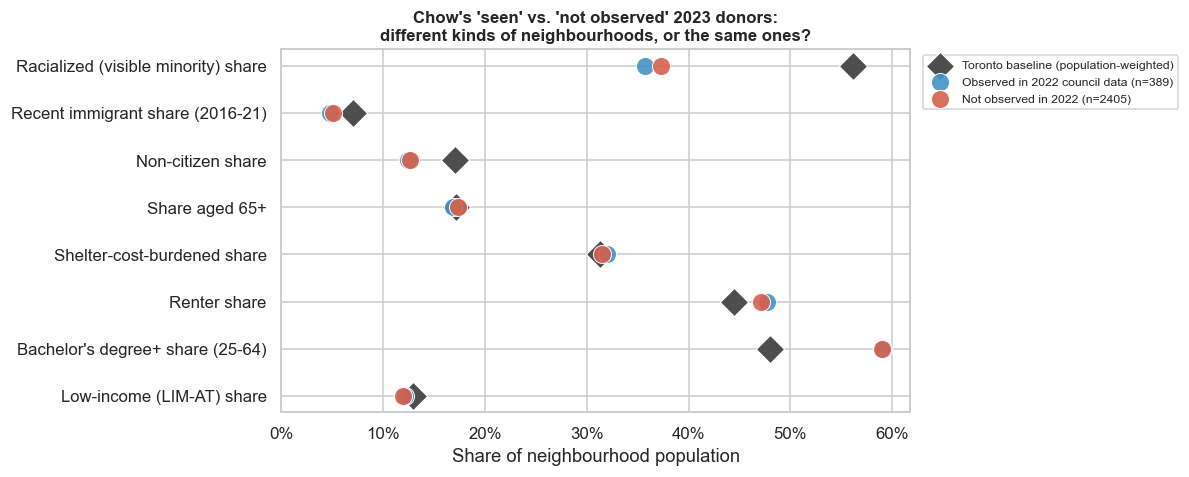

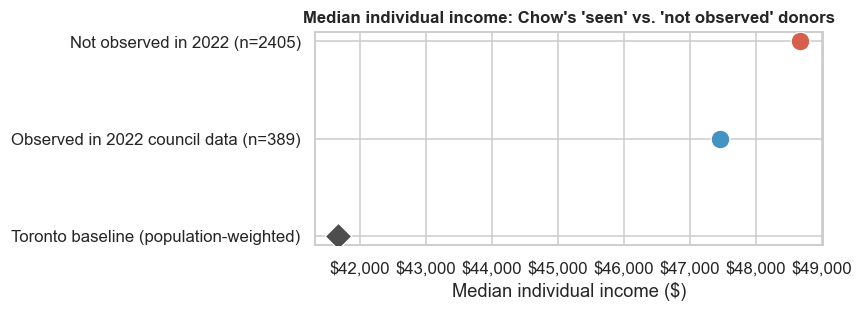

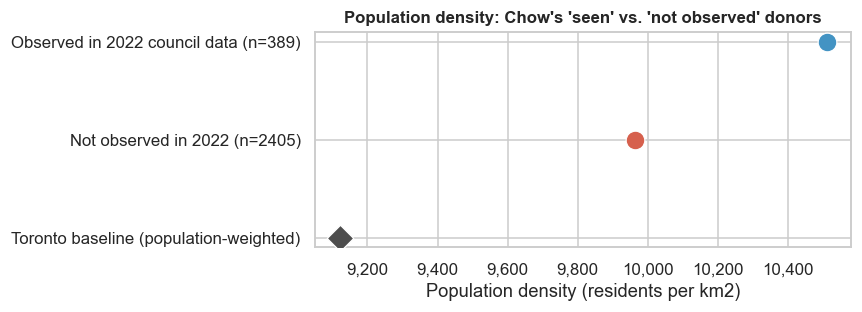

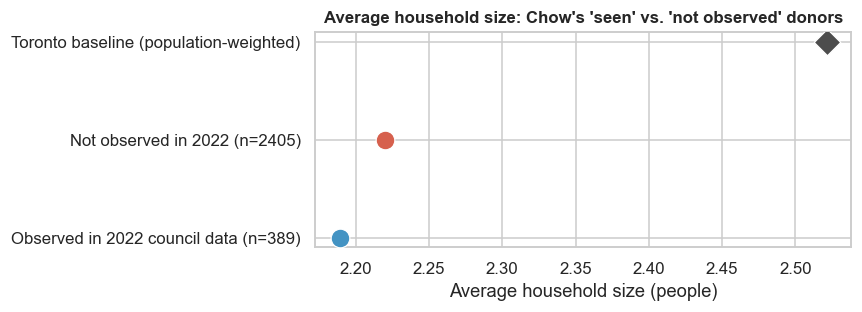

Percentage-point gaps (not-observed minus observed), proportion variables:
renter_share                      -0.60
shelter_cost_30plus_share         -0.60
low_income_lim_at_share           -0.20
bachelors_or_higher_25_64_share   -0.00
non_citizen_share                  0.20
recent_immigrant_share             0.30
age_65_plus_share                  0.40
visible_minority_share             1.60
dtype: float64

Median income gap (not-observed minus observed): $1,207
Population density gap (not-observed minus observed): -549 residents/km2
Average household size gap (not-observed minus observed): +0.03 people


In [51]:
def donor_group_profile(donor_ids, source_df, candidate_col, candidate_value):
    sub = source_df.loc[
        (source_df[candidate_col] == candidate_value) & source_df["donor_id"].isin(donor_ids)
        & source_df["is_toronto_postal"] & source_df["ctuid"].notna()
    ].drop_duplicates("donor_id")
    sub = sub.merge(ct_geo[["ctuid_norm"] + DEMOGRAPHIC_VARS], left_on="ctuid", right_on="ctuid_norm", how="left").dropna(subset=DEMOGRAPHIC_VARS)
    return sub[DEMOGRAPHIC_VARS].mean(), len(sub)


seen_profile, n_seen_geo = donor_group_profile(chow_seen_ids, mayor_2023, "candidate_raw", "Chow, Olivia")
notseen_profile, n_notseen_geo = donor_group_profile(chow_notseen_ids, mayor_2023, "candidate_raw", "Chow, Olivia")

chow_seen_notseen_entries = [
    baseline_entry,
    make_entry(f"Observed in 2022 council data (n={n_seen_geo})", seen_profile, SEEN_COLOR, marker="o", size=140),
    make_entry(f"Not observed in 2022 (n={n_notseen_geo})", notseen_profile, NOT_SEEN_COLOR, marker="o", size=140),
]
plot_proportion_profile(chow_seen_notseen_entries, "Chow's 'seen' vs. 'not observed' 2023 donors:\ndifferent kinds of neighbourhoods, or the same ones?")
plot_scalar_comparison(chow_seen_notseen_entries, "median_individual_income",
                        "Median individual income: Chow's 'seen' vs. 'not observed' donors", "Median individual income ($)", fmt="dollar")
plot_scalar_comparison(chow_seen_notseen_entries, "population_density_per_km2",
                        "Population density: Chow's 'seen' vs. 'not observed' donors", "Population density (residents per km2)", fmt="num")
plot_scalar_comparison(chow_seen_notseen_entries, "average_household_size",
                        "Average household size: Chow's 'seen' vs. 'not observed' donors", "Average household size (people)", fmt="decimal")

pct_diff = (100 * (notseen_profile[DEMOGRAPHIC_PROPORTION_VARS] - seen_profile[DEMOGRAPHIC_PROPORTION_VARS])).sort_values()
income_diff = notseen_profile["median_individual_income"] - seen_profile["median_individual_income"]
density_diff = notseen_profile["population_density_per_km2"] - seen_profile["population_density_per_km2"]
household_diff = notseen_profile["average_household_size"] - seen_profile["average_household_size"]
print(f"Percentage-point gaps (not-observed minus observed), proportion variables:\n{pct_diff.round(1)}")
print(f"\nMedian income gap (not-observed minus observed): ${income_diff:,.0f}")
print(f"Population density gap (not-observed minus observed): {density_diff:,.0f} residents/km2")
print(f"Average household size gap (not-observed minus observed): {household_diff:+.2f} people")

### Interpretation

If the blue and red points sit close together on most rows, Chow's coalition grew mostly by
adding *more people from the same kinds of places* she already had a foothold in. If they
diverge substantially on income, education, or racialized share, that's evidence her mayoral
run genuinely broadened the demographic footprint of her donor base beyond the existing
council-donor ecosystem -- a materially stronger version of the 2026 story.

### Takeaway

**In actual values, the two groups still look remarkably similar, not different.** Chow's
donors not observed in the 2022 council data live in neighbourhoods with, on average, $1,207
*higher* median income, 549 fewer residents per km2, and a nearly identical household size
(+0.03 people) compared with her observed-in-2022 donors -- all small differences relative to
the underlying variation across Toronto. Among proportion variables, the largest gap is
visible-minority share at +1.6 percentage points; every other gap is under 1 point in either
direction. Chow's 2023 coalition did not noticeably diversify demographically as it grew beyond
the 2022 council-donor ecosystem -- the 88% of her donor base not observed in 2022 looks,
neighbourhood-wise, almost identical to the 12% that is traceable. This tempers Story B
somewhat: whatever demographic skew exists in Chow's overall donor base (see Part 8's
income/education findings) applies about equally to both her returning and her new supporters,
rather than describing an old, narrower group being diluted by a demographically different new
one.

## Part 11 takeaway and data-story potential

**Takeaway:** A real but modest 17-19% of donor continuity connects the 2022 council donor
population to Chow's 2023 coalition (conservative Tier-A match, corrected Tier-B sensitivity
check), and that traceable slice is not randomly distributed -- it is disproportionately drawn
from a recognizable, left-leaning bloc of 2022 council donor networks (Bravo, Malik, Perks, Di
Pasquale most of all, at 4-5x the baseline affinity), while several centrist/right-leaning
council candidates' donors show essentially zero overlap with Chow. Matlow retained donors at
more than double Bradford's rate in their respective mayoral bids (53% vs. 25%), and -- now
checked in actual demographic values rather than standardized scores -- Chow's "new" donors
still look almost identical to her "traceable" ones on every measure: her coalition grew by
adding more people from similar neighbourhoods, not by visibly diversifying into new ones.

### Data-story potential -- Part 11

**Strong, and the most novel material in this notebook.** Tracing named donor coalitions across
two real elections a year apart is a genuinely unusual dataset opportunity; the affinity heatmap
and the Bradford/Matlow transition case studies are unlikely to have been reported publicly
before. The main caveats to carry into any public version: (1) Tier A matching is deliberately
conservative and likely *understates* true continuity; (2) "not observed in 2022" is not the
same as "new to politics"; (3) small 2022 donor bases produce noisy conversion rates, hence the
`MIN_DONORS_FOR_OVERLAP_MATRIX` threshold.

# What Is the Strongest Data Story?

## Story A -- Who finances Toronto municipal politics?

**Evidence assembled:** donor-base scale and concentration (Part 1), raw vs. per-capita
geography (Part 3), ward-level geography and cross-candidate mayoral geography (Part 4),
cross-election geographic persistence (Part 5), how locally rooted council fundraising is
(Part 6), and the demographic correlates of financial participation across *every* Toronto
census tract, checked for stability across both elections (Parts 7-9), plus donor-neighbourhood
comparisons across major mayoral and 2026 repeat council candidates (Part 10).

- **Strength of evidence: strong, and larger than a donor-matched-only analysis would show.**
  Including every Toronto census tract (zero-donor tracts included, not excluded) raised the
  income and education donor-participation gaps to 7.6x and 9.0x between quintiles (Part 8),
  and both relationships replicate independently in the 2022 and 2023 elections (rho 0.57-0.66,
  Part 9). Ward 12 (Toronto-St. Paul's) and Ward 11 (University-Rosedale) consistently top
  every ward-level ranking (Part 4), ward-level giving is strongly persistent across elections
  (rho = 0.85-0.88, Part 5), and the mayoral geography comparison shows candidates genuinely
  differ in how much they lean on those highest-giving wards (23%-58% of donors, Part 4). Every
  major mayoral candidate's donor base is more affluent, more educated, and less racialized
  than the Toronto baseline, with no exceptions (Part 10).
- **Visual clarity:** high -- choropleth maps, ward rankings, quintile bar charts, and the
  combined candidate-profile dot plots are all immediately legible to a general reader without
  requiring a table.
- **Novelty:** moderate -- geographic/demographic inequality in political giving is a
  plausible, expected pattern; its value is in **quantifying and visualizing** it concretely
  for Toronto specifically, in the Part 4 mayoral geography comparison, and in the Part 6
  local-rootedness comparison across named 2026 candidates.
- **Caveats:** demographic findings are ecological, describing neighbourhoods, not donors
  personally; the multivariate model in Part 8 is a diagnostic showing how overlapping these
  neighbourhood characteristics are, not evidence that one causes or mediates another.

## Story B -- Where did Olivia Chow's donor coalition come from?

**Evidence assembled:** the size and observed-continuity of Chow's coalition (Part 11.2-11.3,
now with a corrected Tier-A/Tier-B sensitivity calculation), which 2022 council donor networks
fed it and how strongly (Part 11.4-11.5), how Chow compares with her major 2023 rivals
(affinity heatmap), the Bradford/Matlow transition case studies (Part 11.6), and whether her
coalition broadened into different neighbourhoods, in actual demographic values, beyond the
existing council-donor ecosystem (Part 11.7).

- **Strength of evidence: strong.** 17-19% donor continuity is real and traceable even under
  conservative, corrected matching, and the affinity heatmap shows a politically coherent
  pattern, not noise: donors to progressive 2022 council candidates (Bravo, Malik, Perks, Di
  Pasquale) were 4-5x more likely than a typical council donor to also back Chow, while
  several centrist/right-leaning candidates' donors showed essentially none. The Bradford/
  Matlow natural experiment both validates the matching approach (meaningful, sensible
  retention rates) and adds real texture (Matlow retained donors at more than double
  Bradford's rate). Checked in actual demographic values, the one point that still tempers the
  story holds up: Chow's "new" and "traceable" donors look almost identical on every measure
  (Part 11.7) -- her coalition grew in scale far more than in composition.
- **Visual clarity:** high -- the seen/not-seen decomposition, ranked pipeline/conversion
  charts, the affinity heatmap, and the raw-value demographic comparison are all direct,
  intuitive visuals.
- **Novelty:** high -- this is a genuinely unusual dataset opportunity (two real elections a
  year apart, named donors, full postal codes) that is unlikely to have been reported before.
- **2026 relevance:** direct and explicit -- Chow is running for mayor again in 2026, and this
  section describes exactly the donor coalition she is defending or trying to expand.
- **Limitations:** conservative Tier-A matching likely understates true donor continuity; "not
  observed in 2022" is not equivalent to "new to politics"; small council donor bases produce
  noisy conversion-rate estimates (mitigated with the `MIN_DONORS_FOR_OVERLAP_MATRIX` threshold).

## Recommended primary story

**The strongest single story still combines both, and each side got more precise this pass
rather than changing direction.** Story A's evidence is now measurably stronger with every
Toronto census tract properly included (bigger quintile gaps, a corrected diagnostic on the
income/education overlap, a new mayoral-geography comparison showing candidates genuinely
draw from different wards). Story B is unchanged in its core finding but more carefully
verified (a corrected Tier-B calculation, a raw-value demographic comparison that confirms
rather than merely suggests Chow's coalition didn't diversify demographically as it grew). The
strongest public-facing framing remains a **combination**: Toronto's political money is
measurably concentrated in a handful of wealthier, more educated wards (Story A) -- and even
Olivia Chow, whose 2023 coalition is often described as the city's broadest, draws a donor
base that is more affluent and more educated than the Toronto baseline like every other major
candidate's, while a recognizable slice of it traces to a specific, identifiable bloc of 2022
progressive council donor networks (Story B). Neither headline is as strong without the other.

## Recommended secondary angle

**Two candidates for the strongest secondary angle, both directly 2026-relevant:** the Part 6
local-rootedness comparison across the four priority 2026 council repeat candidates
(Bradford 37%, Bravo 60%, Matlow 84%, Holyday 33% own-ward donor share -- Matlow's number in
particular is striking), and the Part 10 finding that Cheng and Padovani are the only 2026
repeat council candidates whose donor bases don't skew affluent/educated relative to Toronto,
with Cheng the single candidate across the entire notebook whose donor base is *more*
racialized than the city as a whole. Either works well alongside the primary combined story;
the local-rootedness comparison has the simpler, more intuitive metric, while the demographic
comparison surfaces a genuinely unexpected exception to an otherwise uniform pattern.

## Findings not worth pursuing further

- **Renter share vs. donor participation (Part 8):** flat-to-slightly-inverted (0.8x between
  quintiles) and only marginally significant in the full multivariate model -- not worth a
  dedicated graphic in a public write-up.
- **Raw own-ward *dollar* share as the primary local-rootedness metric (Part 6):** noisier
  than donor share, since it's easily dominated by one or two large gifts; keep donor share as
  the headline number and mention dollar share only as a secondary check.
- **Holyday's local-rootedness and demographic-profile numbers specifically:** his own ward
  had only 6 donors and he falls below the minimum-donor threshold for a demographic profile
  entirely -- not a reliable enough sample to feature as a finding on its own.
- **The multivariate model's individual coefficients as headline numbers (Part 8):** useful as
  a diagnostic showing how overlapping these neighbourhood characteristics are, but a single
  IRR reported without that context invites a causal misreading the underlying data can't
  support.
- **The census-tract-level cross-election persistence check (Part 5) as a standalone number:**
  useful as a secondary confirmation of the ward-level result, but the ward-level correlation
  is the cleaner, more citable number for a public write-up.